# Note to Marker
- The python kernel used for this project is Python 3.12.12

- The entire notebook should run fully automatically (download and extract from the UC Irvine site)

- Citations and references appear in the cells of reference as they are mentioned. A final list appears at the very end of the notebook.

- There are ADDITIONAL WORK sections (Pipeline diagram, 8B,8C,8D) where I have tried to improve on the basic goal of obtaining a Linear Regression result.


# 1 - Domain-Specific Area and Objectives of the Project

The domain-specific area for this project is predictive maintenance for automated and robotic sorting systems used in circular economy and electronic waste recovery. Electronic waste is a growing global problem: the Global E-waste Monitor 2024 reported that 62 million tonnes of e-waste were generated in 2022, while documented formal collection and recycling remains much lower. This creates a need for more efficient recovery systems that can sort and process valuable materials at scale. 

My specific interest is the precious metals recovery from electronic waste, where initial sorting is a major operational challenge. Scrap circuit boards contain mixed components, materials and values, so they must be separated before metal recovery can occur. Robotic sorting is one possible approach, using computer vision, robotic arms and automated handling systems to identify, pick and separate materials. Recent research into robotic waste sorting and automated disassembly shows the relevance of robotics to recycling and end-of-life electronics processing. 

The dataset selected for this project is the **UC Irvine dataset: [Condition Monitoring of Hydraulic Systems](https://archive.ics.uci.edu/dataset/447/condition+monitoring+of+hydraulic+systems)** dataset[1]. It is not directly an e-waste dataset, but it is closely related to robotic automation because automated sorting systems depend on reliable motion, actuation, cooling and mechanical control. The dataset contains sensor data from a hydraulic test rig, including pressure, flow, temperature, vibration and motor power measurements. UCI lists the dataset as suitable for regression, with 2,205 instances and real-valued sensor features. 

The objective of this project is to use linear regression to predict hydraulic system efficiency, represented by `SE_mean`, from sensor-derived features. Linear regression is suitable because the target variable is continuous and the predictor variables are numerical sensor measurements. The project will use visualisation, correlation analysis and trendlines to check whether approximately linear relationships exist before modelling.

The contribution of this project is to show how sensor data can be transformed into cycle-level features and used to estimate machine efficiency. In an automated e-waste sorting context, this type of model could support predictive maintenance by identifying patterns associated with reduced efficiency before failure occurs. Predictive maintenance is valuable in industrial systems because machine learning can use sensor data to improve reliability and reduce unplanned downtime. 

The project goal is therefore:

**To predict hydraulic system efficiency from sensor data in order to support reliable robotic sorting for e-waste precious metal recovery.**

[1]: Helwig,N., et al. (2018) UC Irvine. Last accessed June 21, 2026. ["Condition Monitoring of Hydraulic Systems"](https://archive.ics.uci.edu/dataset/447/condition+monitoring+of+hydraulic+systems)

# 2 - Dataset Description

The selected dataset is the UCI Machine Learning Repository dataset **Condition Monitoring of Hydraulic Systems**, created by Helwig, Pignanelli and Schütze and donated in 2018 [2]. The dataset was experimentally collected from a hydraulic test rig operating repeated 60-second load cycles. During each cycle, sensor readings were recorded while the condition of key hydraulic components, including the cooler, valve, pump and accumulator, was varied. [1] 

The dataset contains **2,205 instances**, where each instance represents one complete 60-second operating cycle. It contains **43,680 raw features**, because each sensor file stores multiple time-sampled readings per cycle. The data is provided as multiple tab-delimited text files rather than one simple table. Each file represents a sensor or virtual measurement, with rows representing cycles and columns representing sampled readings within each cycle.

The dataset includes 14 physical sensors: six pressure sensors (`PS1` to `PS6`) measured in bars at a rate of 100 Hz, one motor power sensor (`EPS1`) measured in watts at a rate 100 Hz, two volume flow sensors (`FS1`, `FS2`) measured in litres per minute at a rate of 10 Hz, four temperature sensors (`TS1` to `TS4`) measured in degrees Celsius at a rate of 1 Hz, and one vibration sensor (`VS1`) measured in mm/s at a rate of 1 Hz. It also includes three virtual efficiency variables: cooling efficiency (`CE`), cooling power (`CP`) and system efficiency factor (`SE`). The `profile.txt` file provides cycle-level condition labels for cooler condition, valve condition, internal pump leakage, hydraulic accumulator pressure and stability flag.

The dataset is licensed under Creative Commons Attribution 4.0, meaning it can be shared and adapted with appropriate credit [3]. UCI lists the dataset as suitable for both classification and regression, with real-valued features and no missing values. 

This dataset fits the project because it provides numerical sensor data and continuous performance-related variables. For this project, the target variable is `SE_mean`, the average system efficiency factor per cycle. Linear regression is appropriate because the aim is to test whether pressure, flow, temperature, vibration and motor power features have an approximately linear relationship with hydraulic efficiency. The multi-file structure also supports the preprocessing stage, as the raw sensor files must be loaded, summarised into cycle-level features, merged, normalised and prepared for modelling.

[1]: Helwig,N., et al. (2018) UC Irvine. Last accessed June 21, 2026. "Condition Monitoring of Hydraulic Systems". https://archive.ics.uci.edu/dataset/447/condition+monitoring+of+hydraulic+

[2]: UC Irvine. Machine Learning Repository.  Last accessed June 21, 2026. https://archive.ics.uci.edu/

[3]: Creative Commons. CC By 4.0 Attribution 4.0 International Legal Code. Last accessed June 21, 2026. https://creativecommons.org/licenses/by/4.0/legalcode

In [159]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from pathlib import Path
import requests
import zipfile

In [160]:
# Display settings
# These are my own personal preferences
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [161]:
# Set the various path constants used throughout the notebook. 
# These are used to ensure that the code is portable and can be run on any machine without needing to change the paths.
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "extracted"
ZIP_DIR = PROJECT_DIR / "data" / "original"
DATAFRAME_DIR = PROJECT_DIR / "data" / "dataframes"
ORIGINAL_PATH = ZIP_DIR / "condition_monitoring_of_hydraulic-systems.zip"
EXTRACTION_PATH = DATA_DIR / "condition_monitoring_of_hydraulic-systems"
VISUALIZATION_DIR = PROJECT_DIR / "data" / "visualizations"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

In [162]:
# Create project directories if they do not already exist
directories = [
    DATA_DIR,
    ZIP_DIR,
    DATAFRAME_DIR,
    EXTRACTION_PATH,
    VISUALIZATION_DIR,
    PROCESSED_DIR
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

# ADDITIONAL WORK - Pipeline diagram
Running the code in the cell below will produce a figure that shows the workflow for this project. 

The figure shows the overall data pipeline used in the project. The process began with the raw UCI Hydraulic Systems dataset, followed by sensor summarisation, merging with condition data, cleaning, normalisation, visualisation, model building, validation, feature engineering and final evaluation.

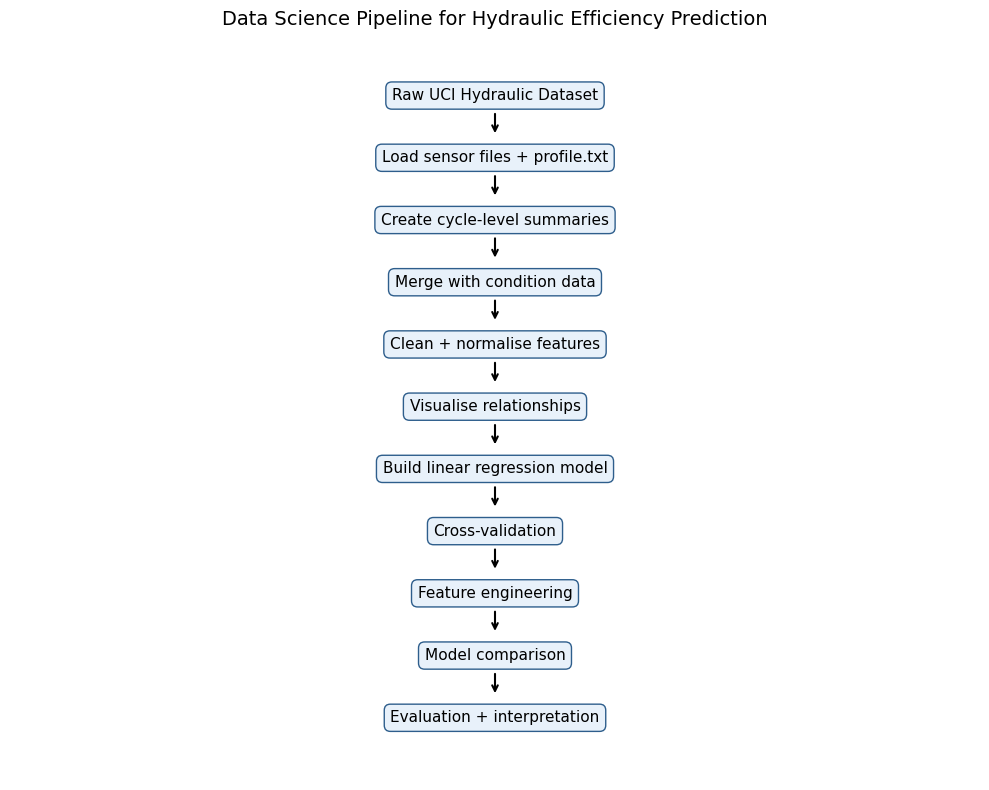

In [163]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGURE_DIR = Path("outputs/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

steps = [
    "Raw UCI Hydraulic Dataset",
    "Load sensor files + profile.txt",
    "Create cycle-level summaries",
    "Merge with condition data",
    "Clean + normalise features",
    "Visualise relationships",
    "Build linear regression model",
    "Cross-validation",
    "Feature engineering",
    "Model comparison",
    "Evaluation + interpretation"
]

fig, ax = plt.subplots(figsize=(10, 8))
ax.axis("off")

y_positions = list(range(len(steps), 0, -1))

for i, (step, y) in enumerate(zip(steps, y_positions)):
    ax.text(
        0.5,
        y,
        step,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#E8F1FA", edgecolor="#2E5E8C")
    )
    
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(0.5, y - 0.65),
            xytext=(0.5, y - 0.25),
            arrowprops=dict(arrowstyle="->", linewidth=1.5)
        )

ax.set_xlim(0, 1)
ax.set_ylim(0, len(steps) + 1)

plt.title("Data Science Pipeline for Hydraulic Efficiency Prediction", fontsize=14)
plt.tight_layout()

plt.savefig(VISUALIZATION_DIR / "data_pipeline_diagram.png", bbox_inches="tight")
plt.show()

# 3. Data Preparation

The UC Irvine Hydraulic Systems dataset is provided as a collection of tab-delimited text files rather than as a single modelling table. The raw dataset contains separate sensor files, a `profile.txt` file containing cycle-level condition labels, and metadata files describing the dataset structure and variables.

The purpose of this section is to transform the raw multi-file dataset into a structured dataframe suitable for statistical analysis, visualisation and machine learning. Each sensor file will be loaded, inspected and summarised at the cycle level. Summary statistics such as the mean, minimum, maximum and standard deviation will be calculated for each sensor cycle so that the high-frequency time-series readings can be represented as machine-learning features.

The `profile.txt` data will also be examined and merged with the sensor-derived features where appropriate. This provides additional context about hydraulic component condition and system stability, which can be used for interpretation and later model evaluation.

The final output of this section will be a processed sensor dataframe containing one row per hydraulic operating cycle and a set of numerical features suitable for linear regression. Basic visual checks will also be included during preparation to confirm that the data has been loaded, combined and normalised correctly.

The dataset is distributed as a ZIP archive. After extraction, the folder contains multiple tab-delimited text files. The data is not supplied as a single tidy CSV file, so loading and combining the files is part of the preprocessing task.

In [164]:
def download_zip_file(
        url, 
        destination_path
    ):
    '''
        Downloads a file (zip) from the provided URL and saves it to the specified destination path. 
    
        If the file already exists, it will not be downloaded again.

        Args:
            url (str): The URL of the file to download.
            destination_path (str or Path): The path where the downloaded file will be saved.

        Raises:
            requests.exceptions.RequestException: If there is an issue with the network request.
        
    '''

    destination_path = Path(destination_path)

    response = requests.get(url, stream=True)
    response.raise_for_status()

    with open(destination_path, "wb") as file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                file.write(chunk)

    print(f"Downloaded zip file to: {destination_path}")

In [165]:
def extract_zip_file(
        zip_path, 
        extraction_path
    ):
    '''
        Extracts a zip file to the specified destination path. 
    
        This will overwrite any existing files in the destination path.

        Args:
            zip_path (str or Path): The path to the zip file to extract.
            extraction_path (str or Path): The path where the extracted files will be saved.

        Raises:
            zipfile.BadZipFile: If the specified file is not a valid zip file.
        
    '''
    
    zip_path = Path(zip_path)
    extraction_path = Path(extraction_path)

    extraction_path.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extraction_path)

    print(f"Extracted zip file to: {extraction_path}")

In [166]:
dataset_url = "https://archive.ics.uci.edu/static/public/447/condition+monitoring+of+hydraulic+systems.zip"

# only download the original dataset if it does not already exist
if not ORIGINAL_PATH.exists():
    download_zip_file(
        url=dataset_url,
        destination_path=ORIGINAL_PATH
    )
else:
    print(f"Zip file already exists at: {ORIGINAL_PATH}")

extract_zip_file(
    zip_path=ORIGINAL_PATH,
    extraction_path= EXTRACTION_PATH
)

Zip file already exists at: c:\Users\brett\Documents\Working\University Of London\Year 3\CM3005_Data_Science\Mid Term\data\original\condition_monitoring_of_hydraulic-systems.zip
Extracted zip file to: c:\Users\brett\Documents\Working\University Of London\Year 3\CM3005_Data_Science\Mid Term\data\extracted\condition_monitoring_of_hydraulic-systems


In [167]:
# Using rglob, obtain a recursively sorted list of all file paths in the extraction directory. This will include all files and subdirectories.
all_data_files = sorted(EXTRACTION_PATH.rglob("*"))


The next cell creates a dictionary of the data files located in the extraction directory.  Only real files (not directories) are included.

In [168]:
data_file_inventory = [] # initialise an empty python list to store files

for file in all_data_files:
    if file.is_file():  # is this a real file (not a directory)? If so, add it to the inventory list
        data_file_inventory.append({
            "file_name": file.name,
            "relative_path": str(file.relative_to(EXTRACTION_PATH)),
            "extension": file.suffix,
            "size": file.stat().st_size / (1024 * 1024) # convert file size to mb
        })

The following cell takes each *.txt file that has been extracted and assigns it to a data_file dictionary and to a load_summary.
The resulting load_summary is a visual aid that can be scanned to see which files are data or not.

As each file is loaded, we determine if there are any missing values and also determines how many numeric columns are in the file
using the ```np.number``` function which determines if a value is an integer or float.

In [ ]:
txt_files = sorted(EXTRACTION_PATH.glob("*.txt"))

data_files = {} # only data files, not the profile, description or documentation text files.
load_summary = [] # summary table of all files

for file in txt_files:
    name = file.stem # filename, no extension
    try:
        # load the file into a pandas dataframe, using tab as the separator and no header row
        df = pd.read_csv(file, sep="\t", header=None)
        data_files[name] = df

        load_summary.append({
            "file": file.name,
            "key": name,
            "rows" : df.shape[0],
            "columns": df.shape[1],
            "total_cells": df.shape[0] * df.shape[1],
            "missing_values": int(df.isna().sum().sum()),
            "numeric_columns": int(df.select_dtypes(include=[np.number]).shape[1])
        })

    # If a file is not a data file (e.g., profile.txt, description.txt, or documentation.txt), it will raise an exception when trying to load it as a dataframe. In that case, we catch the exception and log the error in the load_summary.
    except Exception as e:
       load_summary.append({
            "file": file.name,
            "key": name,
            "rows" : None,
            "columns": None,
            "total_cells": None,
            "missing_values": None,
            "numeric_columns": None,
            "error": str(e)
        }) 
       
load_summary_df = pd.DataFrame(load_summary)
load_summary_df

,file,key,rows,columns,total_cells,missing_values,numeric_columns,error
0,CE.txt,CE,2205.0,60.0,132300.0,0.0,60.0,NaN
1,CP.txt,CP,2205.0,60.0,132300.0,0.0,60.0,NaN
2,description.txt,description,NaN,NaN,NaN,NaN,NaN,'utf-8' codec can't decode byte 0xfc in positi...
3,documentation.txt,documentation,NaN,NaN,NaN,NaN,NaN,'utf-8' codec can't decode byte 0xfc in positi...
4,EPS1.txt,EPS1,2205.0,6000.0,13230000.0,0.0,6000.0,NaN
5,FS1.txt,FS1,2205.0,600.0,1323000.0,0.0,600.0,NaN
6,FS2.txt,FS2,2205.0,600.0,1323000.0,0.0,600.0,NaN
7,profile.txt,profile,2205.0,5.0,11025.0,0.0,5.0,NaN
8,PS1.txt,PS1,2205.0,6000.0,13230000.0,0.0,6000.0,NaN
9,PS2.txt,PS2,2205.0,6000.0,13230000.0,0.0,6000.0,NaN


In [27]:
# Save the dataframe
load_summary_df.to_csv(DATAFRAME_DIR / "load_summary.csv", index = False)

The profile file is treated differently from the raw sensor files because it contains one row per operating cycle rather than in-cycle sampled sensor readings. 

These columns describe the known condition of hydraulic components and can be used for grouping, filtering or later classification tasks. They can also help interpret whether efficiency changes are associated with degraded component states.

From the UCI website the following are defined:

**Cooler Condition - in percentages**

- 3: close to total failure
- 20: reduced efficiency
- 100: full efficiency

**Valve Condition - in percentages**

- 100: optimal
- 90: small lag
- 80: severe lag
- 73: close to total failure

**Internal Pump Leakage**

- 0: no leakage
- 1: weak leakage
- 2: severe leakage

**Hydraulic accumulator - measured in bar**

- 130: optimal
- 115: slightly reduced pressure
- 100: severely reduced pressure

**Stable Flag**

- 0: conditions were stable
- 1: static conditions might not have been reached yet


In [28]:
# process the profile file.
profile = data_files["profile"].copy()

profile.columns=[
    "cooler_condition",
    "valve_condition",
    "pump_leakage",
    "hydraulic_accumulator",
    "stable_flag"
]

profile.head()

,cooler_condition,valve_condition,pump_leakage,hydraulic_accumulator,stable_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


In [29]:
# use describe to get see some file statistics
profile.describe()

,cooler_condition,valve_condition,pump_leakage,hydraulic_accumulator,stable_flag
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,41.240816,90.693878,0.669388,107.199546,0.342857
std,42.383143,10.681802,0.817233,16.435848,0.474772
min,3.000000,73.000000,0.000000,90.000000,0.000000
25%,3.000000,80.000000,0.000000,90.000000,0.000000
50%,20.000000,100.000000,0.000000,100.000000,0.000000
75%,100.000000,100.000000,1.000000,130.000000,1.000000
max,100.000000,100.000000,2.000000,130.000000,1.000000


The above cell is not really that useful.  Even though the values are generally percentages, they tend to fall into more categorical categories as defined previously (3: close to total failure).  Value counts may be a better approach.

In [171]:
for col in profile.columns:
    print("\n", col)
    print(profile[col].value_counts().sort_index())


 cooler_condition
cooler_condition
3      732
20     732
100    741
Name: count, dtype: int64

 valve_condition
valve_condition
73      360
80      360
90      360
100    1125
Name: count, dtype: int64

 pump_leakage
pump_leakage
0    1221
1     492
2     492
Name: count, dtype: int64

 hydraulic_accumulator
hydraulic_accumulator
90     808
100    399
115    399
130    599
Name: count, dtype: int64

 stable_flag
stable_flag
0    1449
1     756
Name: count, dtype: int64


The value_count data seems to raise some questions that I do not have the answers for.

The repeating values, 732 in the cooler condition, and 360 in the valve condition suggest that these numbers are not random.  They seem to be more deliberate unless they are demonstrating in an abstract way, how a single sensor fails --- progressively rather than just going from working to not working.  This may be a plausible hyothesis as nothing in the dataset documentation indicates that the data is not all real data.

This hypothesis also explains how this phenonema is seen across all the sensors (except the stable flag).  

# HERE.  Everything above is checked and complete

The row alignment check (cell below) verifies that each file contains the same number of operating cycles. 

Important because later preprocessing will combine cycle-level summaries from each sensor file into one modelling table.

In [31]:
# check that every file has the same number of rows (per sensor) as found in profile.txt.
# This ensures a one to one mapping between sensor cycles and machine assessment found in profile.txt
row_check = []
expected_rows = profile.shape[0]

for name, df in data_files.items():
    row_check.append({
        "file_key": name,
        "rows": df.shape[0],
        "matches_profile_rows" : df.shape[0] == expected_rows
    })

row_check_df = pd.DataFrame(row_check)
row_check_df

,file_key,rows,matches_profile_rows
0,CE,2205,True
1,CP,2205,True
2,EPS1,2205,True
3,FS1,2205,True
4,FS2,2205,True
5,profile,2205,True
6,PS1,2205,True
7,PS2,2205,True
8,PS3,2205,True
9,PS4,2205,True


In [32]:
# save the row_check_df
row_check_df.to_csv(DATAFRAME_DIR / "row_check", index=False)

## Section 3 - Data Preparation - Programmatic data checks

Data Quality

The quality summary checks whether each file is numeric, whether missing values are present, and whether the range of values appears reasonable. Although UCI identifies the dataset as having no missing values, this check is still necessary because imported files may contain parsing issues, blank columns or formatting problems.

In [33]:
data_quality_summary = []

for name, df in data_files.items():
    # Ensure all number fields are either numeric or NaN
    numeric_df = df.apply(pd.to_numeric, errors="coerce")

    # convert to a numpy array (improved performance) and flatten to a list using ravel
    values = numeric_df.to_numpy().ravel()
    # remove NaNs and keep the array clean and numeric only
    values = values[~np.isnan(values)]

    data_quality_summary.append({
        "file_key" : name, 
        "rows" : df.shape[0],
        "columns" : df.shape[1],
        "missing_values": int(numeric_df.isna().sum().sum()),
        "min": np.min(values) if len(values) > 0 else np.nan,
        "max": np.max(values) if len(values) > 0 else np.nan,
        "mean": np.mean(values) if len(values) > 0 else np.nan,
        "std": np.std(values) if len(values) > 0 else np.nan,
    })

data_quality_summary_df = pd.DataFrame(data_quality_summary)
data_quality_summary_df

,file_key,rows,columns,missing_values,min,max,mean,std
0,CE,2205,60,0,17.042,48.777,31.299077,11.577906
1,CP,2205,60,0,1.016,2.909,1.808399,0.279326
2,EPS1,2205,6000,0,2097.800,2995.200,2495.509203,218.222229
3,FS1,2205,600,0,0.000,20.479,6.198549,3.213826
4,FS2,2205,600,0,8.764,10.453,9.649453,0.449489
5,profile,2205,5,0,0.000,130.000,48.029297,49.122090
6,PS1,2205,6000,0,133.130,191.920,160.485315,16.133330
7,PS2,2205,6000,0,0.000,167.770,109.379906,48.103172
8,PS3,2205,6000,0,0.000,18.828,1.753227,0.934707
9,PS4,2205,6000,0,0.000,10.266,2.600266,4.297607


The above dataframe is a good result.  As per the UC Irvine documentation there are no missing values which indicates that this is a very good quality dataset.


In [34]:
# save the dataframe
data_quality_summary_df.to_csv(DATAFRAME_DIR / "data_quality_summary.csv", index = False)

In [35]:
# Create a per cycle statistical summary of the features for every sensor file
# There are thousands of features so reducing the number by caculating the 
# statistical '5' makes sense prior to performing Linear Regression.
# Calculate mean, standard deviation, median, min, max for each column in each file

def summarise_sensor_file(df, prefix):
    # Make sure that all data is numeric and if not 'coerce' to a NaN
    numeric_df = df.apply(pd.to_numeric, errors="coerce")
    
    # calcuate summary statistics; axis = 1 is column wise across rows
    summary = pd.DataFrame({
        f"{prefix}_mean": numeric_df.mean(axis=1),
        f"{prefix}_std": numeric_df.std(axis=1),
        f"{prefix}_min": numeric_df.min(axis=1),
        f"{prefix}_max": numeric_df.max(axis=1),
        f"{prefix}_median": numeric_df.median(axis=1)
    })
    
    return summary

In [36]:
# for each file in the data_files dictionary calcuated the statistical '5' for each row of data
feature_tables = []

for name, df in data_files.items():
    if name != "profile":
        feature_tables.append(summarise_sensor_file(df, name))

features = pd.concat(feature_tables, axis=1)
features.head()

,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median
0,39.601350,6.370535,28.866,47.438,40.6755,1.862750,0.279385,1.383,2.188,1.9240,2538.929167,185.616121,2339.8,2951.6,2479.8,6.709815,3.015428,0.0,18.710,7.836,10.304592,0.091772,10.148,10.446,10.327,160.673492,13.939309,145.83,191.51,156.25,109.466914,47.114508,0.0,156.99,129.365,1.991475,0.945705,0.0,10.039,2.297,0.0,0.0,0.0,0.0,0.0,9.842170,0.088154,9.681,10.016,9.844,9.728097,0.085366,9.568,9.887,9.733,59.157183,23.763984,0.0,79.568,68.5145,35.621983,0.308230,35.156,36.152,35.5720,40.978767,0.154302,40.773,41.250,40.9630,38.471017,0.084659,38.316,38.613,38.4960,31.745250,1.116478,30.363,33.594,31.576,0.576950,0.027078,0.532,0.624,0.5770
1,25.786433,1.686129,23.320,29.208,25.3855,1.255550,0.074605,1.147,1.414,1.2340,2531.498900,189.940089,2332.0,2947.4,2470.0,6.715315,3.006248,0.0,18.712,7.853,10.403098,0.019162,10.352,10.453,10.403,160.603320,14.118967,145.73,191.47,156.06,109.354890,47.045611,0.0,157.56,129.385,1.976234,0.941967,0.0,9.992,2.273,0.0,0.0,0.0,0.0,0.0,9.635142,0.038392,9.557,9.745,9.632,9.529488,0.036316,9.454,9.637,9.526,59.335617,23.857918,0.0,80.441,68.5360,36.676967,0.585740,35.648,37.488,36.7675,41.532767,0.338234,41.031,42.105,41.5180,38.978967,0.176921,38.668,39.254,38.9845,34.493867,0.435312,33.648,35.148,34.553,0.565850,0.027241,0.524,0.626,0.5595
2,22.218233,0.638345,21.220,23.554,22.1040,1.113217,0.023263,1.076,1.159,1.1095,2519.928000,190.736850,2318.6,2939.8,2457.4,6.718522,3.014248,0.0,18.698,7.847,10.366250,0.026361,10.296,10.443,10.367,160.347720,14.192619,145.37,191.41,155.72,109.158845,46.992060,0.0,156.97,129.325,1.972224,0.943501,0.0,10.914,2.273,0.0,0.0,0.0,0.0,0.0,9.530548,0.035817,9.455,9.640,9.528,9.427949,0.036031,9.348,9.536,9.425,59.543150,23.923381,0.0,80.824,68.8530,37.880800,0.559169,36.879,38.621,38.0235,42.442450,0.390588,41.832,43.039,42.4235,39.631950,0.251133,39.234,40.062,39.6270,35.646150,0.293889,35.098,36.141,35.635,0.576533,0.036729,0.529,0.662,0.5620
3,20.459817,0.455755,19.673,21.565,20.4805,1.062150,0.024621,1.022,1.107,1.0660,2511.541633,191.270607,2310.8,2929.6,2448.0,6.720565,3.020176,0.0,18.896,7.843,10.302678,0.026750,10.241,10.382,10.302,160.188088,14.227803,145.14,191.34,155.56,109.064807,46.972221,0.0,156.44,128.865,1.946575,0.935534,0.0,10.297,2.242,0.0,0.0,0.0,0.0,0.0,9.438827,0.037069,9.363,9.535,9.436,9.337430,0.037375,9.257,9.431,9.335,59.794900,24.023005,0.0,80.930,69.0060,38.879050,0.516176,37.887,39.473,39.0550,43.403983,0.398476,42.805,43.988,43.3650,40.403383,0.285434,40.023,40.934,40.3420,36.579467,0.262397,36.105,36.988,36.635,0.569267,0.033464,0.527,0.645,0.5550
4,19.787017,0.290156,19.133,20.460,19.7985,1.070467,0.021477,1.016,1.106,1.0725,2503.449500,191.258369,2301.8,2923.8,2440.6,6.690308,3.011550,0.0,18.876,7.831,10.237750,0.029170,10.179,10.312,10.236,160.000472,14.276434,144.95,191.41,155.34,108.931434,46.874946,0.0,158.13,129.000,1.922707,0.930335,0.0,11.102,2.219,0.0,0.0,0.0,0.0,0.0,9.358762,0.029779,9.290,9.443,9.358,9.260636,0.028592,9.195,9.342,9.260,59.455267,23.972262,0.0,81.100,69.0130,39.803917,0.535374,38.789,40.391,39.9670,44.332750,0.372769,43.742,44.887,44.3355,41.310550,0.293579,40.859,41.777,41.3400,37.427900,0.239571,36.992,37.781,37.439,0.577367,0.033484,0.524,0.660,0.5760


There seems to be an issue with the PS4 calculations as there are no results. Below I check the tail, and a random selection of rows, and see that there are results for these columns so everything checks out.

In [37]:
features.shape

(2205, 85)

In [38]:
# Specifically looking at PS4 columns. Looking for non-zero data
features.tail()

,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median
2200,46.628517,0.237772,46.242,47.092,46.6335,2.160600,0.018171,2.127,2.196,2.1615,2543.911033,187.530212,2346.0,2953.2,2481.6,6.689930,3.001512,0.0,20.228,7.8395,10.184515,0.013701,10.147,10.224,10.185,161.227572,13.987129,146.69,191.81,156.59,109.779581,47.253414,0.0,167.49,130.300,2.001438,0.931535,0.0,9.445,2.320,10.202473,0.023118,10.130,10.264,10.202,9.972037,0.022277,9.910,10.028,9.970,9.850361,0.021802,9.790,9.905,9.849,59.03310,23.635352,0.0,77.752,68.4505,35.313783,0.141893,35.000,35.516,35.4100,40.874800,0.071999,40.727,40.977,40.879,38.269267,0.066279,38.168,38.371,38.262,30.404733,0.032142,30.363,30.488,30.395,0.550833,0.029820,0.512,0.618,0.5485
2201,46.689817,0.392929,45.762,47.486,46.6510,2.151450,0.023372,2.094,2.200,2.1485,2543.411333,187.062031,2345.8,2950.8,2481.6,6.692182,3.005831,0.0,20.308,7.8340,10.177767,0.014669,10.133,10.233,10.178,161.206070,14.001418,146.64,191.81,156.55,109.787481,47.247815,0.0,167.27,130.275,1.998781,0.930958,0.0,9.398,2.320,10.197919,0.023339,10.127,10.255,10.198,9.966184,0.022023,9.901,10.014,9.965,9.844854,0.021932,9.777,9.894,9.844,59.06800,23.638396,0.0,77.592,68.4075,35.321600,0.137743,34.988,35.516,35.3765,40.868883,0.071279,40.707,40.977,40.871,38.268250,0.072038,38.148,38.418,38.262,30.416233,0.037951,30.367,30.488,30.395,0.547483,0.021463,0.507,0.584,0.5425
2202,46.472300,0.462510,45.683,47.206,46.7005,2.143300,0.027183,2.099,2.188,2.1425,2542.729767,186.846232,2345.8,2949.4,2480.6,6.693277,2.991333,0.0,20.071,7.8330,10.176172,0.014749,10.127,10.225,10.177,161.192120,13.988350,146.63,191.84,156.56,109.756174,47.244805,0.0,167.34,130.250,1.993436,0.929445,0.0,9.492,2.305,10.196824,0.023725,10.116,10.255,10.196,9.964329,0.022527,9.898,10.019,9.964,9.842628,0.022094,9.777,9.896,9.842,59.13235,23.633405,0.0,77.773,68.3130,35.319183,0.152040,34.984,35.520,35.4060,40.875950,0.073286,40.719,40.977,40.879,38.246367,0.080508,38.156,38.371,38.242,30.426250,0.045413,30.367,30.496,30.406,0.545233,0.024047,0.502,0.597,0.5440
2203,46.544967,0.242202,45.846,47.001,46.5490,2.148483,0.017777,2.107,2.188,2.1480,2544.046333,186.799816,2346.0,2951.6,2481.8,6.684128,3.003983,0.0,20.280,7.8235,10.178353,0.014619,10.129,10.230,10.180,161.208917,13.985248,146.65,191.77,156.58,109.793884,47.240806,0.0,167.52,130.300,2.007077,0.933360,0.0,9.469,2.328,10.198588,0.024640,10.116,10.257,10.198,9.968232,0.023517,9.898,10.022,9.967,9.846690,0.023185,9.767,9.900,9.846,58.97080,23.600817,0.0,77.568,68.3500,35.324767,0.158769,35.000,35.531,35.4120,40.876067,0.063998,40.742,40.977,40.893,38.245733,0.075174,38.145,38.363,38.246,30.414283,0.038725,30.363,30.488,30.402,0.537017,0.017652,0.502,0.585,0.5350
2204,46.647933,0.250113,46.144,47.109,46.6035,2.157050,0.021039,2.126,2.194,2.1495,2543.818300,186.529535,2344.0,2951.4,2483.4,6.692302,3.007413,0.0,20.395,7.8370,10.183393,0.015373,10.120,10.233,10.184,161.217128,13.984674,146.57,191.69,156.60,109.792177,47.238665,0.0,167.34,130.340,2.002690,0.932842,0.0,9.344,2.320,10.203126,0.024331,10.121,10.262,10.204,9.973638,0.023194,9.903,10.024,9.972,9.851949,0.022552,9.785,9.900,9.851,59.05390,23.627226,0.0,77.748,68.3705,35.322233,0.149859,35.008,35.531,35.3945,40.859400,0.065621,40.715,40.973,40.840,38.248917,0.074163,38.148,38.391,38.19

In [39]:
# Specifically looking at PS4 columns. Looking for non-zero data
features.sample(n=10, random_state=12)

,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median
1770,47.478367,0.240925,47.058,47.910,47.4350,2.166750,0.020220,2.137,2.205,2.1585,2535.333267,187.563238,2333.8,2942.0,2471.8,6.696547,3.081109,0.0,19.838,7.8265,10.165998,0.014540,10.120,10.214,10.1670,161.178820,14.036045,146.40,191.66,156.420,109.295862,47.549242,0.0,167.41,129.995,2.000362,0.958002,0.0,9.711,2.3200,10.075224,0.023693,10.002,10.134,10.075,9.843133,0.021606,9.785,9.891,9.842,9.727801,0.021800,9.663,9.774,9.7270,58.975067,23.777712,0.0,79.944,68.6735,36.177117,0.146840,35.840,36.344,36.2360,41.777483,0.099490,41.570,41.910,41.7835,39.059283,0.077659,38.965,39.207,39.0270,31.151000,0.012917,31.121,31.172,31.156,0.556517,0.021316,0.512,0.605,0.5520
2157,46.552283,0.240802,46.146,47.069,46.5085,2.156350,0.020447,2.126,2.208,2.1575,2540.132800,188.993691,2337.8,2947.4,2475.6,6.650810,3.053481,0.0,20.479,7.8205,10.165867,0.015680,10.108,10.209,10.1670,161.388168,14.148946,146.51,191.71,156.490,109.113553,47.811254,0.0,167.41,130.180,1.983542,0.940929,0.0,9.547,2.3125,10.157635,0.024069,10.078,10.225,10.157,9.929860,0.021962,9.865,9.979,9.929,9.811053,0.022487,9.746,9.861,9.8110,58.160800,24.259112,0.0,77.865,68.6780,35.574733,0.157877,35.234,35.758,35.6560,41.210350,0.102018,41.039,41.332,41.2340,38.503200,0.071986,38.426,38.687,38.5040,30.639433,0.011942,30.605,30.668,30.641,0.550367,0.020504,0.511,0.592,0.5485
1939,47.247783,0.349453,46.684,47.833,47.2665,2.160200,0.023027,2.120,2.204,2.1570,2537.572900,187.056957,2339.8,2947.4,2475.8,6.700850,3.000863,0.0,20.014,7.8250,10.147363,0.014867,10.097,10.194,10.1480,160.928550,14.039139,146.39,191.59,156.260,109.541939,47.150625,0.0,167.23,130.060,1.992401,0.934851,0.0,9.695,2.3050,10.063539,0.023907,9.984,10.127,10.062,9.832569,0.021793,9.764,9.884,9.832,9.718450,0.021835,9.654,9.767,9.7180,59.225383,23.693258,0.0,78.532,68.3650,36.318583,0.165935,36.000,36.512,36.3240,41.981450,0.077914,41.883,42.098,41.9820,39.214317,0.063289,39.160,39.355,39.1800,31.318267,0.038213,31.273,31.398,31.305,0.544033,0.022250,0.507,0.595,0.5380
1777,47.541983,0.230882,47.182,47.911,47.4955,2.173867,0.020512,2.140,2.212,2.1690,2542.304900,189.303948,2339.8,2955.8,2479.4,6.707283,3.066085,0.0,19.662,7.8275,10.169550,0.015018,10.111,10.219,10.1700,161.057978,14.009320,146.35,191.68,156.360,109.493626,47.307011,0.0,167.31,129.895,2.017172,0.963133,0.0,9.937,2.3280,10.076509,0.023931,9.997,10.136,10.077,9.845817,0.021413,9.785,9.892,9.845,9.730061,0.021666,9.664,9.780,9.7290,59.123800,23.729485,0.0,79.443,68.4460,36.228400,0.142387,35.926,36.426,36.2460,41.832900,0.069868,41.656,41.910,41.8790,39.083167,0.073812,38.965,39.195,39.0860,31.151867,0.017874,31.066,31.184,31.156,0.544367,0.019307,0.509,0.595,0.5415
1760,47.542767,0.390184,46.961,48.298,47.4950,2.166767,0.025983,2.126,2.225,2.1645,2537.930100,188.559540,2336.0,2947.6,2473.6,6.661267,3.065367,0.0,20.467,7.8290,10.164648,0.015031,10.120,10.203,10.1650,161.266635,14.103332,146.42,191.71,156.410,109.039319,47.803434,0.0,167.33,129.985,1.999694,0.962753,0.0,9.695,2.3200,10.082252,0.023707,10.002,10.141,10.083,9.851321,0.021934,9.790,9.903,9.850,9.735169,0.021857,9.670,9.788,9.7340,58.176167,24.249861,0.0,79.958,68.6740,36.091167,0.153523,35.754,36.262,36.1385,41.654633,0.084986,41.520,41.801,41.6465,38.940050,0

The processed dataset combines all cycle-level sensor summaries with the condition information from `profile.txt`. Each row now represents one hydraulic operating cycle, and each column represents either a derived sensor feature or a known condition variable.

In [40]:
# Combine the features dataframe with data from the profile file
model_data = pd.concat([features, profile], axis=1)

model_data.head()

model_data.head()

,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median,cooler_condition,valve_condition,pump_leakage,hydraulic_accumulator,stable_flag
0,39.601350,6.370535,28.866,47.438,40.6755,1.862750,0.279385,1.383,2.188,1.9240,2538.929167,185.616121,2339.8,2951.6,2479.8,6.709815,3.015428,0.0,18.710,7.836,10.304592,0.091772,10.148,10.446,10.327,160.673492,13.939309,145.83,191.51,156.25,109.466914,47.114508,0.0,156.99,129.365,1.991475,0.945705,0.0,10.039,2.297,0.0,0.0,0.0,0.0,0.0,9.842170,0.088154,9.681,10.016,9.844,9.728097,0.085366,9.568,9.887,9.733,59.157183,23.763984,0.0,79.568,68.5145,35.621983,0.308230,35.156,36.152,35.5720,40.978767,0.154302,40.773,41.250,40.9630,38.471017,0.084659,38.316,38.613,38.4960,31.745250,1.116478,30.363,33.594,31.576,0.576950,0.027078,0.532,0.624,0.5770,3,100,0,130,1
1,25.786433,1.686129,23.320,29.208,25.3855,1.255550,0.074605,1.147,1.414,1.2340,2531.498900,189.940089,2332.0,2947.4,2470.0,6.715315,3.006248,0.0,18.712,7.853,10.403098,0.019162,10.352,10.453,10.403,160.603320,14.118967,145.73,191.47,156.06,109.354890,47.045611,0.0,157.56,129.385,1.976234,0.941967,0.0,9.992,2.273,0.0,0.0,0.0,0.0,0.0,9.635142,0.038392,9.557,9.745,9.632,9.529488,0.036316,9.454,9.637,9.526,59.335617,23.857918,0.0,80.441,68.5360,36.676967,0.585740,35.648,37.488,36.7675,41.532767,0.338234,41.031,42.105,41.5180,38.978967,0.176921,38.668,39.254,38.9845,34.493867,0.435312,33.648,35.148,34.553,0.565850,0.027241,0.524,0.626,0.5595,3,100,0,130,1
2,22.218233,0.638345,21.220,23.554,22.1040,1.113217,0.023263,1.076,1.159,1.1095,2519.928000,190.736850,2318.6,2939.8,2457.4,6.718522,3.014248,0.0,18.698,7.847,10.366250,0.026361,10.296,10.443,10.367,160.347720,14.192619,145.37,191.41,155.72,109.158845,46.992060,0.0,156.97,129.325,1.972224,0.943501,0.0,10.914,2.273,0.0,0.0,0.0,0.0,0.0,9.530548,0.035817,9.455,9.640,9.528,9.427949,0.036031,9.348,9.536,9.425,59.543150,23.923381,0.0,80.824,68.8530,37.880800,0.559169,36.879,38.621,38.0235,42.442450,0.390588,41.832,43.039,42.4235,39.631950,0.251133,39.234,40.062,39.6270,35.646150,0.293889,35.098,36.141,35.635,0.576533,0.036729,0.529,0.662,0.5620,3,100,0,130,1
3,20.459817,0.455755,19.673,21.565,20.4805,1.062150,0.024621,1.022,1.107,1.0660,2511.541633,191.270607,2310.8,2929.6,2448.0,6.720565,3.020176,0.0,18.896,7.843,10.302678,0.026750,10.241,10.382,10.302,160.188088,14.227803,145.14,191.34,155.56,109.064807,46.972221,0.0,156.44,128.865,1.946575,0.935534,0.0,10.297,2.242,0.0,0.0,0.0,0.0,0.0,9.438827,0.037069,9.363,9.535,9.436,9.337430,0.037375,9.257,9.431,9.335,59.794900,24.023005,0.0,80.930,69.0060,38.879050,0.516176,37.887,39.473,39.0550,43.403983,0.398476,42.805,43.988,43.3650,40.403383,0.285434,40.023,40.934,40.3420,36.579467,0.262397,36.105,36.988,36.635,0.569267,0.033464,0.527,0.645,0.5550,3,100,0,130,1
4,19.787017,0.290156,19.133,20.460,19.7985,1.070467,0.021477,1.016,1.106,1.0725,2503.449500,191.258369,2301.8,2923.8,2440.6,6.690308,3.011550,0.0,18.876,7.831,10.237750,0.029170,10.179,10.312,10.236,160.000472,14.276434,144.95,191.41,155.34,108.931434,46.874946,0.0,158.13,129.000,1.922707,0.930335,0.0,11.102,2.219,0.0,0.0,0.0,0.0,0.0,9.358762,0.029779,9.290,9.443,9.358,9.260636,0.028592,9.195,9.342,9.260,59.455267,23.972262,0.0,81.100,69.0130,39.803917,0.535374,38.789,40.391,39.9670,44.332750,0.372769,43.742,44.887,44.3355,41.31055

In [41]:
# save this dataframe.  We use this for the Linear Regression.
model_data.to_csv(DATAFRAME_DIR / "cycle_level_model_data.csv", index=False)

Perform some exploratory analysis of the model data to further understand the data.  The basics are info and describe.

In [42]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 90 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CE_mean                2205 non-null   float64
 1   CE_std                 2205 non-null   float64
 2   CE_min                 2205 non-null   float64
 3   CE_max                 2205 non-null   float64
 4   CE_median              2205 non-null   float64
 5   CP_mean                2205 non-null   float64
 6   CP_std                 2205 non-null   float64
 7   CP_min                 2205 non-null   float64
 8   CP_max                 2205 non-null   float64
 9   CP_median              2205 non-null   float64
 10  EPS1_mean              2205 non-null   float64
 11  EPS1_std               2205 non-null   float64
 12  EPS1_min               2205 non-null   float64
 13  EPS1_max               2205 non-null   float64
 14  EPS1_median            2205 non-null   float64
 15  FS1_

In [43]:
# I transpose the rows to columns.  This makes it easier to see the statistical 5 across the dataset
model_data.describe().T

,count,mean,std,min,25%,50%,75%,max
CE_mean,2205.0,31.299077,11.575330,17.555983,20.084650,27.392533,46.677383,47.903667
CE_std,2205.0,0.287325,0.199760,0.063164,0.217363,0.264125,0.329684,6.370535
CE_min,2205.0,30.785665,11.583481,17.042000,19.513000,26.862000,46.168000,47.626000
CE_max,2205.0,31.880312,11.602740,18.142000,20.694000,27.983000,47.272000,48.777000
CE_median,2205.0,31.287446,11.570829,17.501000,20.083000,27.363500,46.648500,47.945000
...,...,...,...,...,...,...,...,...
cooler_condition,2205.0,41.240816,42.383143,3.000000,3.000000,20.000000,100.000000,100.000000
valve_condition,2205.0,90.693878,10.681802,73.000000,80.000000,100.000000,100.000000,100.000000
pump_leakage,2205.0,0.669388,0.817233,0.000000,0.000000,0.000000,1.000000,2.000000
hydraulic_accumulator,2205.0,107.199546,16.435848,90.000000,90.000000,100.000000,130.000000,130.000000


In [44]:
# create a summarised dataset of the model_data to inspect for missing values, data types, uniqueness.
# this is the last step in determining that the model data is of a sufficient quality
processed_summary = pd.DataFrame({
    "column": model_data.columns,
    "data_type": model_data.dtypes.astype(str),
    "missing_values": model_data.isna().sum().values,
    "unique_values": model_data.nunique().values
})

processed_summary.to_csv(DATAFRAME_DIR / "processed_data_summary.csv", index=False)
processed_summary

,column,data_type,missing_values,unique_values
CE_mean,CE_mean,float64,0,2200
CE_std,CE_std,float64,0,2205
CE_min,CE_min,float64,0,1696
CE_max,CE_max,float64,0,1739
CE_median,CE_median,float64,0,1987
...,...,...,...,...
cooler_condition,cooler_condition,int64,0,3
valve_condition,valve_condition,int64,0,4
pump_leakage,pump_leakage,int64,0,3
hydraulic_accumulator,hydraulic_accumulator,int64,0,4


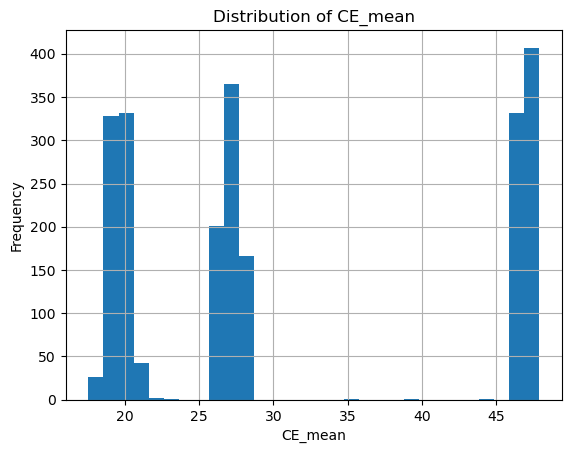

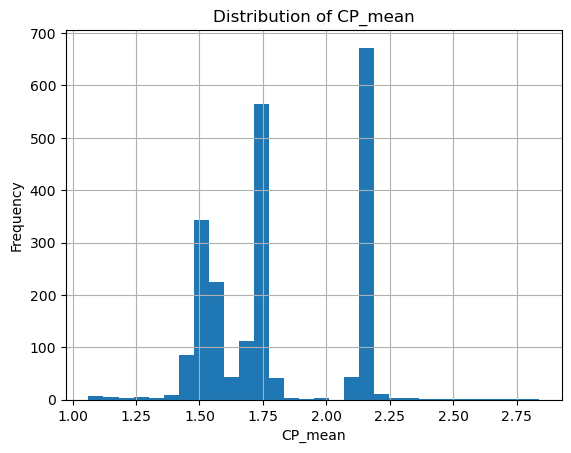

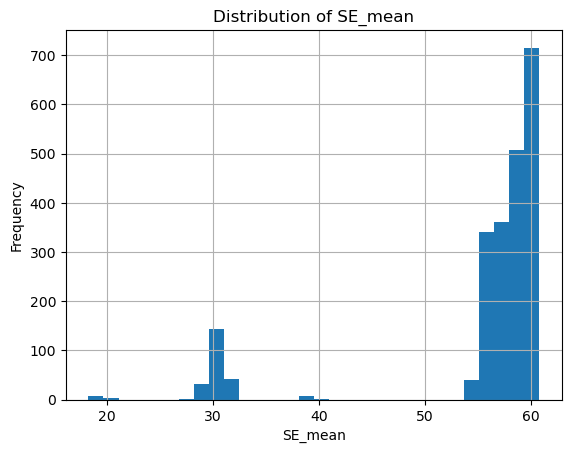

In [45]:
# Perform a basic visualization of the summary data
# I am specifically targeting cooling efficiency (CE), cooling power (CP) and system efficiency (SE) factor
# more analysis via visualization will occur in the next stage.  For now this is exploratory only.
target_candidates = ["CE_mean", "CP_mean", "SE_mean"]

for target in target_candidates:
    if target in model_data.columns:
        plt.figure()
        model_data[target].hist(bins=30)
        plt.title(f"Distribution of {target}")
        plt.xlabel(target)
        plt.ylabel("Frequency")
        plt.savefig(VISUALIZATION_DIR / f"distribution_{target}.png", bbox_inches="tight")
        plt.show()

The histogram plots above show that there are multiple mean clusters for these three targets.  At this stage I am ok with what I am seeing as I am not sure that my level of understanding of how these clusters might affect Linear Regression.  I am looking forward to seeing this play out.


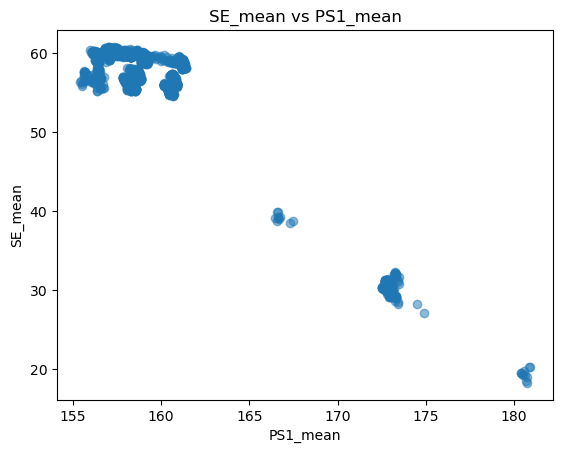

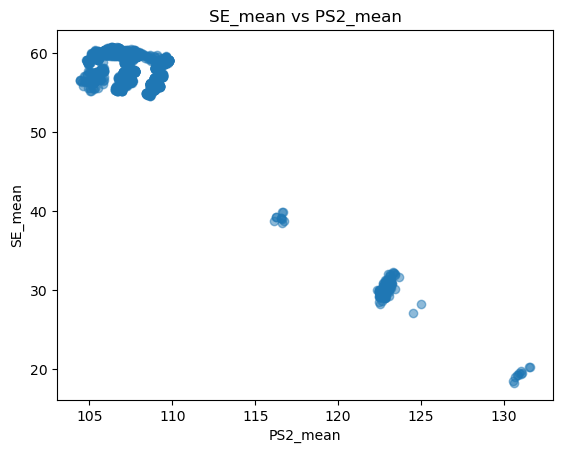

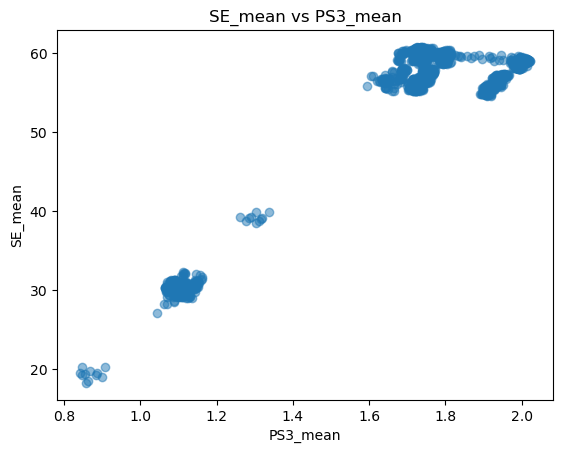

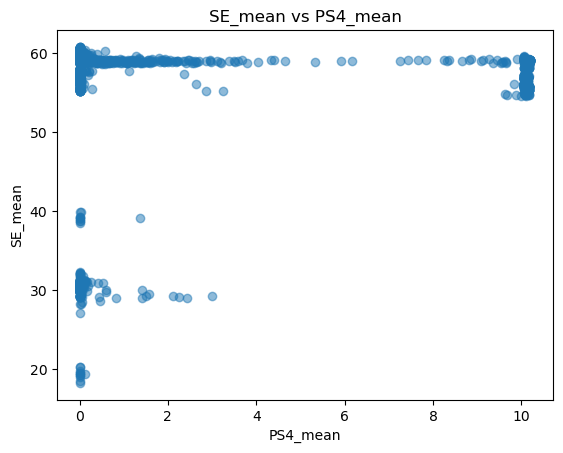

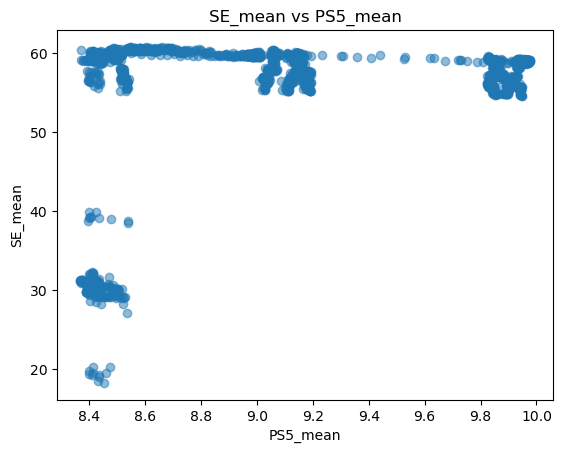

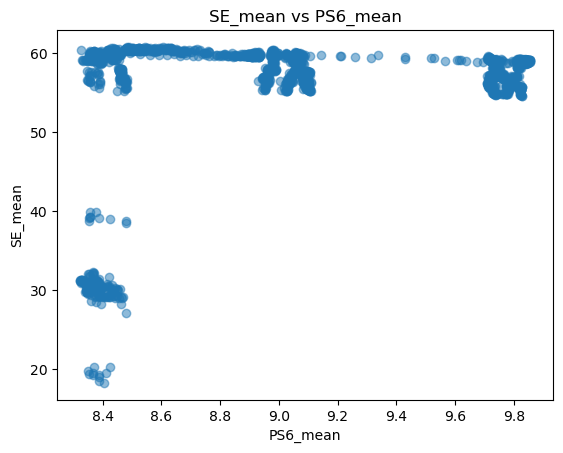

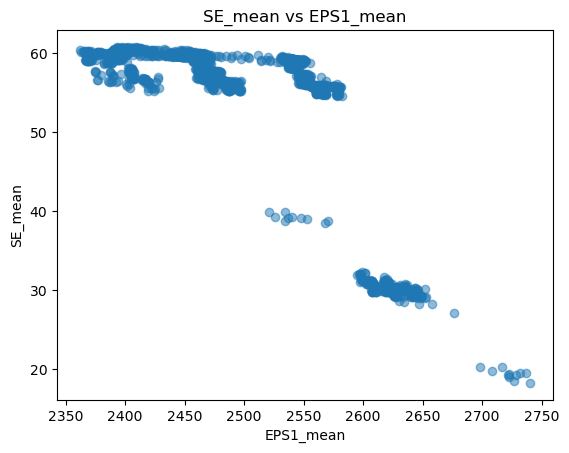

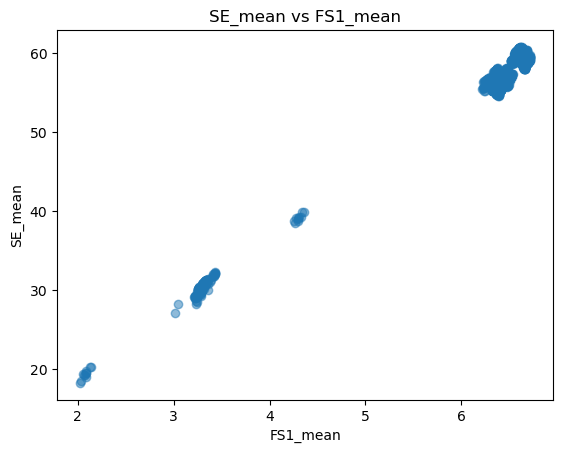

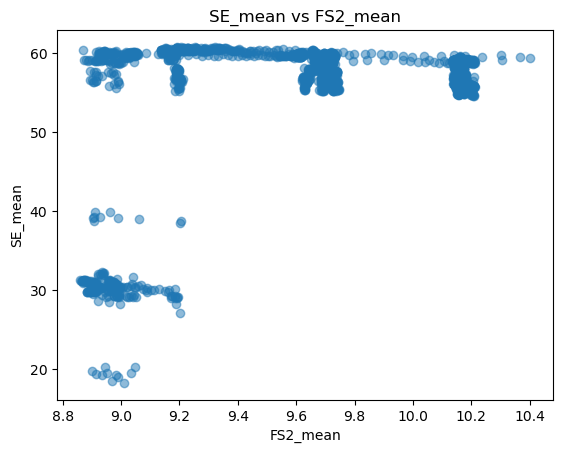

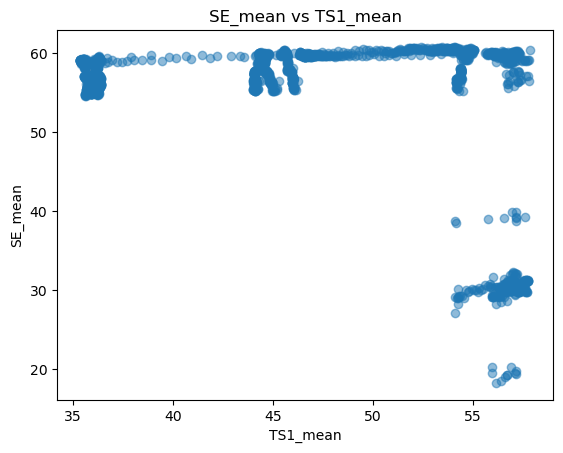

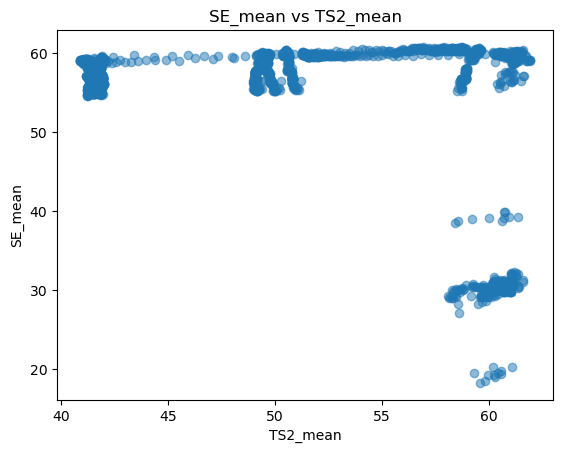

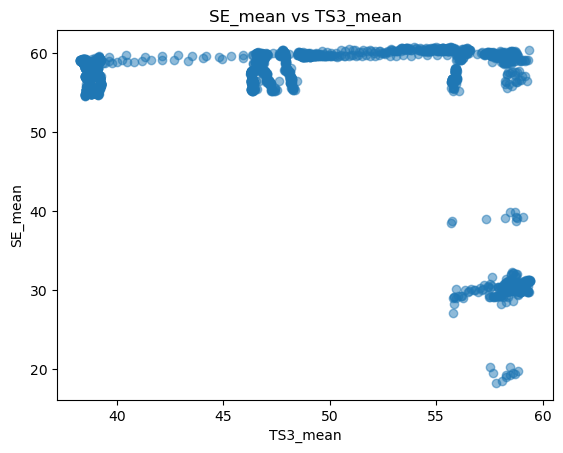

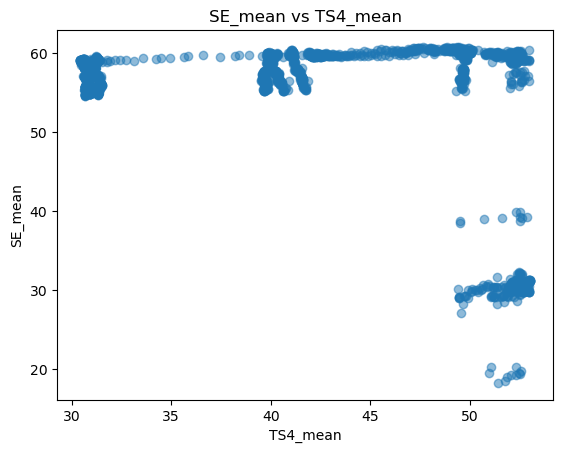

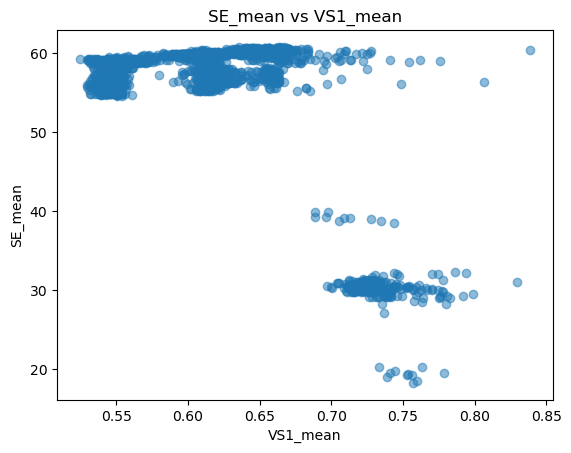

In [46]:
# TODO Turn this into a Facet Grid.  Too much scrolling
# I will use some scatter plots to further understand the Pressure Sensors (PS), Volume Flow (FS), Motor Power (EPS), Temperature (TS) 
# and vibration (VS)
candidate_predictors = [
    "PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean",
    "EPS1_mean",
    "FS1_mean", "FS2_mean",
    "TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean",
    "VS1_mean"
]

target = "SE_mean"   # change to CE_mean or CP_mean if preferred

for predictor in candidate_predictors:
    if predictor in model_data.columns and target in model_data.columns:
        plt.figure()
        plt.scatter(model_data[predictor], model_data[target], alpha=0.5)
        plt.title(f"{target} vs {predictor}")
        plt.xlabel(predictor)
        plt.ylabel(target)
        plt.savefig(VISUALIZATION_DIR / f"scatter_{target}_vs_{predictor}.png", bbox_inches="tight")
        plt.show()

In [47]:
correlation_matrix = model_data.corr(numeric_only=True)

target_correlations = (
    correlation_matrix[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

target_correlations.head(20)

FS1_mean       0.994564
SE_median      0.987842
FS1_median     0.982133
PS2_std       -0.982045
PS1_median    -0.964948
PS2_mean      -0.957972
PS1_mean      -0.943953
EPS1_std      -0.938821
PS1_std       -0.930623
PS3_median     0.924183
EPS1_median   -0.913869
PS3_mean       0.884123
FS1_std       -0.847435
SE_std        -0.815188
VS1_median    -0.755926
SE_max        -0.722258
EPS1_mean     -0.677823
VS1_mean      -0.647300
PS2_median    -0.615667
PS1_max        0.574257
Name: SE_mean, dtype: float64

There are some good correlations, negative and positive, and I am a little surprised based on the scatter plots.  It looks like at least half of these are above 85%

In [48]:
target_correlations.to_csv(DATAFRAME_DIR / f"correlations_with_{target}.csv")

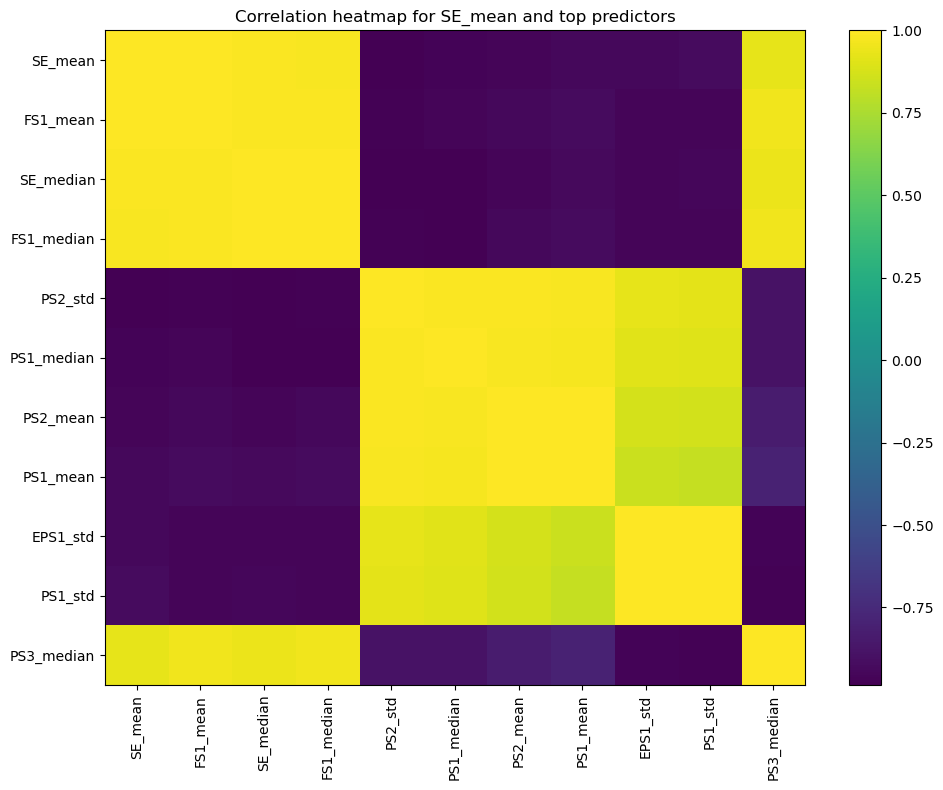

In [49]:
# TODO choose a better color theme
# Correlation heatmap
top_features = target_correlations.head(10).index.tolist()
heatmap_data = model_data[[target] + top_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar()
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=90)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title(f"Correlation heatmap for {target} and top predictors")
plt.tight_layout()
plt.savefig(VISUALIZATION_DIR / f"correlation_heatmap_{target}.png", bbox_inches="tight")
plt.show()

Lots of correlations between predictors and other predictors as well as predictors and targets

In [50]:
# TODO - Rename targets so that they are easier to identify
# I want to see if I can visualize how the target changes when the system state changes
group_summary = model_data.groupby("cooler_condition")[target].agg(["count", "mean", "std", "min", "max"])
group_summary

,count,mean,std,min,max
cooler_condition,,,,,
3,732,49.830634,13.876032,18.276617,60.755300
20,732,58.341997,1.547146,55.148783,60.370467
100,741,57.661880,1.490691,54.581733,59.686233


In [51]:
group_summary.to_csv(DATAFRAME_DIR / f"{target}_by_cooler_condition.csv")

<Figure size 640x480 with 0 Axes>

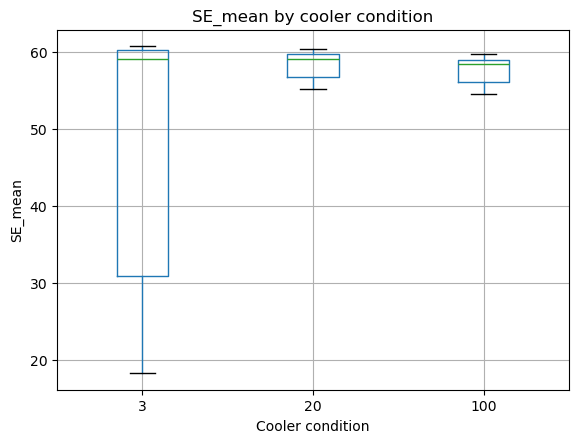

In [52]:
plt.figure()
model_data.boxplot(column=target, by="cooler_condition")
plt.title(f"{target} by cooler condition")
plt.suptitle("")
plt.xlabel("Cooler condition")
plt.ylabel(target)
plt.savefig(VISUALIZATION_DIR / f"boxplot_{target}_by_cooler_condition.png", bbox_inches="tight")
plt.show();

Interesting, I need to understand more about what these conditions mean.  Quite a tight range of values for 20 and 100 categories but the 3 is almost the entire range.


In [53]:
# still exploring but I want to see more.
# Let's see if there is any linear between the system efficiency (SE) target and the predictor sensors.
# create a small dataset of these features and target
selected_target = "SE_mean"

selected_predictors = [
    "PS1_mean",
    "PS2_mean",
    "EPS1_mean",
    "FS1_mean",
    "TS1_mean",
    "VS1_mean"
]

regression_data = model_data[selected_predictors + [selected_target]].dropna()

regression_data.head()

,PS1_mean,PS2_mean,EPS1_mean,FS1_mean,TS1_mean,VS1_mean,SE_mean
0,160.673492,109.466914,2538.929167,6.709815,35.621983,0.576950,59.157183
1,160.603320,109.354890,2531.498900,6.715315,36.676967,0.565850,59.335617
2,160.347720,109.158845,2519.928000,6.718522,37.880800,0.576533,59.543150
3,160.188088,109.064807,2511.541633,6.720565,38.879050,0.569267,59.794900
4,160.000472,108.931434,2503.449500,6.690308,39.803917,0.577367,59.455267


In [54]:
regression_data.to_csv(PROCESSED_DIR / "linear_regression_ready_data.csv", index=False)

In [55]:
# TODO How did we normalize in the course?
# Normalize the predictor variables. Using z-score scaling which I have used successfully in my work
# I keep the original scale for the target
X = regression_data[selected_predictors]
y = regression_data[selected_target]

X_normalised = (X - X.mean()) / X.std()

regression_data_normalised = pd.concat([X_normalised, y], axis=1)

regression_data_normalised.head()



,PS1_mean,PS2_mean,EPS1_mean,FS1_mean,TS1_mean,VS1_mean,SE_mean
0,0.040043,0.017448,0.588054,0.494989,-1.226560,-0.603477,59.157183
1,0.025111,-0.005017,0.487423,0.500314,-1.094554,-0.787679,59.335617
2,-0.029279,-0.044331,0.330714,0.503419,-0.943923,-0.610391,59.543150
3,-0.063247,-0.063189,0.217134,0.505397,-0.819015,-0.730980,59.794900
4,-0.103171,-0.089936,0.107539,0.476103,-0.703290,-0.596562,59.455267


In [56]:
regression_data_normalised.to_csv(PROCESSED_DIR / "linear_regression_ready_data_normalised.csv", index=False)

This completes this stage of analysis.  I have completed all the preparation steps, and am well organized in the way I store my changed data.

Each sensor file was loaded, inspected and summarised into cycle-level features. The resulting processed dataset contains one row per operating cycle and numerical predictors derived from pressure, flow, temperature, vibration and motor power readings. 

Visual analysis and correlation analysis were then used to identify suitable predictor variables for a linear regression model. This preprocessing step transforms the original multi-file time-series dataset into a clean regression-ready table while preserving the engineering meaning of the original measurements.

# Part 4 - Statistical Analysis
## Statistical Summary of Key Series

Identify the key numerical series in the hydraulic systems dataset and describe their statistical characteristics. 

In Part 3, I summarised each sensor into cycle-level series such as mean, standard deviation, minimum and maximum. These cycle-level series are more suitable for linear regression because each row represents one operating cycle.

In this part (4) for each key series, I calculate measures of central tendency, measures of spread, skewness, kurtosis and an inferred distribution type. Visualisations are also used to support the interpretation of the statistical results.

In [57]:
# TODO Check kutosis and inferred distribution type in the course
# explore the model data created in Part 3
# The Linear Regression ready dataset from Part 3 is loaded. 
# Each row represents one 60-second hydraulic operating cycle. 
# Each column represents either a derived sensor feature, such as a cycle-level mean, or a condition variable from profile.txt.

print("Rows:", model_data.shape[0])
print("Columns:", model_data.shape[1])
model_data.head()

Rows: 2205
Columns: 90


,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median,cooler_condition,valve_condition,pump_leakage,hydraulic_accumulator,stable_flag
0,39.601350,6.370535,28.866,47.438,40.6755,1.862750,0.279385,1.383,2.188,1.9240,2538.929167,185.616121,2339.8,2951.6,2479.8,6.709815,3.015428,0.0,18.710,7.836,10.304592,0.091772,10.148,10.446,10.327,160.673492,13.939309,145.83,191.51,156.25,109.466914,47.114508,0.0,156.99,129.365,1.991475,0.945705,0.0,10.039,2.297,0.0,0.0,0.0,0.0,0.0,9.842170,0.088154,9.681,10.016,9.844,9.728097,0.085366,9.568,9.887,9.733,59.157183,23.763984,0.0,79.568,68.5145,35.621983,0.308230,35.156,36.152,35.5720,40.978767,0.154302,40.773,41.250,40.9630,38.471017,0.084659,38.316,38.613,38.4960,31.745250,1.116478,30.363,33.594,31.576,0.576950,0.027078,0.532,0.624,0.5770,3,100,0,130,1
1,25.786433,1.686129,23.320,29.208,25.3855,1.255550,0.074605,1.147,1.414,1.2340,2531.498900,189.940089,2332.0,2947.4,2470.0,6.715315,3.006248,0.0,18.712,7.853,10.403098,0.019162,10.352,10.453,10.403,160.603320,14.118967,145.73,191.47,156.06,109.354890,47.045611,0.0,157.56,129.385,1.976234,0.941967,0.0,9.992,2.273,0.0,0.0,0.0,0.0,0.0,9.635142,0.038392,9.557,9.745,9.632,9.529488,0.036316,9.454,9.637,9.526,59.335617,23.857918,0.0,80.441,68.5360,36.676967,0.585740,35.648,37.488,36.7675,41.532767,0.338234,41.031,42.105,41.5180,38.978967,0.176921,38.668,39.254,38.9845,34.493867,0.435312,33.648,35.148,34.553,0.565850,0.027241,0.524,0.626,0.5595,3,100,0,130,1
2,22.218233,0.638345,21.220,23.554,22.1040,1.113217,0.023263,1.076,1.159,1.1095,2519.928000,190.736850,2318.6,2939.8,2457.4,6.718522,3.014248,0.0,18.698,7.847,10.366250,0.026361,10.296,10.443,10.367,160.347720,14.192619,145.37,191.41,155.72,109.158845,46.992060,0.0,156.97,129.325,1.972224,0.943501,0.0,10.914,2.273,0.0,0.0,0.0,0.0,0.0,9.530548,0.035817,9.455,9.640,9.528,9.427949,0.036031,9.348,9.536,9.425,59.543150,23.923381,0.0,80.824,68.8530,37.880800,0.559169,36.879,38.621,38.0235,42.442450,0.390588,41.832,43.039,42.4235,39.631950,0.251133,39.234,40.062,39.6270,35.646150,0.293889,35.098,36.141,35.635,0.576533,0.036729,0.529,0.662,0.5620,3,100,0,130,1
3,20.459817,0.455755,19.673,21.565,20.4805,1.062150,0.024621,1.022,1.107,1.0660,2511.541633,191.270607,2310.8,2929.6,2448.0,6.720565,3.020176,0.0,18.896,7.843,10.302678,0.026750,10.241,10.382,10.302,160.188088,14.227803,145.14,191.34,155.56,109.064807,46.972221,0.0,156.44,128.865,1.946575,0.935534,0.0,10.297,2.242,0.0,0.0,0.0,0.0,0.0,9.438827,0.037069,9.363,9.535,9.436,9.337430,0.037375,9.257,9.431,9.335,59.794900,24.023005,0.0,80.930,69.0060,38.879050,0.516176,37.887,39.473,39.0550,43.403983,0.398476,42.805,43.988,43.3650,40.403383,0.285434,40.023,40.934,40.3420,36.579467,0.262397,36.105,36.988,36.635,0.569267,0.033464,0.527,0.645,0.5550,3,100,0,130,1
4,19.787017,0.290156,19.133,20.460,19.7985,1.070467,0.021477,1.016,1.106,1.0725,2503.449500,191.258369,2301.8,2923.8,2440.6,6.690308,3.011550,0.0,18.876,7.831,10.237750,0.029170,10.179,10.312,10.236,160.000472,14.276434,144.95,191.41,155.34,108.931434,46.874946,0.0,158.13,129.000,1.922707,0.930335,0.0,11.102,2.219,0.0,0.0,0.0,0.0,0.0,9.358762,0.029779,9.290,9.443,9.358,9.260636,0.028592,9.195,9.342,9.260,59.455267,23.972262,0.0,81.100,69.0130,39.803917,0.535374,38.789,40.391,39.9670,44.332750,0.372769,43.742,44.887,44.3355,41.31055

In [58]:
# in part 3 I created a list of 'candidate sensors'.  Here I create the actual sensors list that will be used from here on.

key_series = [
    "PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean",
    "EPS1_mean",
    "FS1_mean", "FS2_mean",
    "TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean",
    "VS1_mean",
    "CE_mean", "CP_mean", "SE_mean"
]

key_series = [col for col in key_series if col in model_data.columns]

print("Key series available:")
for col in key_series:
    print(col)

Key series available:
PS1_mean
PS2_mean
PS3_mean
PS4_mean
PS5_mean
PS6_mean
EPS1_mean
FS1_mean
FS2_mean
TS1_mean
TS2_mean
TS3_mean
TS4_mean
VS1_mean
CE_mean
CP_mean
SE_mean


In [59]:
# TODO How did we normalize in the course?
# Normalize the predictor variables. Using z-score scaling which I have used successfully in my work
# I keep the original scale for the target
features = [
    "PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean",
    "EPS1_mean",
    "FS1_mean", "FS2_mean",
    "TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean",
    "VS1_mean"
    ]

targets = ["CE_mean", "CP_mean", "SE_mean"]

regression_data = model_data[features + targets].dropna()

regression_data.head()


X = regression_data[features]
y = regression_data[targets]

X_normalised = (X - X.mean()) / X.std()

model_normalized = pd.concat([X_normalised, y], axis=1)

model_normalized.head()


,PS1_mean,PS2_mean,PS3_mean,PS4_mean,PS5_mean,PS6_mean,EPS1_mean,FS1_mean,FS2_mean,TS1_mean,TS2_mean,TS3_mean,TS4_mean,VS1_mean,CE_mean,CP_mean,SE_mean
0,0.040043,0.017448,0.945797,-0.60763,1.177952,1.180399,0.588054,0.494989,1.458308,-1.226560,-1.269185,-1.233393,-1.108848,-0.603477,39.601350,1.862750,59.157183
1,0.025111,-0.005017,0.885293,-0.60763,0.818714,0.819021,0.487423,0.500314,1.677580,-1.094554,-1.194282,-1.165229,-0.769842,-0.787679,25.786433,1.255550,59.335617
2,-0.029279,-0.044331,0.869373,-0.60763,0.637220,0.634266,0.330714,0.503419,1.595557,-0.943923,-1.071289,-1.077602,-0.627723,-0.610391,22.218233,1.113217,59.543150
3,-0.063247,-0.063189,0.767553,-0.60763,0.478064,0.469563,0.217134,0.505397,1.454049,-0.819015,-0.941287,-0.974080,-0.512611,-0.730980,20.459817,1.062150,59.794900
4,-0.103171,-0.089936,0.672800,-0.60763,0.339134,0.329834,0.107539,0.476103,1.309522,-0.703290,-0.815714,-0.852344,-0.407968,-0.596562,19.787017,1.070467,59.455267


The summary function in the cell below calculates measures of central tendency using the mean and median. It calculates measures of spread using standard deviation, variance, range and interquartile range. Skewness is used to describe whether the data is balanced, right-skewed or left-skewed. Kurtosis is used to describe whether the distribution has normal-like, heavy or flat tails.

In [60]:
# Create statistical summary function
def classify_distribution(skewness, kurtosis):
    """
    Classifies the approximate distribution shape using skewness and kurtosis.
    Kurtosis is interpreted using Fisher's definition, where 0 is close to normal.
    """
    if abs(skewness) < 0.5:
        skew_label = "approximately symmetric"
    elif skewness >= 0.5:
        skew_label = "right-skewed"
    else:
        skew_label = "left-skewed"
    
    if kurtosis > 1:
        tail_label = "heavy-tailed"
    elif kurtosis < -1:
        tail_label = "light-tailed or flat"
    else:
        tail_label = "normal-like tails"
    
    return f"{skew_label}, {tail_label}"


def summarise_series(series, series_name):
    """
    Produces a statistical summary for one numerical series.
    """
    clean_series = pd.to_numeric(series, errors="coerce").dropna()
    
    if len(clean_series) == 0:
        return {
            "series": series_name,
            "count": 0
        }
    
    mean_value = clean_series.mean()
    median_value = clean_series.median()
    std_value = clean_series.std()
    variance_value = clean_series.var()
    min_value = clean_series.min()
    max_value = clean_series.max()
    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1
    data_range = max_value - min_value
    skewness = stats.skew(clean_series)
    kurtosis = stats.kurtosis(clean_series)  # Fisher=True by default
    
    return {
        "series": series_name,
        "count": len(clean_series),
        "mean": mean_value,
        "median": median_value,
        "std_dev": std_value,
        "variance": variance_value,
        "min": min_value,
        "q1": q1,
        "q3": q3,
        "max": max_value,
        "range": data_range,
        "iqr": iqr,
        "skewness": skewness,
        "kurtosis": kurtosis,
        "distribution_type": classify_distribution(skewness, kurtosis)
    }

In [61]:
# Create a statistical summary table
# This table directly supports the coursework requirement to report central tendency, spread, skewness, kurtosis and distribution type.
summary_rows = []

for col in key_series:
    summary_rows.append(summarise_series(model_normalized[col], col))

summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.round(4)

summary_df

,series,count,mean,median,std_dev,variance,min,q1,q3,max,range,iqr,skewness,kurtosis,distribution_type
0,PS1_mean,2205,0.0000,-0.3244,1.0000,1.0000,-1.0839,-0.5075,0.1097,4.3489,5.4328,0.6172,2.0994,3.6797,"right-skewed, heavy-tailed"
1,PS2_mean,2205,-0.0000,-0.3308,1.0000,1.0000,-0.9974,-0.4848,0.0084,4.4538,5.4512,0.4932,2.2861,4.1995,"right-skewed, heavy-tailed"
2,PS3_mean,2205,-0.0000,0.1048,1.0000,1.0000,-3.6243,-0.0933,0.7099,1.0725,4.6969,0.8031,-1.7100,2.3906,"left-skewed, heavy-tailed"
3,PS4_mean,2205,0.0000,-0.6076,1.0000,1.0000,-0.6076,-0.6076,0.2110,1.7776,2.3852,0.8186,1.1473,-0.6372,"right-skewed, normal-like tails"
4,PS5_mean,2205,0.0000,-0.0825,1.0000,1.0000,-1.3839,-1.0690,1.1817,1.4145,2.7984,2.2508,0.1504,-1.4620,"approximately symmetric, light-tailed or flat"
5,PS6_mean,2205,-0.0000,-0.0871,1.0000,1.0000,-1.3789,-1.0775,1.1825,1.4142,2.7931,2.2601,0.1528,-1.4628,"approximately symmetric, light-tailed or flat"
6,EPS1_mean,2205,-0.0000,-0.1975,1.0000,1.0000,-1.8116,-0.7121,0.7138,3.3199,5.1315,1.4258,0.2235,-0.6804,"approximately symmetric, normal-like tails"
7,FS1_mean,2205,-0.0000,0.3661,1.0000,1.0000,-4.0469,0.1870,0.4443,0.5075,4.5544,0.2574,-2.5078,4.5659,"left-skewed, heavy-tailed"
8,FS2_mean,2205,0.0000,0.0953,1.0000,1.0000,-1.7628,-0.9929,1.1253,1.6776,3.4404,2.1182,-0.2434,-1.2713,"approximately symmetric, light-tailed or flat"
9,TS1_mean,2205,-0.0000,-0.0736,1.0000,1.0000,-1.2651,-1.1496,1.0861,1.5609,2.8260,2.2357,0.1087,-1.4105,"approximately symmetric, light-tailed or flat"


In [62]:
summary_df.to_csv(DATAFRAME_DIR / "key_series_statistical_summary.csv", index=False)

In [63]:
# Sort by skewness and kurtosis
# Sorting by skewness helps identify variables where the mean and median may differ noticeably. 
# Sorting by kurtosis helps identify variables with unusually heavy tails or flat distributions. 

# Note: the key=abs parameter.  If you just glance at the list you will see that the order visually does
# not correspond with what you are expecting and the reason for this is that the sorted columns are
# in absolute values and not their actual values.

summary_by_skewness = summary_df.sort_values("skewness", key=abs, ascending=False)
summary_by_kurtosis = summary_df.sort_values("kurtosis", key=abs, ascending=False)

display(summary_by_skewness[["series", "mean", "median", "std_dev", "skewness", "kurtosis", "distribution_type"]])
display(summary_by_kurtosis[["series", "mean", "median", "std_dev", "skewness", "kurtosis", "distribution_type"]])

,series,mean,median,std_dev,skewness,kurtosis,distribution_type
7,FS1_mean,-0.0000,0.3661,1.0000,-2.5078,4.5659,"left-skewed, heavy-tailed"
16,SE_mean,55.2879,58.7582,8.9602,-2.4369,4.3799,"left-skewed, heavy-tailed"
1,PS2_mean,-0.0000,-0.3308,1.0000,2.2861,4.1995,"right-skewed, heavy-tailed"
0,PS1_mean,0.0000,-0.3244,1.0000,2.0994,3.6797,"right-skewed, heavy-tailed"
2,PS3_mean,-0.0000,0.1048,1.0000,-1.7100,2.3906,"left-skewed, heavy-tailed"
3,PS4_mean,0.0000,-0.6076,1.0000,1.1473,-0.6372,"right-skewed, normal-like tails"
13,VS1_mean,-0.0000,-0.0520,1.0000,0.7190,-0.0522,"right-skewed, normal-like tails"
14,CE_mean,31.2991,27.3925,11.5753,0.4639,-1.5075,"approximately symmetric, light-tailed or flat"
15,CP_mean,1.8084,1.7397,0.2783,0.3041,-0.9785,"approximately symmetric, normal-like tails"
8,FS2_mean,0.0000,0.0953,1.0000,-0.2434,-1.2713,"approximately symmetric, light-tailed or flat"


,series,mean,median,std_dev,skewness,kurtosis,distribution_type
7,FS1_mean,-0.0000,0.3661,1.0000,-2.5078,4.5659,"left-skewed, heavy-tailed"
16,SE_mean,55.2879,58.7582,8.9602,-2.4369,4.3799,"left-skewed, heavy-tailed"
1,PS2_mean,-0.0000,-0.3308,1.0000,2.2861,4.1995,"right-skewed, heavy-tailed"
0,PS1_mean,0.0000,-0.3244,1.0000,2.0994,3.6797,"right-skewed, heavy-tailed"
2,PS3_mean,-0.0000,0.1048,1.0000,-1.7100,2.3906,"left-skewed, heavy-tailed"
14,CE_mean,31.2991,27.3925,11.5753,0.4639,-1.5075,"approximately symmetric, light-tailed or flat"
5,PS6_mean,-0.0000,-0.0871,1.0000,0.1528,-1.4628,"approximately symmetric, light-tailed or flat"
4,PS5_mean,0.0000,-0.0825,1.0000,0.1504,-1.4620,"approximately symmetric, light-tailed or flat"
10,TS2_mean,-0.0000,-0.0791,1.0000,0.0879,-1.4347,"approximately symmetric, light-tailed or flat"
12,TS4_mean,0.0000,-0.0378,1.0000,0.0576,-1.4182,"approximately symmetric, light-tailed or flat"


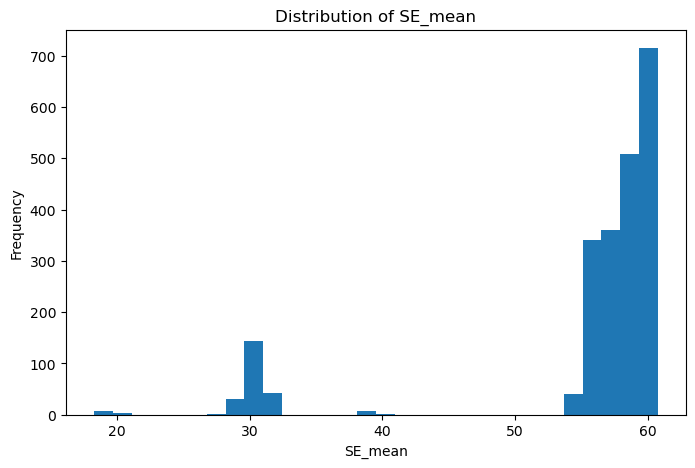

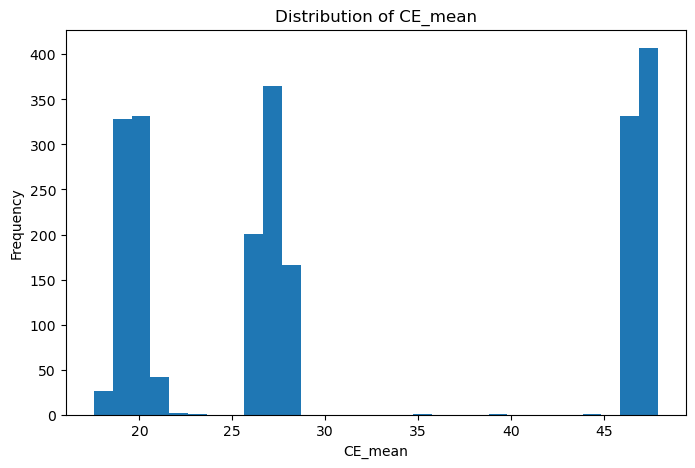

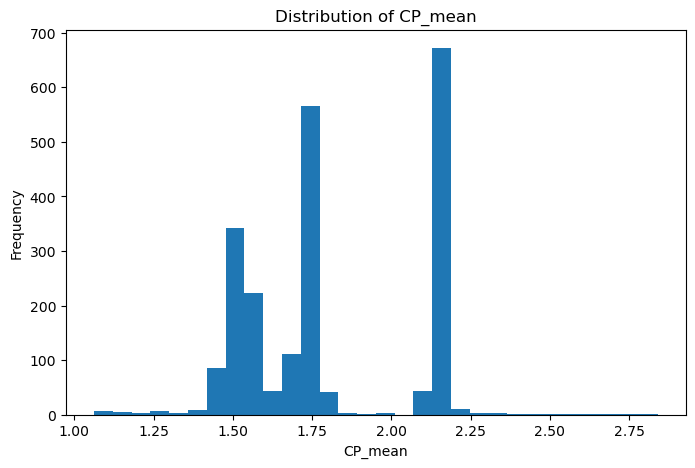

In [64]:
# Target variable histograms
# Visualizations are not meant until Part 5 but they are a very useful tool when
# exploring statistical data
target_candidates = ["SE_mean", "CE_mean", "CP_mean"]

for col in target_candidates:
    if col in model_normalized.columns:
        plt.figure(figsize=(8, 5))
        plt.hist(model_normalized[col].dropna(), bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.savefig(VISUALIZATION_DIR / f"histogram_{col}.png", bbox_inches="tight")
        plt.show()

From the above histograms, and as per Part 3, there are clusters apparent in the target data

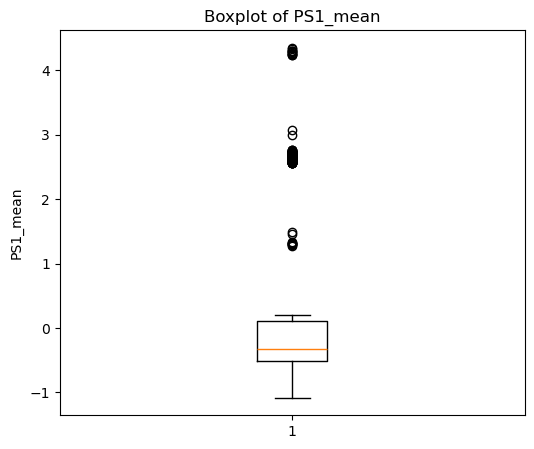

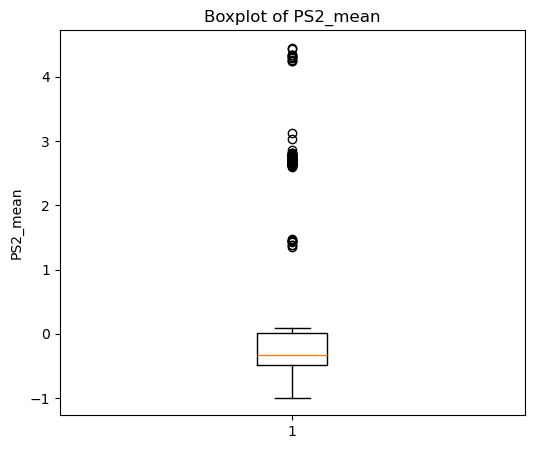

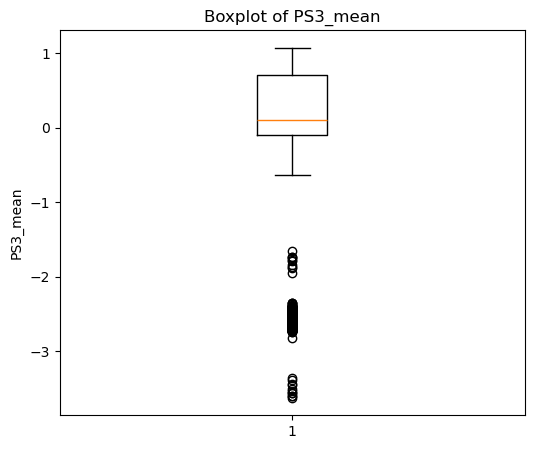

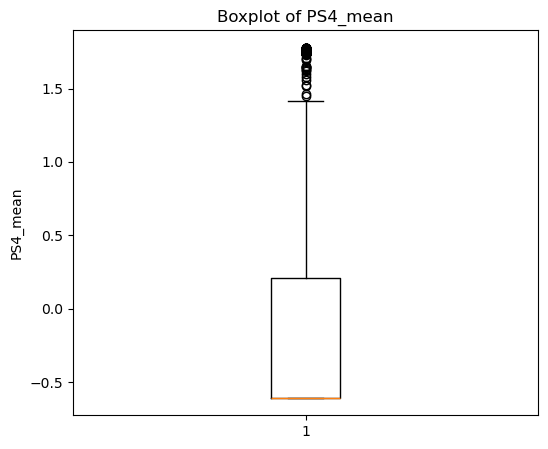

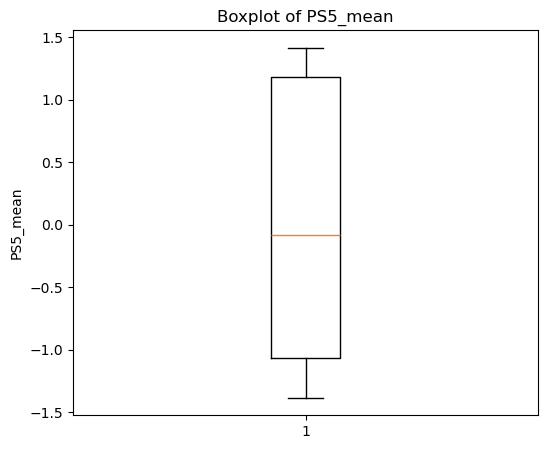

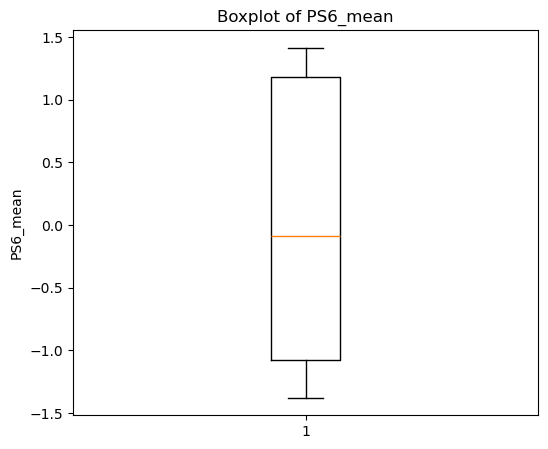

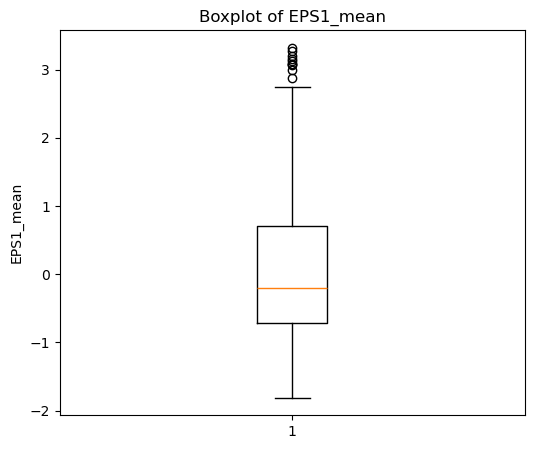

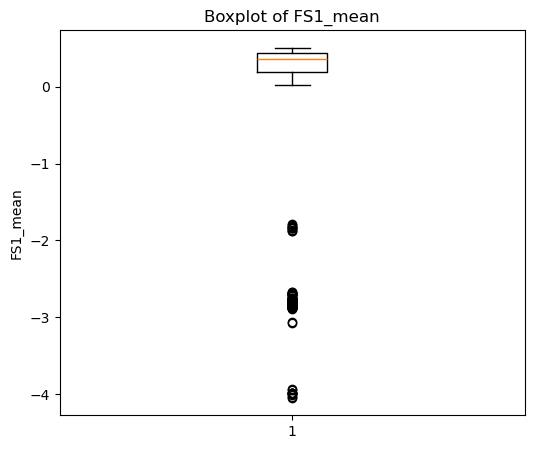

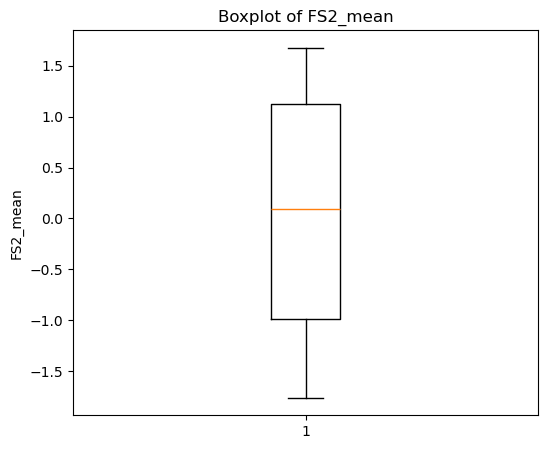

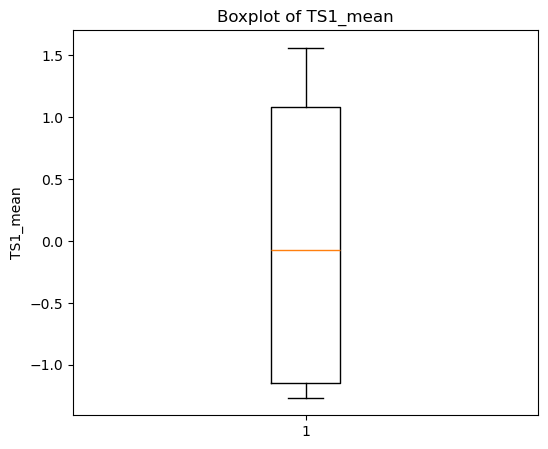

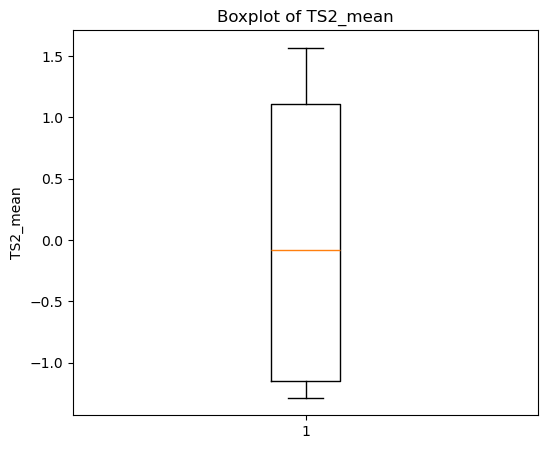

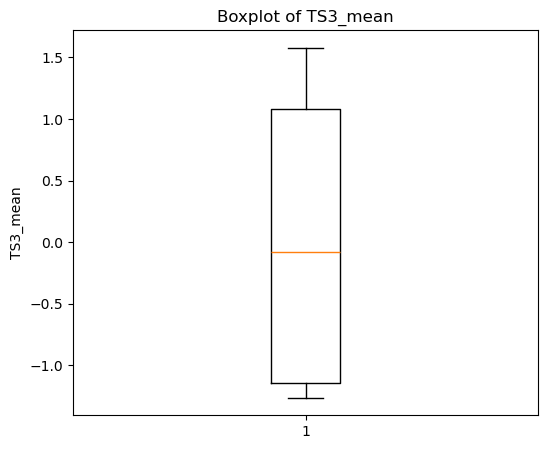

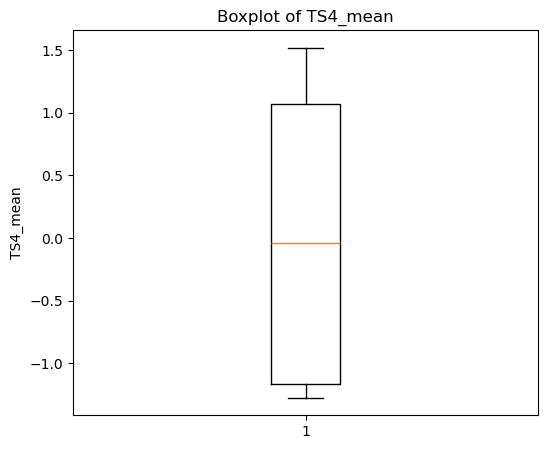

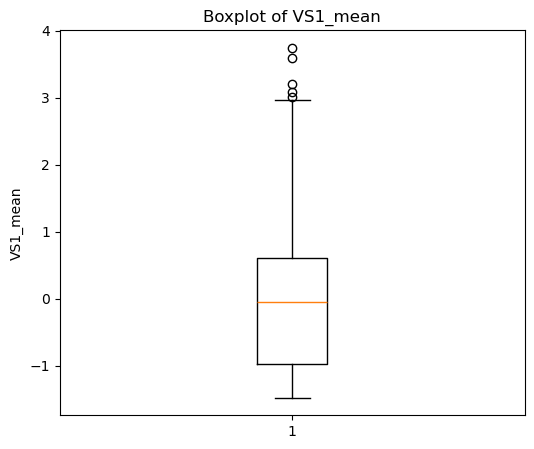

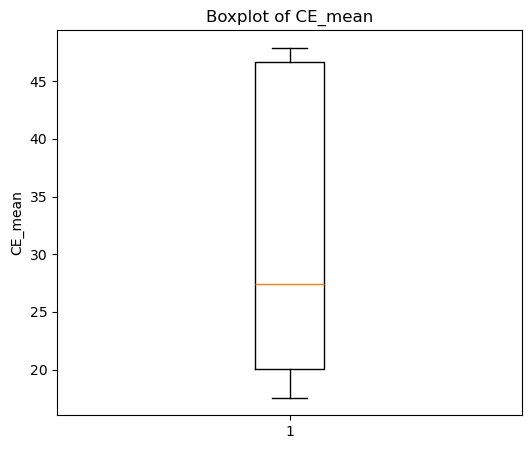

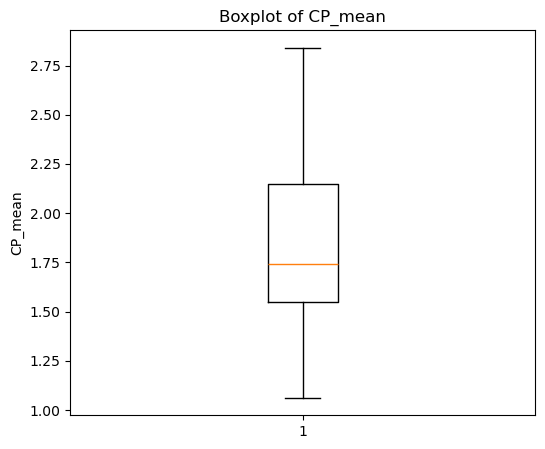

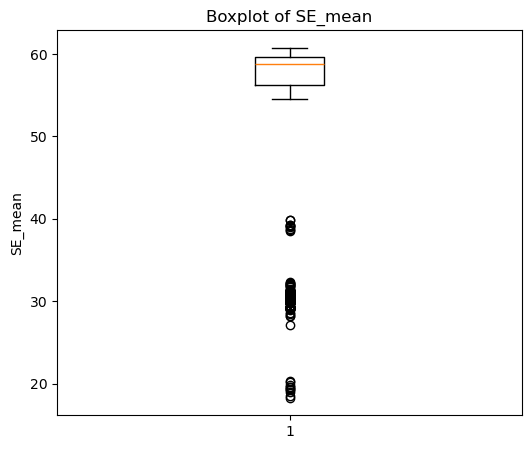

In [65]:
# Lets check outliers using boxplots
# Boxplots are used to inspect spread, median position and possible outliers. 
# They are useful because standard deviation alone can be affected by extreme values. 
# The interquartile range and median shown in the boxplot provide a more robust view of the typical behaviour of each sensor series.
# TODO Facet these
for col in key_series:
    plt.figure(figsize=(6, 5))
    plt.boxplot(model_normalized[col].dropna(), vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.savefig(VISUALIZATION_DIR / f"boxplot_{col}.png", bbox_inches="tight")
    plt.show()

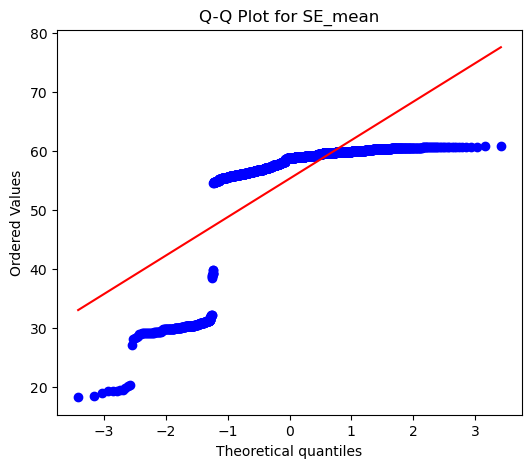

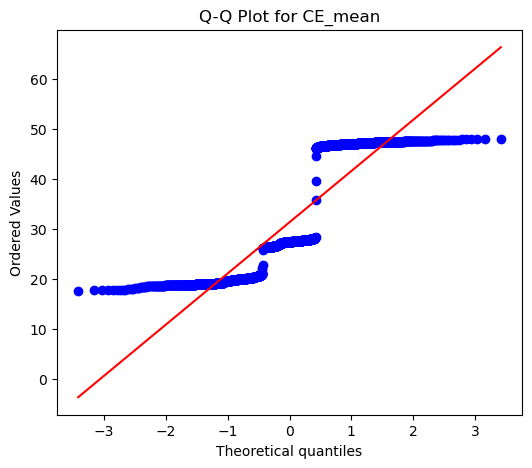

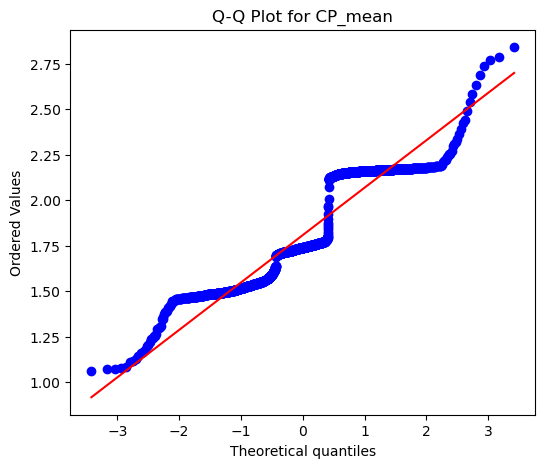

In [66]:
# Q-Q plots
# Q-Q plots compare the observed data against a theoretical normal distribution. 
# If the points follow the diagonal line closely, the series is approximately normal. 
# Curved patterns suggest skewness or heavy tails. 
# This is useful because linear regression does not require every predictor to be normally distributed, 
# but strongly skewed variables or extreme outliers can affect model interpretation and error behaviour.

# TODO Reference course work
for col in target_candidates:
    if col in regression_data.columns:
        clean_series = model_data[col].dropna()
        
        plt.figure(figsize=(6, 5))
        stats.probplot(clean_series, dist="norm", plot=plt)
        plt.title(f"Q-Q Plot for {col}")
        plt.savefig(VISUALIZATION_DIR / f"qqplot_{col}.png", bbox_inches="tight")
        plt.show()

In [67]:
# Compare median and mean
# The comparison between mean and median helps identify whether the mean is a reliable description of the typical value. 
# When the mean and median are close together, the distribution is likely more balanced. When they differ noticeably, the median may be more informative because it is less affected by skewness and extreme values.
summary_df["mean_minus_median"] = summary_df["mean"] - summary_df["median"]
summary_df["absolute_mean_median_difference"] = summary_df["mean_minus_median"].abs()

mean_median_comparison = summary_df.sort_values(
    "absolute_mean_median_difference", 
    ascending=False
)

mean_median_comparison[
    ["series", "mean", "median", "mean_minus_median", "skewness", "distribution_type"]
]

,series,mean,median,mean_minus_median,skewness,distribution_type
14,CE_mean,31.2991,27.3925,3.9066,0.4639,"approximately symmetric, light-tailed or flat"
16,SE_mean,55.2879,58.7582,-3.4703,-2.4369,"left-skewed, heavy-tailed"
3,PS4_mean,0.0000,-0.6076,0.6076,1.1473,"right-skewed, normal-like tails"
7,FS1_mean,-0.0000,0.3661,-0.3661,-2.5078,"left-skewed, heavy-tailed"
1,PS2_mean,-0.0000,-0.3308,0.3308,2.2861,"right-skewed, heavy-tailed"
0,PS1_mean,0.0000,-0.3244,0.3244,2.0994,"right-skewed, heavy-tailed"
6,EPS1_mean,-0.0000,-0.1975,0.1975,0.2235,"approximately symmetric, normal-like tails"
2,PS3_mean,-0.0000,0.1048,-0.1048,-1.7100,"left-skewed, heavy-tailed"
8,FS2_mean,0.0000,0.0953,-0.0953,-0.2434,"approximately symmetric, light-tailed or flat"
5,PS6_mean,-0.0000,-0.0871,0.0871,0.1528,"approximately symmetric, light-tailed or flat"


# Summary - REVIEW

The statistical summary shows that the dataset contains multiple numerical series with different distribution shapes. For approximately symmetric variables, the mean and median are close together, so the mean is a useful measure of central tendency. For skewed variables, the median is more informative because it is less affected by extreme values. Standard deviation and interquartile range show how much variation exists across operating cycles. Variables with high standard deviation or high interquartile range may be more useful for regression because they contain more variation for the model to explain.

Skewness and kurtosis add further insight. Skewness indicates whether values are concentrated on one side of the distribution, while kurtosis indicates whether the distribution has unusually heavy or flat tails. Series with high skewness or kurtosis should be inspected carefully because they may represent changing operating conditions, outliers or component degradation. For this project, the most important series are the efficiency-related variables, especially SE_mean, because the project objective is to predict hydraulic efficiency from sensor data. The most interesting predictors are likely to be the pressure, flow, temperature, vibration and motor power variables that show meaningful spread and a visible relationship with the efficiency target.

# Most interesting measure and why
# REVIEW
Need to work on these
1. Identification of the key series:
   Pressure, flow, temperature, vibration, motor power and efficiency variables.

2. Measures of central tendency:
   Mean and median.

3. Measures of spread:
   Standard deviation, variance, range and interquartile range.

4. Distribution type:
   Interpreted using histogram shape, skewness and kurtosis.

5. Analysis of findings:
   Explain whether mean or median is more useful, which variables are most variable, and why skewness/kurtosis matter for linear regression.

The most interesting measures are skewness and the difference between the mean and median. This is because the project is concerned with predicting hydraulic efficiency, and skewed sensor variables may indicate that the system does not behave the same way across all operating cycles. If a predictor has strong skewness, the median may better describe normal operation than the mean. Similarly, if an efficiency variable such as SE_mean is highly skewed, a linear regression model may need careful interpretation because the model may fit the dominant operating condition better than the less common degraded conditions.

# Final Conclusion for Part 4
The goal is to identify key series that predict a target (SE).  Need to work on this. I think all series are valid although temperature and pressure seem stronger.

# REVIEW
The key series selected for statistical analysis were the cycle-level means for pressure, flow, temperature, vibration, motor power and efficiency variables. These were selected because they represent the main physical behaviour of the hydraulic system and are suitable for later linear regression. For each series, the mean and median were used to describe central tendency, while standard deviation, variance, range and interquartile range were used to describe spread. Skewness and kurtosis were calculated to assess distribution shape. Variables where the mean and median were close together were interpreted as approximately balanced, while variables with larger differences were treated as skewed. In this dataset, the median and interquartile range are particularly useful because sensor readings may be affected by different operating conditions and occasional extreme values. Skewness and kurtosis are also important because highly skewed or heavy-tailed variables may affect the reliability and interpretation of a linear regression model.

# Part 5 Data Visualisation

This section visualises key series from the hydraulic systems dataset. The purpose is to understand the distribution of possible target variables, inspect relationships between sensor readings and hydraulic efficiency, identify outliers, and decide which variables are most suitable for linear regression.

The main target variable used in this section is SE_mean, which represents the average system efficiency factor for each hydraulic operating cycle. Key predictor variables include pressure, flow, temperature, vibration and motor power sensor summaries.

In [68]:
print(model_normalized.shape)
model_normalized.head()

(2205, 17)


,PS1_mean,PS2_mean,PS3_mean,PS4_mean,PS5_mean,PS6_mean,EPS1_mean,FS1_mean,FS2_mean,TS1_mean,TS2_mean,TS3_mean,TS4_mean,VS1_mean,CE_mean,CP_mean,SE_mean
0,0.040043,0.017448,0.945797,-0.60763,1.177952,1.180399,0.588054,0.494989,1.458308,-1.226560,-1.269185,-1.233393,-1.108848,-0.603477,39.601350,1.862750,59.157183
1,0.025111,-0.005017,0.885293,-0.60763,0.818714,0.819021,0.487423,0.500314,1.677580,-1.094554,-1.194282,-1.165229,-0.769842,-0.787679,25.786433,1.255550,59.335617
2,-0.029279,-0.044331,0.869373,-0.60763,0.637220,0.634266,0.330714,0.503419,1.595557,-0.943923,-1.071289,-1.077602,-0.627723,-0.610391,22.218233,1.113217,59.543150
3,-0.063247,-0.063189,0.767553,-0.60763,0.478064,0.469563,0.217134,0.505397,1.454049,-0.819015,-0.941287,-0.974080,-0.512611,-0.730980,20.459817,1.062150,59.794900
4,-0.103171,-0.089936,0.672800,-0.60763,0.339134,0.329834,0.107539,0.476103,1.309522,-0.703290,-0.815714,-0.852344,-0.407968,-0.596562,19.787017,1.070467,59.455267


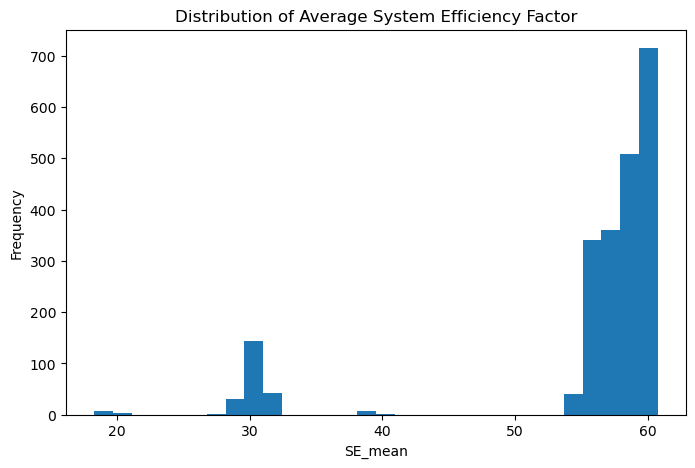

In [69]:
# The goal of the project is to predict hydraulic system efficiency so this section will work 
# with the SE_mean

target = "SE_mean"

plt.figure(figsize=(8, 5))
plt.hist(model_normalized[target].dropna(), bins=30)
plt.title("Distribution of Average System Efficiency Factor")
plt.xlabel("SE_mean")
plt.ylabel("Frequency")
plt.savefig(VISUALIZATION_DIR / "histogram_SE_mean.png", bbox_inches="tight")
plt.show()

This histogram shows how average system efficiency is distributed across the hydraulic operating cycles. It helps identify whether the target variable is evenly spread, clustered, skewed, or affected by unusual values. This is important because linear regression works best when the target variable has meaningful variation and is not dominated by a small number of extreme values.

The histogram shows that SE_mean is skewed and clustered into groups. This suggests that the hydraulic system operated under varied efficiency conditions across the cycles. The distribution is useful because it confirms whether SE_mean has enough variation to be used as a regression target.

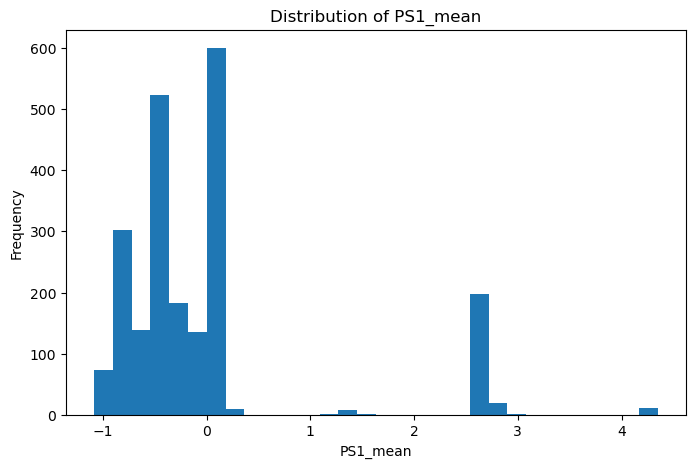

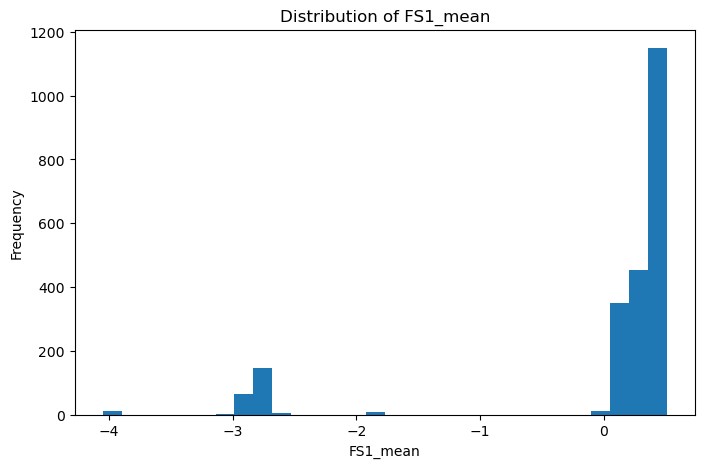

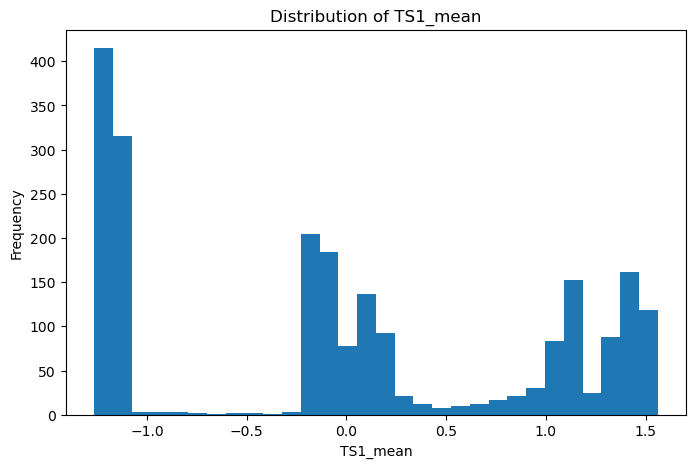

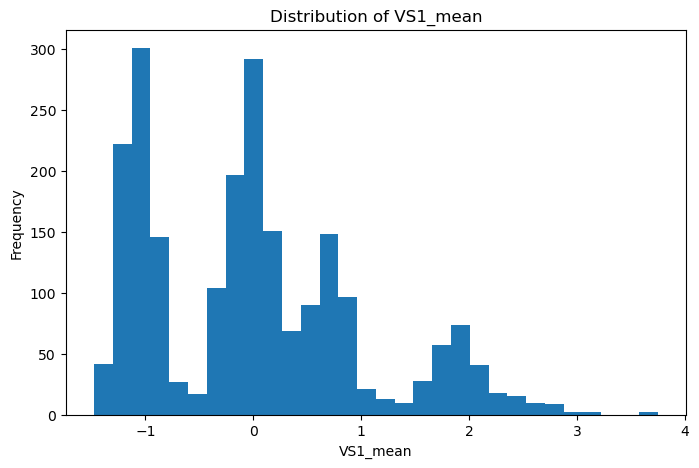

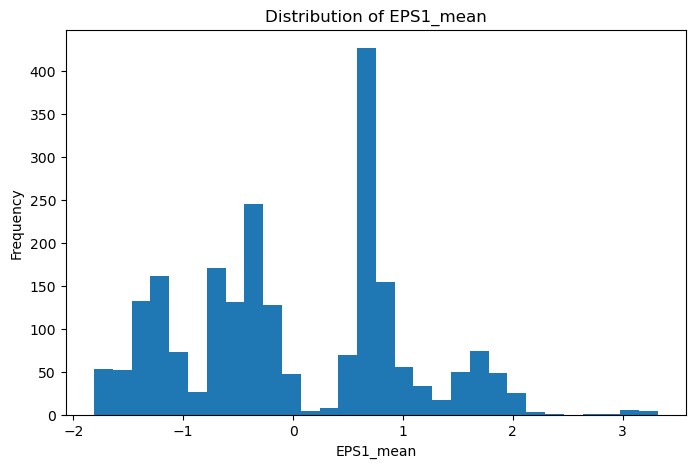

In [70]:
# Visualise key sensor distributions
key_predictors = [
    "PS1_mean", "FS1_mean", "TS1_mean", 
    "VS1_mean", "EPS1_mean"
]

for col in key_predictors:
    if col in model_normalized.columns:
        plt.figure(figsize=(8, 5))
        plt.hist(model_normalized[col].dropna(), bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.savefig(VISUALIZATION_DIR / f"histogram_{col}.png", bbox_inches="tight")
        plt.show()

These histograms show the distributions of the main predictor variables: pressure, flow, temperature, vibration and motor power. This helps identify whether each variable has useful variation, whether values are concentrated in narrow ranges, and whether any variable may contain extreme values.

The predictor histograms show that some sensor variables have wider spread than others. Variables with greater spread may be more useful for regression because they provide more variation for explaining changes in hydraulic efficiency. Variables with very narrow distributions may contribute less to the model.

In [71]:
# Create a correlation table for target selection
# Before drawing scatter plots, identify which variables are most strongly related to SE_mean.
numeric_data = model_normalized.select_dtypes(include=[np.number])

correlations = (
    numeric_data.corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

correlations.head(15)

FS1_mean     0.994564
PS2_mean    -0.957972
PS1_mean    -0.943953
PS3_mean     0.884123
EPS1_mean   -0.677823
VS1_mean    -0.647300
FS2_mean     0.466177
TS3_mean    -0.431075
TS1_mean    -0.423296
TS4_mean    -0.418503
TS2_mean    -0.396770
PS5_mean     0.377765
PS6_mean     0.376471
CP_mean      0.303047
CE_mean      0.293130
Name: SE_mean, dtype: float64

In [72]:
# save the result
correlations.to_csv(VISUALIZATION_DIR / "correlations_with_SE_mean.csv")

Correlation is used to identify variables with the strongest linear relationship to SE_mean. This supports the choice of variables for scatter plots and later linear regression.

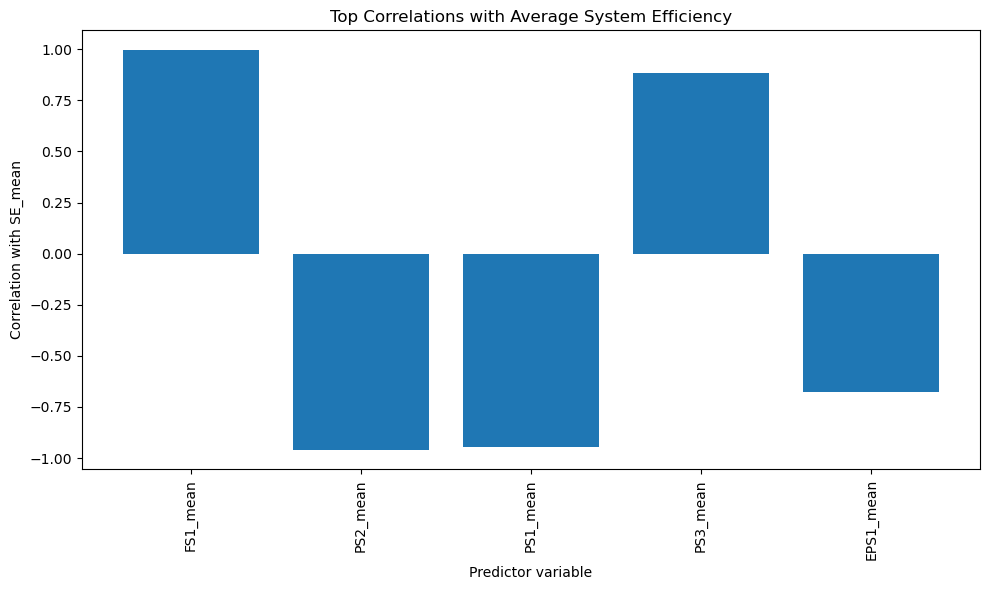

In [73]:
# I chose 5 as the values to pick from the previous correlations table.
# This ensures that the strongest are selected.  
# I could have used a threshold, say +/- 0.7 to choose.  TODO
top_correlations = correlations.head(5)

plt.figure(figsize=(10, 6))
plt.bar(top_correlations.index, top_correlations.values)
plt.title("Top Correlations with Average System Efficiency")
plt.xlabel("Predictor variable")
plt.ylabel("Correlation with SE_mean")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(VISUALIZATION_DIR / "top_correlations_SE_mean.png", bbox_inches="tight")
plt.show()

This bar chart shows the variables with the strongest positive or negative correlation with SE_mean. It is useful because it quickly identifies which sensor-derived features are most likely to be useful predictors in a linear regression model.

The correlation bar chart shows that the strongest relationships with SE_mean are found in FS1_mean, PS2_mean, PS1_mean and PS3_Mean. These variables should be prioritised for scatter plots and considered as candidate predictors for the linear regression model.


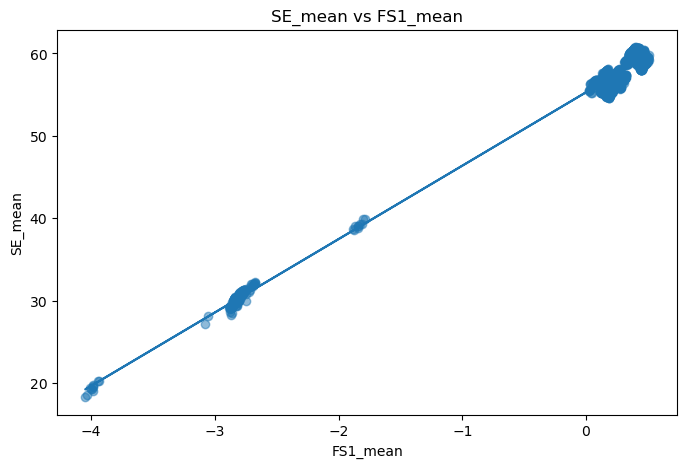

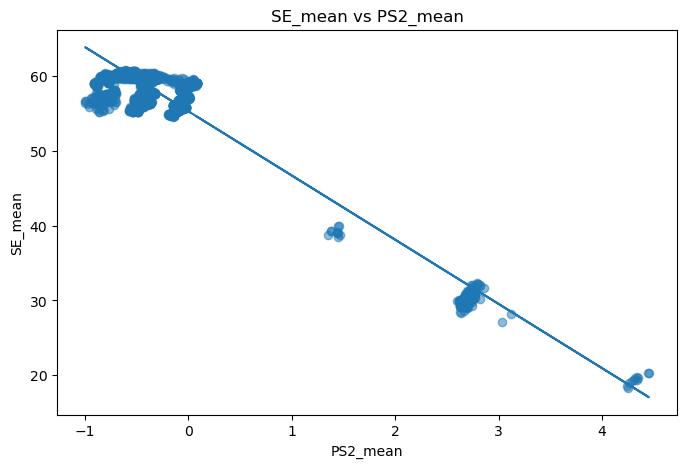

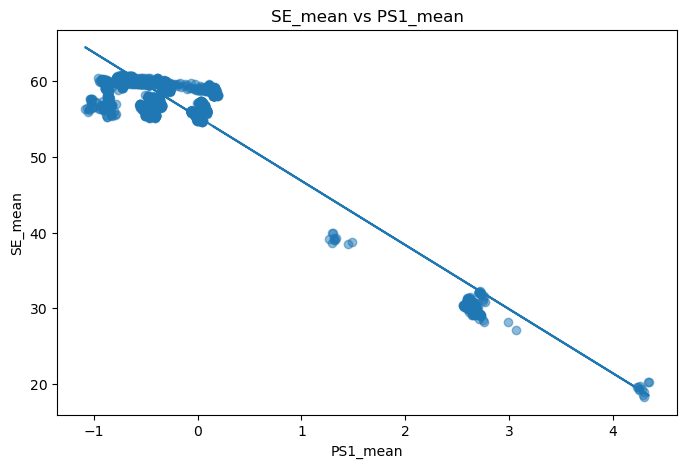

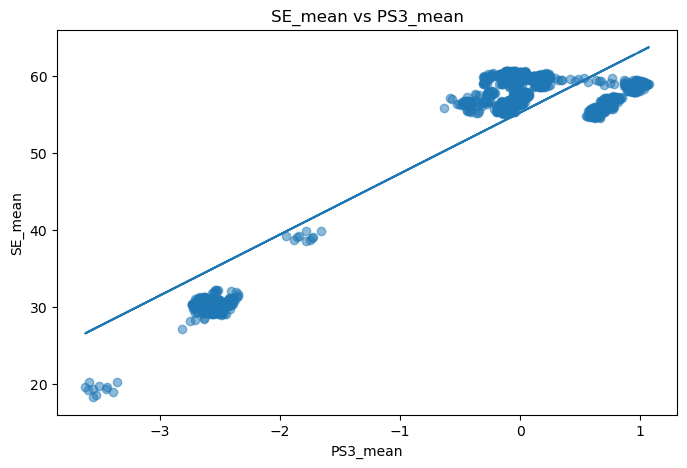

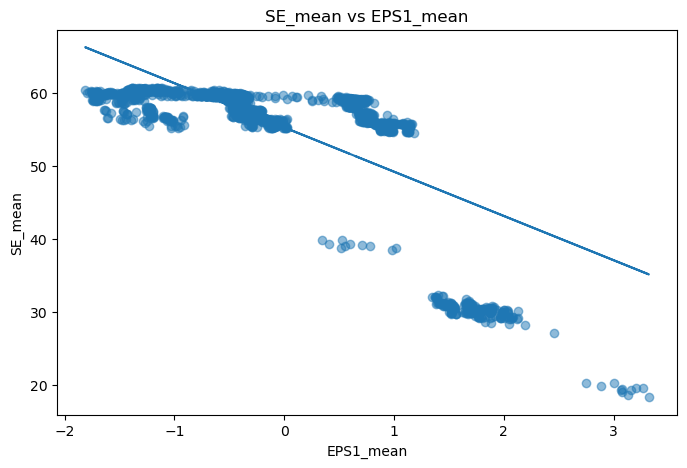

In [74]:
top_predictors = correlations.head(5).index.tolist()

for predictor in top_predictors:
    x = model_normalized[predictor]
    y = model_normalized[target]

    valid = x.notna() & y.notna()
    x_clean = x[valid]
    y_clean = y[valid]

    slope, intercept = np.polyfit(x_clean, y_clean, 1)
    trendline = slope * x_clean + intercept

    plt.figure(figsize=(8, 5))
    plt.scatter(x_clean, y_clean, alpha=0.5)
    plt.plot(x_clean, trendline)
    plt.title(f"{target} vs {predictor}")
    plt.xlabel(predictor)
    plt.ylabel(target)
    plt.savefig(VISUALIZATION_DIR / f"scatter_{target}_vs_{predictor}.png", bbox_inches="tight")
    plt.show()

The scatter plots show the relationship between average system efficiency and the strongest candidate predictor variables. The trendline is included because this coursework uses linear regression. A clear upward or downward pattern suggests that a linear model may be appropriate. A scattered or curved pattern would suggest that the relationship may be weak or non-linear.

The scatter plot between SE_mean and FS1_mean is important because it shows a positive relationship. The trendline suggests that as FS1_mean increases, average system efficiency tends to increase. This relationship would have been difficult to judge from the raw numerical table alone.

The scatter plot between SE_mean and PS2_mean is important because it shows a negative relationship. The trendline suggests that as PS2_mean decreases, average system efficiency tends to decrease. This relationship would have been difficult to judge from the raw numerical table alone.

The scatter plot between SE_mean and P12_mean is important because it shows a negative relationship. The trendline suggests that as PS1_mean decreases, average system efficiency tends to decrease. This relationship would have been difficult to judge from the raw numerical table alone.

The scatter plot between SE_mean and PS3_mean is important because it shows a positive relationship. The trendline suggests that as PS3_mean increases, average system efficiency tends to increase. This relationship would have been difficult to judge from the raw numerical table alone.

The scatter plot between SE_mean and EPS1_mean is important because it shows a negative relationship. There is a 68% correlation between the variables and this can be seen in the plot. The trendline suggests that as EPS1_mean decreases, average system efficiency tends to decrease. This relationship would have been difficult to judge from the raw numerical table alone.

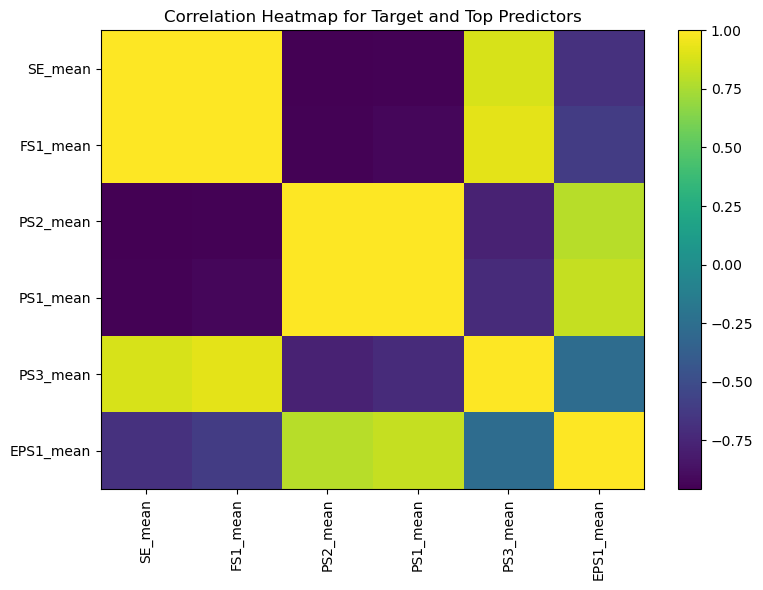

In [75]:
# Create a correlation heatmap
selected_columns = [target] + top_predictors

heatmap_data = model_normalized[selected_columns].corr()

plt.figure(figsize=(8, 6))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar()
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=90)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title("Correlation Heatmap for Target and Top Predictors")
plt.tight_layout()
plt.savefig(VISUALIZATION_DIR / "correlation_heatmap_SE_mean.png", bbox_inches="tight")
plt.show()

The heatmap provides a compact visual summary of the relationships between SE_mean and the strongest predictor variables. It also shows whether predictors are highly correlated with each other. This matters because highly correlated predictors may provide overlapping information in a regression model.

The heatmap shows that FS1_mean, PS2_mean, PS1_mean, PS3_mean, and EPS1_mean all have strong relationships with SE_mean. It also shows that each are strongly correlated with each  (exception being EPS1_mean being the weakest, but still shows a correlation), meaning they may represent related aspects of the hydraulic system.

In [76]:
model_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   PS1_mean   2205 non-null   float64
 1   PS2_mean   2205 non-null   float64
 2   PS3_mean   2205 non-null   float64
 3   PS4_mean   2205 non-null   float64
 4   PS5_mean   2205 non-null   float64
 5   PS6_mean   2205 non-null   float64
 6   EPS1_mean  2205 non-null   float64
 7   FS1_mean   2205 non-null   float64
 8   FS2_mean   2205 non-null   float64
 9   TS1_mean   2205 non-null   float64
 10  TS2_mean   2205 non-null   float64
 11  TS3_mean   2205 non-null   float64
 12  TS4_mean   2205 non-null   float64
 13  VS1_mean   2205 non-null   float64
 14  CE_mean    2205 non-null   float64
 15  CP_mean    2205 non-null   float64
 16  SE_mean    2205 non-null   float64
dtypes: float64(17)
memory usage: 293.0 KB


<Figure size 700x500 with 0 Axes>

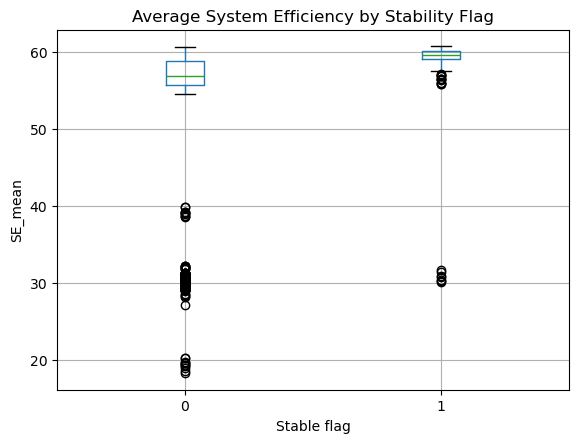

In [77]:
# Visualise efficiency by stable and unstable conditions
# Use the stable_flag column from profile.txt.
# Note the dataset is model_data as that dataset includes the profile columns TODO [LIST THEM]
if "stable_flag" in model_data.columns:
    plt.figure(figsize=(7, 5))
    model_data.boxplot(column=target, by="stable_flag")
    plt.title("Average System Efficiency by Stability Flag")
    plt.suptitle("")
    plt.xlabel("Stable flag")
    plt.ylabel(target)
    plt.savefig(VISUALIZATION_DIR / "boxplot_SE_mean_by_stable_flag.png", bbox_inches="tight")
    plt.show()

This boxplot compares average system efficiency between stable and potentially unstable operating cycles. It helps determine whether unstable cycles should be included in the regression model or filtered out during preprocessing.

The boxplot shows that stable and unstable cycles have different SE_mean values. If unstable cycles show more spread or unusual values, it may be appropriate to train the regression model only on stable cycles.  50% of stable cycle SE_mean are in a very tight range and seem to be (visually), distinct from the 50% shown in the unstable box plot. 

For unstable cycles, the outliers have a much greater range than the stable plot, and also seem to have more outliers as viewed from the plot.

I am thinking at this stage that I will perform some separate regression modelling and see which one (unstable, stable, both) produces better results.


<Figure size 700x500 with 0 Axes>

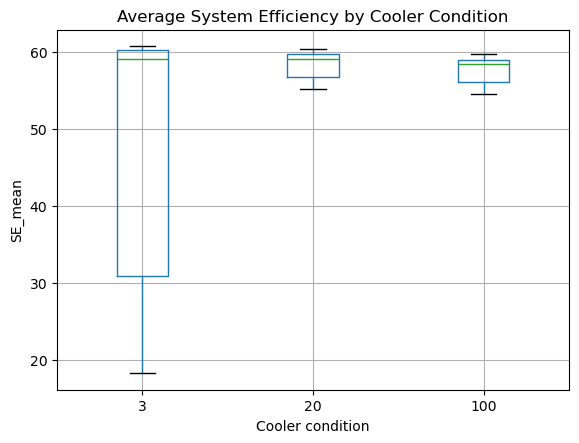

In [78]:
# Visualise efficiency by cooler condition
# This links the regression target back to the machine condition labels.
if "cooler_condition" in model_data.columns:
    plt.figure(figsize=(7, 5))
    model_data.boxplot(column=target, by="cooler_condition")
    plt.title("Average System Efficiency by Cooler Condition")
    plt.suptitle("")
    plt.xlabel("Cooler condition")
    plt.ylabel(target)
    plt.savefig(VISUALIZATION_DIR / "boxplot_SE_mean_by_cooler_condition.png", bbox_inches="tight")
    plt.show()

TODO - understand cooler condition values
This boxplot compares average system efficiency across different cooler condition levels. It helps show whether component condition is associated with changes in system efficiency. This supports the predictive maintenance framing of the project.

This is useful because it connects the sensor-based regression problem to the real engineering context of hydraulic component condition monitoring.  

The boxplot suggests that cooler condition does appear to affect average system efficiency. However, I am not sure how the overlap across the 50% ranges contributes to SE_mean.  It is obvious that if the cooler condition is 20 or 100, then high means seem to be correlated to these values.  The issue is with the '3' cooler condition level.  The SE_mean is correlated at values below the 25% range of series 20, and 100.  At this stage I do not have enough experience understanding these graphs.  




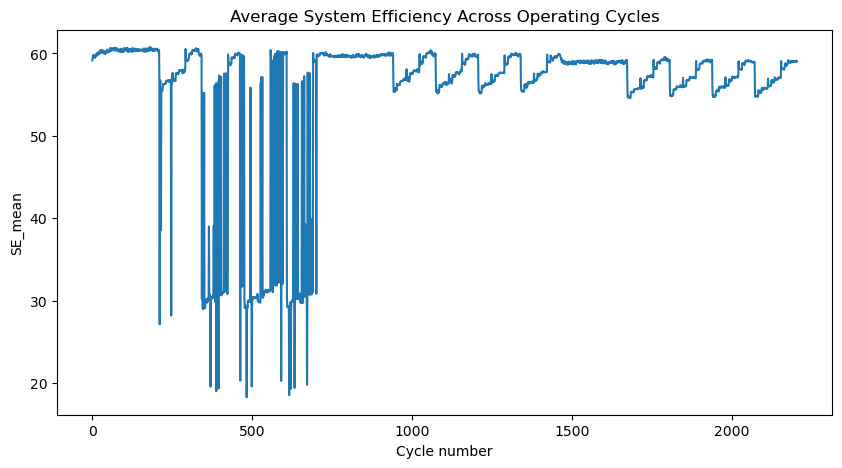

In [79]:
# Visualise efficiency across operating cycles
plt.figure(figsize=(10, 5))
plt.plot(model_data.index, model_data[target])
plt.title("Average System Efficiency Across Operating Cycles")
plt.xlabel("Cycle number")
plt.ylabel(target)
plt.savefig(VISUALIZATION_DIR / "lineplot_SE_mean_across_cycles.png", bbox_inches="tight")
plt.show()

This is a very interesting graph.

This line plot shows how average system efficiency changes across the sequence of operating cycles. It can reveal shifts, clusters, sudden changes or periods of stable behaviour that are not obvious from summary statistics alone.

The line plot shows that SE_mean shifts between operating regions across the cycle sequence. This is useful because it suggests the hydraulic system may have been tested under different condition settings rather than one constant operating state.

The major variance in SE_mean between cycles 250 - 750 may be indicative of a system environment issue or a fault within the system.  This would be very interesting to see for each sensor and perhaps show more insight into a possible fault. Something occurs at around cycle 250 that shifts the system into a volatile state.


In [80]:
# TODO explore how the sensor readings are affected by cycle

The most important visualisation is the scatter plot with a linear trendline between average system efficiency (`SE_mean`) and the strongest correlated predictor variable. This is the most important because the project uses linear regression, so it is necessary to visually check whether a predictor has an approximately linear relationship with the target variable. The scatter plot shows not only the direction of the relationship, but also the strength of the pattern, the presence of outliers, and whether the relationship appears suitable for a linear model. The correlation bar chart helps identify candidate predictors, but the scatter plot is more important because it visually confirms whether the linear regression assumption is reasonable.


The key data series were visualised using histograms, scatter plots, boxplots, a correlation bar chart, a correlation heatmap and a line plot across operating cycles. Histograms were used to inspect the distribution of the target and predictor variables. Scatter plots with trendlines were used to assess whether the strongest predictors had an approximately linear relationship with `SE_mean`, the selected hydraulic efficiency target. Boxplots were used to compare efficiency across stable and unstable cycles and across cooler condition levels. The correlation bar chart and heatmap helped identify which sensor-derived variables were most strongly related to system efficiency.

The visualisations provided insights that would not be clear from the raw data alone. In particular, the scatter plots showed whether linear regression was appropriate, while the boxplots showed whether system condition affected efficiency. The line plot across cycle number helped reveal whether the system moved through different operating states during the experiment. The most important visualisation was the scatter plot with a trendline between `SE_mean` and the strongest predictor variable, because it directly supports the central modelling question: whether hydraulic efficiency can be predicted from sensor data using linear regression.


# Part 6 - Build your ML


## Machine Learning Model Objective

The objective of this model is to predict average hydraulic system efficiency using sensor-derived measurements from the hydraulic test rig. The selected label is `SE_mean`, which represents the average system efficiency factor for each operating cycle. The selected features are cycle-level summaries of pressure, flow, temperature, vibration and motor power sensor readings.

A linear regression model is appropriate because the label is a continuous numerical variable and the project aims to test whether changes in sensor readings have an approximately linear relationship with hydraulic efficiency.

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [82]:
# model_data is the original data combined with profile information.
# model_data is not normalized
model_data.head()

,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median,cooler_condition,valve_condition,pump_leakage,hydraulic_accumulator,stable_flag
0,39.601350,6.370535,28.866,47.438,40.6755,1.862750,0.279385,1.383,2.188,1.9240,2538.929167,185.616121,2339.8,2951.6,2479.8,6.709815,3.015428,0.0,18.710,7.836,10.304592,0.091772,10.148,10.446,10.327,160.673492,13.939309,145.83,191.51,156.25,109.466914,47.114508,0.0,156.99,129.365,1.991475,0.945705,0.0,10.039,2.297,0.0,0.0,0.0,0.0,0.0,9.842170,0.088154,9.681,10.016,9.844,9.728097,0.085366,9.568,9.887,9.733,59.157183,23.763984,0.0,79.568,68.5145,35.621983,0.308230,35.156,36.152,35.5720,40.978767,0.154302,40.773,41.250,40.9630,38.471017,0.084659,38.316,38.613,38.4960,31.745250,1.116478,30.363,33.594,31.576,0.576950,0.027078,0.532,0.624,0.5770,3,100,0,130,1
1,25.786433,1.686129,23.320,29.208,25.3855,1.255550,0.074605,1.147,1.414,1.2340,2531.498900,189.940089,2332.0,2947.4,2470.0,6.715315,3.006248,0.0,18.712,7.853,10.403098,0.019162,10.352,10.453,10.403,160.603320,14.118967,145.73,191.47,156.06,109.354890,47.045611,0.0,157.56,129.385,1.976234,0.941967,0.0,9.992,2.273,0.0,0.0,0.0,0.0,0.0,9.635142,0.038392,9.557,9.745,9.632,9.529488,0.036316,9.454,9.637,9.526,59.335617,23.857918,0.0,80.441,68.5360,36.676967,0.585740,35.648,37.488,36.7675,41.532767,0.338234,41.031,42.105,41.5180,38.978967,0.176921,38.668,39.254,38.9845,34.493867,0.435312,33.648,35.148,34.553,0.565850,0.027241,0.524,0.626,0.5595,3,100,0,130,1
2,22.218233,0.638345,21.220,23.554,22.1040,1.113217,0.023263,1.076,1.159,1.1095,2519.928000,190.736850,2318.6,2939.8,2457.4,6.718522,3.014248,0.0,18.698,7.847,10.366250,0.026361,10.296,10.443,10.367,160.347720,14.192619,145.37,191.41,155.72,109.158845,46.992060,0.0,156.97,129.325,1.972224,0.943501,0.0,10.914,2.273,0.0,0.0,0.0,0.0,0.0,9.530548,0.035817,9.455,9.640,9.528,9.427949,0.036031,9.348,9.536,9.425,59.543150,23.923381,0.0,80.824,68.8530,37.880800,0.559169,36.879,38.621,38.0235,42.442450,0.390588,41.832,43.039,42.4235,39.631950,0.251133,39.234,40.062,39.6270,35.646150,0.293889,35.098,36.141,35.635,0.576533,0.036729,0.529,0.662,0.5620,3,100,0,130,1
3,20.459817,0.455755,19.673,21.565,20.4805,1.062150,0.024621,1.022,1.107,1.0660,2511.541633,191.270607,2310.8,2929.6,2448.0,6.720565,3.020176,0.0,18.896,7.843,10.302678,0.026750,10.241,10.382,10.302,160.188088,14.227803,145.14,191.34,155.56,109.064807,46.972221,0.0,156.44,128.865,1.946575,0.935534,0.0,10.297,2.242,0.0,0.0,0.0,0.0,0.0,9.438827,0.037069,9.363,9.535,9.436,9.337430,0.037375,9.257,9.431,9.335,59.794900,24.023005,0.0,80.930,69.0060,38.879050,0.516176,37.887,39.473,39.0550,43.403983,0.398476,42.805,43.988,43.3650,40.403383,0.285434,40.023,40.934,40.3420,36.579467,0.262397,36.105,36.988,36.635,0.569267,0.033464,0.527,0.645,0.5550,3,100,0,130,1
4,19.787017,0.290156,19.133,20.460,19.7985,1.070467,0.021477,1.016,1.106,1.0725,2503.449500,191.258369,2301.8,2923.8,2440.6,6.690308,3.011550,0.0,18.876,7.831,10.237750,0.029170,10.179,10.312,10.236,160.000472,14.276434,144.95,191.41,155.34,108.931434,46.874946,0.0,158.13,129.000,1.922707,0.930335,0.0,11.102,2.219,0.0,0.0,0.0,0.0,0.0,9.358762,0.029779,9.290,9.443,9.358,9.260636,0.028592,9.195,9.342,9.260,59.455267,23.972262,0.0,81.100,69.0130,39.803917,0.535374,38.789,40.391,39.9670,44.332750,0.372769,43.742,44.887,44.3355,41.31055

In [83]:
# model_normalized contains the features (normalized) and the target SE_mean (not normalized)
model_normalized.head()

,PS1_mean,PS2_mean,PS3_mean,PS4_mean,PS5_mean,PS6_mean,EPS1_mean,FS1_mean,FS2_mean,TS1_mean,TS2_mean,TS3_mean,TS4_mean,VS1_mean,CE_mean,CP_mean,SE_mean
0,0.040043,0.017448,0.945797,-0.60763,1.177952,1.180399,0.588054,0.494989,1.458308,-1.226560,-1.269185,-1.233393,-1.108848,-0.603477,39.601350,1.862750,59.157183
1,0.025111,-0.005017,0.885293,-0.60763,0.818714,0.819021,0.487423,0.500314,1.677580,-1.094554,-1.194282,-1.165229,-0.769842,-0.787679,25.786433,1.255550,59.335617
2,-0.029279,-0.044331,0.869373,-0.60763,0.637220,0.634266,0.330714,0.503419,1.595557,-0.943923,-1.071289,-1.077602,-0.627723,-0.610391,22.218233,1.113217,59.543150
3,-0.063247,-0.063189,0.767553,-0.60763,0.478064,0.469563,0.217134,0.505397,1.454049,-0.819015,-0.941287,-0.974080,-0.512611,-0.730980,20.459817,1.062150,59.794900
4,-0.103171,-0.089936,0.672800,-0.60763,0.339134,0.329834,0.107539,0.476103,1.309522,-0.703290,-0.815714,-0.852344,-0.407968,-0.596562,19.787017,1.070467,59.455267


In [84]:
# identify the label SE_mean.  This label appears identically in both the datasets
label = "SE_mean"

if label not in model_normalized.columns:
    raise ValueError(f"The selected label '{label}' is not available in the dataset.")

The label selected for the regression model is `SE_mean`, the average system efficiency factor for each operating cycle. This was selected because the project objective is to predict hydraulic system efficiency from sensor readings. It is a continuous numerical variable, making it suitable for linear regression.



In [85]:
# Identify the features
# Use physical sensor features only for the baseline model.
sensor_prefixes = [
    "PS1", "PS2", "PS3", "PS4", "PS5", "PS6",
    "EPS1",
    "FS1", "FS2",
    "TS1", "TS2", "TS3", "TS4",
    "VS1"
]

# Use only cycle-level mean features for the first model
feature_columns = []

# using the normalized features from model_normalized
for col in model_normalized.columns:
    for prefix in sensor_prefixes:
        if col == f"{prefix}_mean":
            feature_columns.append(col)

print("Selected features:")
for feature in feature_columns:
    print(feature)

Selected features:
PS1_mean
PS2_mean
PS3_mean
PS4_mean
PS5_mean
PS6_mean
EPS1_mean
FS1_mean
FS2_mean
TS1_mean
TS2_mean
TS3_mean
TS4_mean
VS1_mean


The selected features are cycle-level mean values from the main physical sensors: pressure, motor power, volume flow, temperature and vibration. These were selected because they represent the measurable operating behaviour of the hydraulic system. They are also realistic inputs for a predictive maintenance model, because these values could be collected from sensors during operation.

The pressure sensor features are important because pressure changes can indicate load conditions, valve behaviour or system resistance. Flow features are important because hydraulic efficiency depends on the movement of fluid through the system. Temperature features are relevant because overheating or cooling problems can reduce system performance. Vibration is important because unusual vibration may indicate mechanical instability or component wear. Motor power is important because changes in power demand may reflect changing system load or reduced efficiency.

The `profile.txt` condition columns were not used as baseline predictors because they describe known component condition states. Including them could make the model less realistic for predictive maintenance, where the aim is to infer performance from sensor readings rather than assume that component condition is already known.
 
 TODO: Add more detail here about profile.txt

In [86]:
# Build the regression dataset
# This code keeps only the selected features and label.
# using model_normalized. This data is clean, numeric, and complete.

regression_data = model_normalized[feature_columns + [label]].copy()

print("Regression dataset shape:", regression_data.shape)
regression_data.head()

Regression dataset shape: (2205, 15)


,PS1_mean,PS2_mean,PS3_mean,PS4_mean,PS5_mean,PS6_mean,EPS1_mean,FS1_mean,FS2_mean,TS1_mean,TS2_mean,TS3_mean,TS4_mean,VS1_mean,SE_mean
0,0.040043,0.017448,0.945797,-0.60763,1.177952,1.180399,0.588054,0.494989,1.458308,-1.226560,-1.269185,-1.233393,-1.108848,-0.603477,59.157183
1,0.025111,-0.005017,0.885293,-0.60763,0.818714,0.819021,0.487423,0.500314,1.677580,-1.094554,-1.194282,-1.165229,-0.769842,-0.787679,59.335617
2,-0.029279,-0.044331,0.869373,-0.60763,0.637220,0.634266,0.330714,0.503419,1.595557,-0.943923,-1.071289,-1.077602,-0.627723,-0.610391,59.543150
3,-0.063247,-0.063189,0.767553,-0.60763,0.478064,0.469563,0.217134,0.505397,1.454049,-0.819015,-0.941287,-0.974080,-0.512611,-0.730980,59.794900
4,-0.103171,-0.089936,0.672800,-0.60763,0.339134,0.329834,0.107539,0.476103,1.309522,-0.703290,-0.815714,-0.852344,-0.407968,-0.596562,59.455267


In [87]:
# TODO cleanup

def filter_normalized_by_stable_flag(
    model_data: pd.DataFrame,
    model_normalized: pd.DataFrame,
    stable_value=0,
    stable_col="stable_flag",
    reset_index=True,
    keep_stable_flag=False
) -> pd.DataFrame:
    """
    Filters model_normalized using the stable_flag column from model_data.

    Parameters
    ----------
    model_data : pd.DataFrame
        The full processed dataset that includes the stable_flag column.

    model_normalized : pd.DataFrame
        The normalized dataset used for regression feature selection.

    stable_value : int or float, default=0
        The stable_flag value to keep.
        In the UCI hydraulic systems dataset:
            0 = stable conditions
            1 = static conditions might not have been reached

    stable_col : str, default="stable_flag"
        The name of the stability column in model_data.

    reset_index : bool, default=True
        If True, resets the index of the filtered dataset.

    keep_stable_flag : bool, default=False
        If True, adds the stable_flag column to the returned normalized dataset.
        This is useful for checking, but it should usually not be used as a regression feature.

    Returns
    -------
    pd.DataFrame
        Filtered version of model_normalized containing only rows where
        model_data[stable_col] == stable_value.
    """

    # Check that stable_flag exists
    if stable_col not in model_data.columns:
        raise KeyError(f"'{stable_col}' was not found in model_data.")

    # Check that both datasets have the same number of rows
    if len(model_data) != len(model_normalized):
        raise ValueError(
            f"Row count mismatch: model_data has {len(model_data)} rows, "
            f"but model_normalized has {len(model_normalized)} rows. "
            "The datasets must represent the same cycles in the same order."
        )

    # Create Boolean mask from model_data
    stable_mask = model_data[stable_col] == stable_value

    # Apply the mask to model_normalized
    filtered_normalized = model_normalized.loc[stable_mask].copy()

    # Optionally add stable_flag for verification
    if keep_stable_flag:
        filtered_normalized[stable_col] = model_data.loc[stable_mask, stable_col].values

    # Optionally reset index
    if reset_index:
        filtered_normalized = filtered_normalized.reset_index(drop=True)

    return filtered_normalized

In [88]:
# decide how the model_normalized can be filtered by the stable_flag that exists in ***model_data****
# This allows me to test by all data, stable_flag = 0, or stable_flag = 1
# TODO define stable flag.  What does a 0 mean?

model_normalized_stable = filter_normalized_by_stable_flag(
    model_data=model_data,
    model_normalized=regression_data,
    stable_value=1
)

print("Original normalized shape:", regression_data.shape)
print("Stable normalized shape:", model_normalized_stable.shape)

Original normalized shape: (2205, 15)
Stable normalized shape: (756, 15)


In [89]:
model_normalized_stable_check = filter_normalized_by_stable_flag(
    model_data=model_data,
    model_normalized=regression_data,
    stable_value=1,
    keep_stable_flag=True
)

model_normalized_stable_check["stable_flag"].value_counts()

stable_flag
1    756
Name: count, dtype: int64

We now how three model datasets for regression.

model_normalized : All data
regression_data : Normalized data, features and label

Filtered Model:
model_normalized_stable : filtered data by stable_flag (0 or 1)

In [90]:
# Split the data into training and test sets
# working on the unfiltered (by stable flag) regression_data
X = regression_data[feature_columns]
y = regression_data[label]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 1764
Test rows: 441


The dataset is split into training and test data. The training data is used to fit the model, while the test data is held back and used to evaluate whether the model generalises to unseen data. An 80/20 split is used, meaning 80% of the data is used for training and 20% is used for testing.

In [91]:
# Build the linear regression model
# Use a Scikit-learn pipeline so that scaling is applied correctly.
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


The model is built using Scikit-learn. A pipeline is used to standardise the predictor variables before fitting the linear regression model. Standardisation is useful because the selected features have different units, such as pressure in bar, flow in litres per minute, temperature in degrees Celsius, vibration in mm/s and motor power in watts. Scaling is fitted only on the training data to avoid data leakage.

In [92]:
# Run predictions
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

After the model is trained, it is used to generate predictions for both the training set and the test set. Comparing training and test performance helps identify whether the model fits the data well or whether it is overfitting or underfitting.

In [93]:
# Evaluate the model
def evaluate_regression(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "dataset": dataset_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

results = pd.DataFrame([
    evaluate_regression(y_train, y_train_pred, "Training"),
    evaluate_regression(y_test, y_test_pred, "Test")
])

results

,dataset,MAE,MSE,RMSE,R2
0,Training,0.093020,0.015949,0.126290,0.999803
1,Test,0.093165,0.016613,0.128892,0.999787


In [94]:
results.to_csv(DATAFRAME_DIR / "linear_regression_model_results.csv", index=False)

The model is evaluated using MAE, MSE, RMSE and R². MAE shows the average absolute prediction error. RMSE gives more weight to larger errors. R² shows how much variation in the target variable is explained by the model. Training and test results are compared to determine whether the model generalises well.

In [95]:
# Inspect feature importance using coefficients
# Because the features are scaled in the pipeline, the coefficients can be compared more fairly.
regressor = linear_model.named_steps["regressor"]

coefficient_table = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": regressor.coef_
})

coefficient_table["absolute_coefficient"] = coefficient_table["coefficient"].abs()

coefficient_table = coefficient_table.sort_values(
    "absolute_coefficient",
    ascending=False
)

coefficient_table

,feature,coefficient,absolute_coefficient
4,PS5_mean,10.513207,10.513207
5,PS6_mean,-9.848413,9.848413
7,FS1_mean,9.692809,9.692809
1,PS2_mean,4.441883,4.441883
9,TS1_mean,3.004729,3.004729
0,PS1_mean,-2.510470,2.510470
6,EPS1_mean,-1.749296,1.749296
12,TS4_mean,-1.465185,1.465185
8,FS2_mean,0.774976,0.774976
11,TS3_mean,-0.419402,0.419402


In [96]:
coefficient_table.to_csv(DATAFRAME_DIR / "linear_regression_coefficients.csv", index=False)

The coefficient table shows the relative influence of each feature in the linear regression model. A positive coefficient means that, as the feature increases, the predicted system efficiency tends to increase. A negative coefficient means that, as the feature increases, predicted system efficiency tends to decrease. The absolute coefficient value helps identify which features have the strongest influence on the prediction.

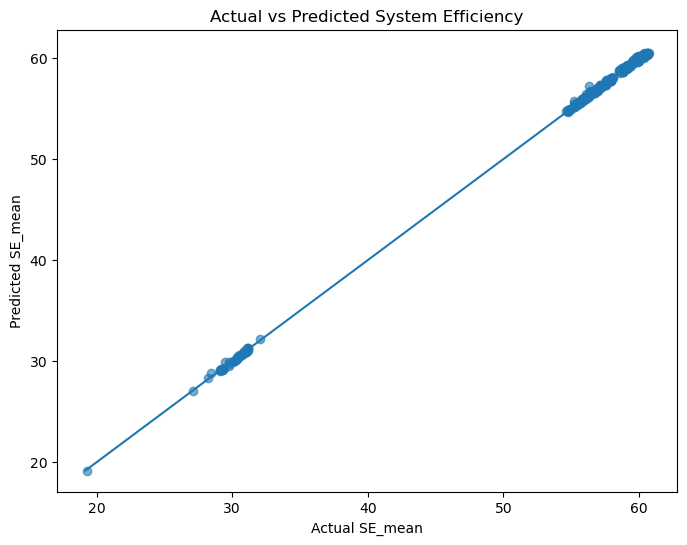

In [97]:
# Visualise predicted versus actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot([min_value, max_value], [min_value, max_value])
plt.title("Actual vs Predicted System Efficiency")
plt.xlabel("Actual SE_mean")
plt.ylabel("Predicted SE_mean")
plt.savefig(VISUALIZATION_DIR / "actual_vs_predicted_SE_mean.png", bbox_inches="tight")
plt.show()

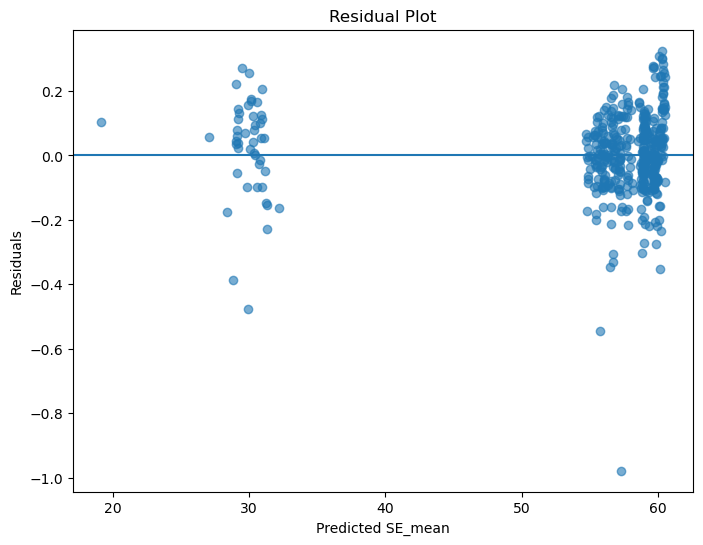

In [98]:
# Visualise residuals
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted SE_mean")
plt.ylabel("Residuals")
plt.savefig(VISUALIZATION_DIR / "residual_plot_SE_mean.png", bbox_inches="tight")
plt.show()

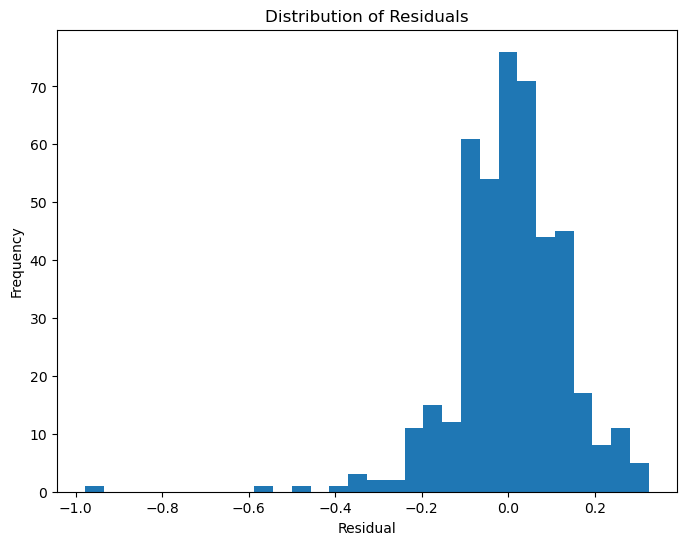

In [99]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.savefig(VISUALIZATION_DIR / "residual_histogram_SE_mean.png", bbox_inches="tight")
plt.show()

Residuals are the differences between actual and predicted values. A good linear regression model should have residuals that are reasonably centred around zero. If the residual plot shows a clear curve or pattern, this suggests that the relationship may not be fully linear. If the residual histogram is highly skewed, further preprocessing or a different model may be required.

In [100]:
# Automatically interpret the model fit?
train_r2 = results.loc[results["dataset"] == "Training", "R2"].values[0]
test_r2 = results.loc[results["dataset"] == "Test", "R2"].values[0]

r2_gap = train_r2 - test_r2

print("Training R2:", round(train_r2, 4))
print("Test R2:", round(test_r2, 4))
print("R2 gap:", round(r2_gap, 4))

if test_r2 >= 0.70 and abs(r2_gap) <= 0.10:
    print("The model appears to fit the data reasonably well.")
elif train_r2 >= 0.70 and test_r2 < 0.50:
    print("The model may be overfitting. Further preprocessing or feature selection may be required.")
elif train_r2 < 0.50 and test_r2 < 0.50:
    print("The model may be underfitting. The linear relationship may be weak or additional features may be required.")
else:
    print("The model has moderate performance. Further inspection of residuals and feature relationships is recommended.")

Training R2: 0.9998
Test R2: 0.9998
R2 gap: 0.0
The model appears to fit the data reasonably well.


The training and test R² values are compared to assess model fit. If both values are reasonably high and close together, the model is likely fitting the data well. If training performance is much higher than test performance, the model may be overfitting. If both values are low, the model may be underfitting or the relationship may not be sufficiently linear.

The label selected for the regression model was `SE_mean`, representing the average system efficiency factor for each hydraulic operating cycle. The features selected were cycle-level mean values from the pressure, flow, temperature, vibration and motor power sensors. These features were chosen because they represent the physical behaviour of the hydraulic system and are relevant to predictive maintenance.

A linear regression model was built using Scikit-learn. The data was split into training and test sets using an 80/20 split. The predictor variables were standardised using `StandardScaler` because they have different physical units. The model was then trained on the training data and evaluated on the test data using MAE, MSE, RMSE and R².

The model achieved a training R² of [insert value] and a test R² of [insert value]. The RMSE on the test set was [insert value]. These results suggest that the model [fits the data well / has moderate performance / requires further preprocessing]. The coefficient table showed that the most influential features were [insert top features]. The residual plot showed [insert whether residuals were random or patterned]. If the residuals show a clear pattern or if the test R² is low, further preprocessing may be required, such as adding additional summary features, removing unstable cycles, transforming skewed variables or testing whether the relationship is non-linear.

1. Feature list
2. Label selected
3. Justification for feature and label selection
4. Model code using Scikit-learn
5. Evaluation metrics table
6. Coefficient table
7. Actual versus predicted plot
8. Residual plot
9. Written conclusion on whether the model fits the data

# 7. Validation

What some model evaluation was performed in Step 6 '''The model is evaluated using MAE, MSE, RMSE and R². MAE shows the average absolute prediction error. RMSE gives more weight to larger errors. R² shows how much variation in the target variable is explained by the model. Training and test results are compared to determine whether the model generalises well.''' I am adding some more validation in this section and will introduce ```k-fold Cross Validation```.

The model was validated using k-fold cross validation. This was used because a single train/test split can give results that depend on how the data was randomly divided. Cross validation provides a stronger validation method by training and testing the model several times on different subsets of the data.

The main model being validated is the linear regression model used in Section 6. The validation results are reported using R², MAE and RMSE. R² measures how much variation in the target variable is explained by the model, while MAE and RMSE measure prediction error.

## Reminder We now how three possible model datasets for regression.

model_normalized : All data
regression_data : Normalized data, features and label

Filtered Model:
model_normalized_stable : filtered data by stable_flag (0 or 1)

In [101]:
# Prepare the normalized dataset
# working with regression_data - The unfiltered full data set

working_model = regression_data   # or model_normalized_stable (filtered appropriately above)

label = "SE_mean"

feature_columns = [
    "PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean",
    "EPS1_mean",
    "FS1_mean", "FS2_mean",
    "TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean",
    "VS1_mean"
]

validation_data = working_model[feature_columns + [label]].copy()
validation_data = validation_data.dropna()

X = validation_data[feature_columns]
y = validation_data[label]

print("Validation dataset shape:", validation_data.shape)

Validation dataset shape: (2205, 15)


In [102]:
# Run 5-fold cross validation
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

linear_regression_model = LinearRegression()

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

cv_results = cross_validate(
    linear_regression_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,fit_time,score_time,test_r2,train_r2,test_mae,train_mae,test_rmse,train_rmse
0,0.002049,0.003169,0.999787,0.999803,-0.093165,-0.093020,-0.128892,-0.126290
1,0.001997,0.001998,0.999792,0.999802,-0.096100,-0.093077,-0.131262,-0.125597
2,0.000999,0.002757,0.999832,0.999791,-0.094391,-0.093425,-0.123278,-0.127436
3,0.001998,0.003000,0.999742,0.999812,-0.094241,-0.093199,-0.136581,-0.124272
4,0.001335,0.002002,0.999803,0.999798,-0.094815,-0.093742,-0.122936,-0.127869


In [103]:
# Convert the results into a cleaner table
# Scikit-learn returns MAE and RMSE as negative values, so convert them back to positive error values.
validation_summary = pd.DataFrame({
    "Fold": range(1, 6),
    "Train R2": cv_results_df["train_r2"],
    "Test R2": cv_results_df["test_r2"],
    "Test MAE": -cv_results_df["test_mae"],
    "Test RMSE": -cv_results_df["test_rmse"]
})

validation_summary

,Fold,Train R2,Test R2,Test MAE,Test RMSE
0,1,0.999803,0.999787,0.093165,0.128892
1,2,0.999802,0.999792,0.096100,0.131262
2,3,0.999791,0.999832,0.094391,0.123278
3,4,0.999812,0.999742,0.094241,0.136581
4,5,0.999798,0.999803,0.094815,0.122936


In [104]:
validation_summary.to_csv(DATAFRAME_DIR / "cross_validation_results.csv", index=False)

In [105]:
# Create the mean validation results
validation_means = pd.DataFrame({
    "Metric": ["Train R2", "Test R2", "Test MAE", "Test RMSE"],
    "Mean": [
        validation_summary["Train R2"].mean(),
        validation_summary["Test R2"].mean(),
        validation_summary["Test MAE"].mean(),
        validation_summary["Test RMSE"].mean()
    ],
    "Standard Deviation": [
        validation_summary["Train R2"].std(),
        validation_summary["Test R2"].std(),
        validation_summary["Test MAE"].std(),
        validation_summary["Test RMSE"].std()
    ]
})

validation_means

,Metric,Mean,Standard Deviation
0,Train R2,0.999801,0.000008
1,Test R2,0.999791,0.000033
2,Test MAE,0.094542,0.001062
3,Test RMSE,0.128590,0.005728


In [106]:
validation_means.to_csv(DATAFRAME_DIR / "cross_validation_summary.csv", index=False)

In [107]:
# Optional model comparison
# This strengthens Q7 because the brief says validation can use cross validation or other models/ensembles.
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01, max_iter=10000),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

model_comparison_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    model_comparison_results.append({
        "Model": model_name,
        "Mean Test R2": scores["test_r2"].mean(),
        "Std Test R2": scores["test_r2"].std(),
        "Mean Test MAE": -scores["test_mae"].mean(),
        "Mean Test RMSE": -scores["test_rmse"].mean()
    })

model_comparison_df = pd.DataFrame(model_comparison_results)
model_comparison_df = model_comparison_df.sort_values(
    "Mean Test R2",
    ascending=False
)

model_comparison_df

,Model,Mean Test R2,Std Test R2,Mean Test MAE,Mean Test RMSE
0,Linear Regression,0.999791,0.000029,0.094542,0.128590
3,Random Forest,0.999767,0.000099,0.074168,0.133435
1,Ridge Regression,0.999661,0.000056,0.122112,0.163779
2,Lasso Regression,0.999244,0.000179,0.179782,0.243533


In [108]:
model_comparison_df.to_csv(DATAFRAME_DIR / "cross_validation_model_comparison.csv", index=False)

The model was validated using 5-fold cross validation. This means the dataset was divided into five parts, and the model was trained and tested five times using a different test fold each time. This provides a stronger validation method than relying only on one train/test split.

The cross validation results showed a mean test R² of [insert value], with a standard deviation of [insert value]. The mean test RMSE was [insert value] and the mean test MAE was [insert value]. These results suggest that the model [is stable / has variable performance] across different folds.

The cross validation results were compared with the original train/test split from Section 6. The results were [similar / different], which suggests that the model [generalises reasonably well / may be sensitive to how the data is split]. If the test R² varies significantly between folds, this indicates that further preprocessing or feature engineering may be required.

Additional models were also tested as validation benchmarks. Ridge Regression and Lasso Regression were used because they are linear models with regularisation, while Random Forest was used as a non-linear ensemble benchmark. The purpose of these models was not to replace the required linear regression model, but to check whether the linear model was a reasonable choice for the data.

## 8. Feature Engineering

Feature engineering was used to test whether the regression model could be improved by adding derived features. The original model used only the cycle-level mean sensor values. However, hydraulic system behaviour may not be fully explained by simple linear relationships. For example, efficiency may depend on interactions between pressure, flow, temperature, vibration and motor power.

To test this, polynomial features are created. Polynomial features allow the model to include squared terms and interaction terms, such as pressure × flow or motor power × temperature. The engineered model was then evaluated using cross validation and compared with the original baseline linear regression model.

In [109]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

working_model = regression_data 

label = "SE_mean"

feature_columns = [
    "PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean",
    "EPS1_mean",
    "FS1_mean", "FS2_mean",
    "TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean",
    "VS1_mean"
]

feature_engineering_data = working_model[feature_columns + [label]].copy()
feature_engineering_data = feature_engineering_data.dropna()

X = feature_engineering_data[feature_columns]
y = feature_engineering_data[label]

print("Feature engineering dataset shape:", feature_engineering_data.shape)

Feature engineering dataset shape: (2205, 15)


In [110]:
feature_engineering_data.head()


,PS1_mean,PS2_mean,PS3_mean,PS4_mean,PS5_mean,PS6_mean,EPS1_mean,FS1_mean,FS2_mean,TS1_mean,TS2_mean,TS3_mean,TS4_mean,VS1_mean,SE_mean
0,0.040043,0.017448,0.945797,-0.60763,1.177952,1.180399,0.588054,0.494989,1.458308,-1.226560,-1.269185,-1.233393,-1.108848,-0.603477,59.157183
1,0.025111,-0.005017,0.885293,-0.60763,0.818714,0.819021,0.487423,0.500314,1.677580,-1.094554,-1.194282,-1.165229,-0.769842,-0.787679,59.335617
2,-0.029279,-0.044331,0.869373,-0.60763,0.637220,0.634266,0.330714,0.503419,1.595557,-0.943923,-1.071289,-1.077602,-0.627723,-0.610391,59.543150
3,-0.063247,-0.063189,0.767553,-0.60763,0.478064,0.469563,0.217134,0.505397,1.454049,-0.819015,-0.941287,-0.974080,-0.512611,-0.730980,59.794900
4,-0.103171,-0.089936,0.672800,-0.60763,0.339134,0.329834,0.107539,0.476103,1.309522,-0.703290,-0.815714,-0.852344,-0.407968,-0.596562,59.455267


In [111]:
# Create baseline and feature-engineered models?
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

baseline_model = LinearRegression()

polynomial_linear_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("regressor", LinearRegression())
])

polynomial_ridge_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", Ridge(alpha=1.0))
])


Ridge Regression was included because polynomial features can create many additional predictors. This can increase the risk of overfitting. Ridge Regression is still a linear regression model, but it uses regularisation to reduce overly large coefficients.

In [112]:
# Evaluate all models with cross validation
models = {
    "Baseline Linear Regression": baseline_model,
    "Polynomial Linear Regression": polynomial_linear_model,
    "Polynomial Ridge Regression": polynomial_ridge_model
}

feature_engineering_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )
    
    feature_engineering_results.append({
        "Model": model_name,
        "Mean Train R2": scores["train_r2"].mean(),
        "Mean Test R2": scores["test_r2"].mean(),
        "Std Test R2": scores["test_r2"].std(),
        "Mean Test MAE": -scores["test_mae"].mean(),
        "Mean Test RMSE": -scores["test_rmse"].mean()
    })

feature_engineering_results_df = pd.DataFrame(feature_engineering_results)

feature_engineering_results_df = feature_engineering_results_df.sort_values(
    "Mean Test R2",
    ascending=False
)

feature_engineering_results_df

,Model,Mean Train R2,Mean Test R2,Std Test R2,Mean Test MAE,Mean Test RMSE
1,Polynomial Linear Regression,0.999943,0.999898,0.000034,0.055944,0.089009
0,Baseline Linear Regression,0.999801,0.999791,0.000029,0.094542,0.128590
2,Polynomial Ridge Regression,0.999757,0.999737,0.000024,0.113768,0.144722


In [113]:
feature_engineering_results_df.to_csv(DATAFRAME_DIR / "feature_engineering_model_comparison.csv", index=False)

In [114]:
# Check how many polynomial features were created
# This helps you explain the complexity added by feature engineering.
poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(X)

polynomial_feature_names = poly.get_feature_names_out(feature_columns)

print("Original number of features:", len(feature_columns))
print("Number of polynomial features:", len(polynomial_feature_names))

polynomial_feature_names[:20]

Original number of features: 14
Number of polynomial features: 119


array(['PS1_mean', 'PS2_mean', 'PS3_mean', 'PS4_mean', 'PS5_mean',
       'PS6_mean', 'EPS1_mean', 'FS1_mean', 'FS2_mean', 'TS1_mean',
       'TS2_mean', 'TS3_mean', 'TS4_mean', 'VS1_mean', 'PS1_mean^2',
       'PS1_mean PS2_mean', 'PS1_mean PS3_mean', 'PS1_mean PS4_mean',
       'PS1_mean PS5_mean', 'PS1_mean PS6_mean'], dtype=object)

In [115]:
polynomial_features_df = pd.DataFrame({"polynomial_feature": polynomial_feature_names})

polynomial_features_df.to_csv(DATAFRAME_DIR / "polynomial_feature_names.csv", index=False)

In [116]:
# Create a simple improvement table
baseline_row = feature_engineering_results_df[
    feature_engineering_results_df["Model"] == "Baseline Linear Regression"
].iloc[0]

comparison_df = feature_engineering_results_df.copy()

comparison_df["R2 Improvement vs Baseline"] = (
    comparison_df["Mean Test R2"] - baseline_row["Mean Test R2"]
)

comparison_df["RMSE Improvement vs Baseline"] = (
    baseline_row["Mean Test RMSE"] - comparison_df["Mean Test RMSE"]
)

comparison_df

,Model,Mean Train R2,Mean Test R2,Std Test R2,Mean Test MAE,Mean Test RMSE,R2 Improvement vs Baseline,RMSE Improvement vs Baseline
1,Polynomial Linear Regression,0.999943,0.999898,0.000034,0.055944,0.089009,0.000107,0.039581
0,Baseline Linear Regression,0.999801,0.999791,0.000029,0.094542,0.128590,0.000000,0.000000
2,Polynomial Ridge Regression,0.999757,0.999737,0.000024,0.113768,0.144722,-0.000054,-0.016132


In [117]:
comparison_df.to_csv(DATAFRAME_DIR / "feature_engineering_improvement_summary.csv",index=False)

### Part 8B - BONUS - Domain-Specific Feature Engineering

In addition to polynomial features, domain-specific hydraulic features were created. These features are based on the physical behaviour of the system rather than purely mathematical transformations. The aim is to test whether engineered features such as pressure range, flow balance, temperature average and power-to-flow ratio improve the prediction of average system efficiency (`SE_mean`).

These features are relevant because hydraulic efficiency may depend on pressure differences, fluid movement, heat build-up, vibration and energy demand.

In [118]:
# Using the original not normalized dataset of the 5 summary stats
regression_data.head()


,PS1_mean,PS2_mean,PS3_mean,PS4_mean,PS5_mean,PS6_mean,EPS1_mean,FS1_mean,FS2_mean,TS1_mean,TS2_mean,TS3_mean,TS4_mean,VS1_mean,SE_mean
0,0.040043,0.017448,0.945797,-0.60763,1.177952,1.180399,0.588054,0.494989,1.458308,-1.226560,-1.269185,-1.233393,-1.108848,-0.603477,59.157183
1,0.025111,-0.005017,0.885293,-0.60763,0.818714,0.819021,0.487423,0.500314,1.677580,-1.094554,-1.194282,-1.165229,-0.769842,-0.787679,59.335617
2,-0.029279,-0.044331,0.869373,-0.60763,0.637220,0.634266,0.330714,0.503419,1.595557,-0.943923,-1.071289,-1.077602,-0.627723,-0.610391,59.543150
3,-0.063247,-0.063189,0.767553,-0.60763,0.478064,0.469563,0.217134,0.505397,1.454049,-0.819015,-0.941287,-0.974080,-0.512611,-0.730980,59.794900
4,-0.103171,-0.089936,0.672800,-0.60763,0.339134,0.329834,0.107539,0.476103,1.309522,-0.703290,-0.815714,-0.852344,-0.407968,-0.596562,59.455267


In [119]:
# Keep only stable cycles from model_data - regression_data
# Important: create engineered features from raw/un-normalised data, 
# because ratios like power-to-flow are more meaningful before normalisation.

if "stable_flag" in regression_data.columns:
    model_data_stable = regression_data[regression_data["stable_flag"] == 0].copy()
else:
    model_data_stable = regression_data.copy()

print("Stable model_data shape:", model_data_stable.shape)

Stable model_data shape: (2205, 15)


In [120]:
model_data_stable.head()

,PS1_mean,PS2_mean,PS3_mean,PS4_mean,PS5_mean,PS6_mean,EPS1_mean,FS1_mean,FS2_mean,TS1_mean,TS2_mean,TS3_mean,TS4_mean,VS1_mean,SE_mean
0,0.040043,0.017448,0.945797,-0.60763,1.177952,1.180399,0.588054,0.494989,1.458308,-1.226560,-1.269185,-1.233393,-1.108848,-0.603477,59.157183
1,0.025111,-0.005017,0.885293,-0.60763,0.818714,0.819021,0.487423,0.500314,1.677580,-1.094554,-1.194282,-1.165229,-0.769842,-0.787679,59.335617
2,-0.029279,-0.044331,0.869373,-0.60763,0.637220,0.634266,0.330714,0.503419,1.595557,-0.943923,-1.071289,-1.077602,-0.627723,-0.610391,59.543150
3,-0.063247,-0.063189,0.767553,-0.60763,0.478064,0.469563,0.217134,0.505397,1.454049,-0.819015,-0.941287,-0.974080,-0.512611,-0.730980,59.794900
4,-0.103171,-0.089936,0.672800,-0.60763,0.339134,0.329834,0.107539,0.476103,1.309522,-0.703290,-0.815714,-0.852344,-0.407968,-0.596562,59.455267


In [121]:
# Define the base sensor features
label = "SE_mean"

base_features = [
    "PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean",
    "EPS1_mean",
    "FS1_mean", "FS2_mean",
    "TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean",
    "VS1_mean"
]

available_base_features = [
    col for col in base_features if col in model_data_stable.columns
]

print("Available base features:")
print(available_base_features)

Available base features:
['PS1_mean', 'PS2_mean', 'PS3_mean', 'PS4_mean', 'PS5_mean', 'PS6_mean', 'EPS1_mean', 'FS1_mean', 'FS2_mean', 'TS1_mean', 'TS2_mean', 'TS3_mean', 'TS4_mean', 'VS1_mean']


In [122]:
# Create domain-specific engineered features
engineering_data = model_data_stable[available_base_features + [label]].copy()

# Pressure features
pressure_cols = [col for col in ["PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean"] if col in engineering_data.columns]

if pressure_cols:
    engineering_data["pressure_average"] = engineering_data[pressure_cols].mean(axis=1)
    engineering_data["pressure_range"] = engineering_data[pressure_cols].max(axis=1) - engineering_data[pressure_cols].min(axis=1)

if "PS1_mean" in engineering_data.columns and "PS6_mean" in engineering_data.columns:
    engineering_data["pressure_drop_PS1_PS6"] = engineering_data["PS1_mean"] - engineering_data["PS6_mean"]

# Flow features
if "FS1_mean" in engineering_data.columns and "FS2_mean" in engineering_data.columns:
    engineering_data["flow_balance"] = engineering_data["FS1_mean"] - engineering_data["FS2_mean"]
    engineering_data["flow_average"] = engineering_data[["FS1_mean", "FS2_mean"]].mean(axis=1)

# Temperature features
temperature_cols = [col for col in ["TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean"] if col in engineering_data.columns]

if temperature_cols:
    engineering_data["temperature_average"] = engineering_data[temperature_cols].mean(axis=1)
    engineering_data["temperature_range"] = engineering_data[temperature_cols].max(axis=1) - engineering_data[temperature_cols].min(axis=1)

# Power-to-flow feature
if "EPS1_mean" in engineering_data.columns and "FS1_mean" in engineering_data.columns:
    engineering_data["power_to_flow_ratio"] = engineering_data["EPS1_mean"] / engineering_data["FS1_mean"].replace(0, np.nan)

# Vibration and power interaction
if "VS1_mean" in engineering_data.columns and "EPS1_mean" in engineering_data.columns:
    engineering_data["vibration_power_interaction"] = engineering_data["VS1_mean"] * engineering_data["EPS1_mean"]

engineering_data = engineering_data.replace([np.inf, -np.inf], np.nan)
engineering_data = engineering_data.dropna()

print("Engineering data shape:", engineering_data.shape)
engineering_data.head()

Engineering data shape: (2205, 24)


,PS1_mean,PS2_mean,PS3_mean,PS4_mean,PS5_mean,PS6_mean,EPS1_mean,FS1_mean,FS2_mean,TS1_mean,TS2_mean,TS3_mean,TS4_mean,VS1_mean,SE_mean,pressure_average,pressure_range,pressure_drop_PS1_PS6,flow_balance,flow_average,temperature_average,temperature_range,power_to_flow_ratio,vibration_power_interaction
0,0.040043,0.017448,0.945797,-0.60763,1.177952,1.180399,0.588054,0.494989,1.458308,-1.226560,-1.269185,-1.233393,-1.108848,-0.603477,59.157183,0.459001,1.788029,-1.140357,-0.963319,0.976649,-1.209496,0.160337,1.188014,-0.354877
1,0.025111,-0.005017,0.885293,-0.60763,0.818714,0.819021,0.487423,0.500314,1.677580,-1.094554,-1.194282,-1.165229,-0.769842,-0.787679,59.335617,0.322582,1.492923,-0.793910,-1.177266,1.088947,-1.055977,0.424439,0.974234,-0.383933
2,-0.029279,-0.044331,0.869373,-0.60763,0.637220,0.634266,0.330714,0.503419,1.595557,-0.943923,-1.071289,-1.077602,-0.627723,-0.610391,59.543150,0.243270,1.477003,-0.663546,-1.092138,1.049488,-0.930134,0.449879,0.656936,-0.201865
3,-0.063247,-0.063189,0.767553,-0.60763,0.478064,0.469563,0.217134,0.505397,1.454049,-0.819015,-0.941287,-0.974080,-0.512611,-0.730980,59.794900,0.163519,1.375184,-0.532810,-0.948652,0.979723,-0.811748,0.461469,0.429630,-0.158720
4,-0.103171,-0.089936,0.672800,-0.60763,0.339134,0.329834,0.107539,0.476103,1.309522,-0.703290,-0.815714,-0.852344,-0.407968,-0.596562,59.455267,0.090172,1.280430,-0.433005,-0.833418,0.892813,-0.694829,0.444376,0.225872,-0.064154


In [123]:
# Identify the new engineered features
engineered_features = [
    col for col in engineering_data.columns
    if col not in available_base_features + [label]
]

print("Engineered features:")
print(engineered_features)

Engineered features:
['pressure_average', 'pressure_range', 'pressure_drop_PS1_PS6', 'flow_balance', 'flow_average', 'temperature_average', 'temperature_range', 'power_to_flow_ratio', 'vibration_power_interaction']


In [124]:
# Re-evaluate baseline vs engineered model
# This code compares the original feature set against the original + engineered features.
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
import pandas as pd
import numpy as np

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

X_baseline = engineering_data[available_base_features]
X_engineered = engineering_data[available_base_features + engineered_features]
y = engineering_data[label]

models = {
    "Baseline Linear Regression": X_baseline,
    "Domain Engineered Linear Regression": X_engineered
}

results = []

for model_name, X_data in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ])
    
    scores = cross_validate(
        pipeline,
        X_data,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )
    
    results.append({
        "Model": model_name,
        "Feature Count": X_data.shape[1],
        "Mean Train R2": scores["train_r2"].mean(),
        "Mean Test R2": scores["test_r2"].mean(),
        "Std Test R2": scores["test_r2"].std(),
        "Mean Test MAE": -scores["test_mae"].mean(),
        "Mean Test RMSE": -scores["test_rmse"].mean()
    })

domain_feature_results = pd.DataFrame(results)
domain_feature_results

,Model,Feature Count,Mean Train R2,Mean Test R2,Std Test R2,Mean Test MAE,Mean Test RMSE
0,Baseline Linear Regression,14,0.999801,0.999791,0.000029,0.094542,0.128590
1,Domain Engineered Linear Regression,23,0.999805,0.999794,0.000027,0.094343,0.127763


In [125]:
# Add Ridge regression as a safer engineered model
# This is useful because engineered features may introduce overlap between variables.

ridge_results = []

for model_name, X_data in models.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", Ridge(alpha=1.0))
    ])
    
    scores = cross_validate(
        pipeline,
        X_data,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )
    
    ridge_results.append({
        "Model": model_name.replace("Linear", "Ridge"),
        "Feature Count": X_data.shape[1],
        "Mean Train R2": scores["train_r2"].mean(),
        "Mean Test R2": scores["test_r2"].mean(),
        "Std Test R2": scores["test_r2"].std(),
        "Mean Test MAE": -scores["test_mae"].mean(),
        "Mean Test RMSE": -scores["test_rmse"].mean()
    })

ridge_results_df = pd.DataFrame(ridge_results)

domain_feature_comparison = pd.concat(
    [domain_feature_results, ridge_results_df],
    ignore_index=True
).sort_values("Mean Test R2", ascending=False)

domain_feature_comparison

,Model,Feature Count,Mean Train R2,Mean Test R2,Std Test R2,Mean Test MAE,Mean Test RMSE
1,Domain Engineered Linear Regression,23,0.999805,0.999794,0.000027,0.094343,0.127763
0,Baseline Linear Regression,14,0.999801,0.999791,0.000029,0.094542,0.128590
3,Domain Engineered Ridge Regression,23,0.999730,0.999718,0.000054,0.109079,0.149260
2,Baseline Ridge Regression,14,0.999673,0.999661,0.000058,0.122094,0.163752


In [126]:
# Save
domain_feature_comparison.to_csv(DATAFRAME_DIR / "domain_feature_engineering_comparison.csv", index=False)

pd.DataFrame({"engineered_feature": engineered_features}).to_csv(DATAFRAME_DIR / "domain_engineered_feature_names.csv",index=False)

### Part 8C - Bonus - Model Performance by Machine Condition

The model was further evaluated by comparing prediction performance across different hydraulic machine condition groups. This was done using the condition variables from `profile.txt`, such as cooler condition, valve condition, pump leakage and accumulator pressure.

These variables were not used as predictors in the baseline regression model. Instead, they were used after prediction to understand where the model performs well or poorly. This is useful because a predictive maintenance model should ideally remain reliable across different operating states, not only under normal conditions.

Using model_data which is the original not normalized data set and mode_normalized which has been normalized.
Both of these dataframes must have the same shapenumber of rows and be in the same order.


In [127]:
model_data.head() # Not normalized data set

,CE_mean,CE_std,CE_min,CE_max,CE_median,CP_mean,CP_std,CP_min,CP_max,CP_median,EPS1_mean,EPS1_std,EPS1_min,EPS1_max,EPS1_median,FS1_mean,FS1_std,FS1_min,FS1_max,FS1_median,FS2_mean,FS2_std,FS2_min,FS2_max,FS2_median,PS1_mean,PS1_std,PS1_min,PS1_max,PS1_median,PS2_mean,PS2_std,PS2_min,PS2_max,PS2_median,PS3_mean,PS3_std,PS3_min,PS3_max,PS3_median,PS4_mean,PS4_std,PS4_min,PS4_max,PS4_median,PS5_mean,PS5_std,PS5_min,PS5_max,PS5_median,PS6_mean,PS6_std,PS6_min,PS6_max,PS6_median,SE_mean,SE_std,SE_min,SE_max,SE_median,TS1_mean,TS1_std,TS1_min,TS1_max,TS1_median,TS2_mean,TS2_std,TS2_min,TS2_max,TS2_median,TS3_mean,TS3_std,TS3_min,TS3_max,TS3_median,TS4_mean,TS4_std,TS4_min,TS4_max,TS4_median,VS1_mean,VS1_std,VS1_min,VS1_max,VS1_median,cooler_condition,valve_condition,pump_leakage,hydraulic_accumulator,stable_flag
0,39.601350,6.370535,28.866,47.438,40.6755,1.862750,0.279385,1.383,2.188,1.9240,2538.929167,185.616121,2339.8,2951.6,2479.8,6.709815,3.015428,0.0,18.710,7.836,10.304592,0.091772,10.148,10.446,10.327,160.673492,13.939309,145.83,191.51,156.25,109.466914,47.114508,0.0,156.99,129.365,1.991475,0.945705,0.0,10.039,2.297,0.0,0.0,0.0,0.0,0.0,9.842170,0.088154,9.681,10.016,9.844,9.728097,0.085366,9.568,9.887,9.733,59.157183,23.763984,0.0,79.568,68.5145,35.621983,0.308230,35.156,36.152,35.5720,40.978767,0.154302,40.773,41.250,40.9630,38.471017,0.084659,38.316,38.613,38.4960,31.745250,1.116478,30.363,33.594,31.576,0.576950,0.027078,0.532,0.624,0.5770,3,100,0,130,1
1,25.786433,1.686129,23.320,29.208,25.3855,1.255550,0.074605,1.147,1.414,1.2340,2531.498900,189.940089,2332.0,2947.4,2470.0,6.715315,3.006248,0.0,18.712,7.853,10.403098,0.019162,10.352,10.453,10.403,160.603320,14.118967,145.73,191.47,156.06,109.354890,47.045611,0.0,157.56,129.385,1.976234,0.941967,0.0,9.992,2.273,0.0,0.0,0.0,0.0,0.0,9.635142,0.038392,9.557,9.745,9.632,9.529488,0.036316,9.454,9.637,9.526,59.335617,23.857918,0.0,80.441,68.5360,36.676967,0.585740,35.648,37.488,36.7675,41.532767,0.338234,41.031,42.105,41.5180,38.978967,0.176921,38.668,39.254,38.9845,34.493867,0.435312,33.648,35.148,34.553,0.565850,0.027241,0.524,0.626,0.5595,3,100,0,130,1
2,22.218233,0.638345,21.220,23.554,22.1040,1.113217,0.023263,1.076,1.159,1.1095,2519.928000,190.736850,2318.6,2939.8,2457.4,6.718522,3.014248,0.0,18.698,7.847,10.366250,0.026361,10.296,10.443,10.367,160.347720,14.192619,145.37,191.41,155.72,109.158845,46.992060,0.0,156.97,129.325,1.972224,0.943501,0.0,10.914,2.273,0.0,0.0,0.0,0.0,0.0,9.530548,0.035817,9.455,9.640,9.528,9.427949,0.036031,9.348,9.536,9.425,59.543150,23.923381,0.0,80.824,68.8530,37.880800,0.559169,36.879,38.621,38.0235,42.442450,0.390588,41.832,43.039,42.4235,39.631950,0.251133,39.234,40.062,39.6270,35.646150,0.293889,35.098,36.141,35.635,0.576533,0.036729,0.529,0.662,0.5620,3,100,0,130,1
3,20.459817,0.455755,19.673,21.565,20.4805,1.062150,0.024621,1.022,1.107,1.0660,2511.541633,191.270607,2310.8,2929.6,2448.0,6.720565,3.020176,0.0,18.896,7.843,10.302678,0.026750,10.241,10.382,10.302,160.188088,14.227803,145.14,191.34,155.56,109.064807,46.972221,0.0,156.44,128.865,1.946575,0.935534,0.0,10.297,2.242,0.0,0.0,0.0,0.0,0.0,9.438827,0.037069,9.363,9.535,9.436,9.337430,0.037375,9.257,9.431,9.335,59.794900,24.023005,0.0,80.930,69.0060,38.879050,0.516176,37.887,39.473,39.0550,43.403983,0.398476,42.805,43.988,43.3650,40.403383,0.285434,40.023,40.934,40.3420,36.579467,0.262397,36.105,36.988,36.635,0.569267,0.033464,0.527,0.645,0.5550,3,100,0,130,1
4,19.787017,0.290156,19.133,20.460,19.7985,1.070467,0.021477,1.016,1.106,1.0725,2503.449500,191.258369,2301.8,2923.8,2440.6,6.690308,3.011550,0.0,18.876,7.831,10.237750,0.029170,10.179,10.312,10.236,160.000472,14.276434,144.95,191.41,155.34,108.931434,46.874946,0.0,158.13,129.000,1.922707,0.930335,0.0,11.102,2.219,0.0,0.0,0.0,0.0,0.0,9.358762,0.029779,9.290,9.443,9.358,9.260636,0.028592,9.195,9.342,9.260,59.455267,23.972262,0.0,81.100,69.0130,39.803917,0.535374,38.789,40.391,39.9670,44.332750,0.372769,43.742,44.887,44.3355,41.31055

In [128]:
model_data.shape

(2205, 90)

In [129]:
model_normalized.head()

,PS1_mean,PS2_mean,PS3_mean,PS4_mean,PS5_mean,PS6_mean,EPS1_mean,FS1_mean,FS2_mean,TS1_mean,TS2_mean,TS3_mean,TS4_mean,VS1_mean,CE_mean,CP_mean,SE_mean
0,0.040043,0.017448,0.945797,-0.60763,1.177952,1.180399,0.588054,0.494989,1.458308,-1.226560,-1.269185,-1.233393,-1.108848,-0.603477,39.601350,1.862750,59.157183
1,0.025111,-0.005017,0.885293,-0.60763,0.818714,0.819021,0.487423,0.500314,1.677580,-1.094554,-1.194282,-1.165229,-0.769842,-0.787679,25.786433,1.255550,59.335617
2,-0.029279,-0.044331,0.869373,-0.60763,0.637220,0.634266,0.330714,0.503419,1.595557,-0.943923,-1.071289,-1.077602,-0.627723,-0.610391,22.218233,1.113217,59.543150
3,-0.063247,-0.063189,0.767553,-0.60763,0.478064,0.469563,0.217134,0.505397,1.454049,-0.819015,-0.941287,-0.974080,-0.512611,-0.730980,20.459817,1.062150,59.794900
4,-0.103171,-0.089936,0.672800,-0.60763,0.339134,0.329834,0.107539,0.476103,1.309522,-0.703290,-0.815714,-0.852344,-0.407968,-0.596562,19.787017,1.070467,59.455267


In [130]:
model_normalized.shape

(2205, 17)

In [131]:
condition_cols = [
    "cooler_condition",
    "valve_condition",
    "internal_pump_leakage",
    "hydraulic_accumulator",
    "stable_flag"
]

available_condition_cols = [
    col for col in condition_cols
    if col in model_data.columns
]

print("Available condition columns:")
print(available_condition_cols)

if len(model_data) != len(model_normalized):
    raise ValueError("model_data and model_normalized must have the same number of rows.")

condition_analysis_data = model_normalized.copy()

for col in available_condition_cols:
    condition_analysis_data[col] = model_data[col].values

print(condition_analysis_data.shape)
condition_analysis_data.head()

Available condition columns:
['cooler_condition', 'valve_condition', 'hydraulic_accumulator', 'stable_flag']
(2205, 21)


,PS1_mean,PS2_mean,PS3_mean,PS4_mean,PS5_mean,PS6_mean,EPS1_mean,FS1_mean,FS2_mean,TS1_mean,TS2_mean,TS3_mean,TS4_mean,VS1_mean,CE_mean,CP_mean,SE_mean,cooler_condition,valve_condition,hydraulic_accumulator,stable_flag
0,0.040043,0.017448,0.945797,-0.60763,1.177952,1.180399,0.588054,0.494989,1.458308,-1.226560,-1.269185,-1.233393,-1.108848,-0.603477,39.601350,1.862750,59.157183,3,100,130,1
1,0.025111,-0.005017,0.885293,-0.60763,0.818714,0.819021,0.487423,0.500314,1.677580,-1.094554,-1.194282,-1.165229,-0.769842,-0.787679,25.786433,1.255550,59.335617,3,100,130,1
2,-0.029279,-0.044331,0.869373,-0.60763,0.637220,0.634266,0.330714,0.503419,1.595557,-0.943923,-1.071289,-1.077602,-0.627723,-0.610391,22.218233,1.113217,59.543150,3,100,130,1
3,-0.063247,-0.063189,0.767553,-0.60763,0.478064,0.469563,0.217134,0.505397,1.454049,-0.819015,-0.941287,-0.974080,-0.512611,-0.730980,20.459817,1.062150,59.794900,3,100,130,1
4,-0.103171,-0.089936,0.672800,-0.60763,0.339134,0.329834,0.107539,0.476103,1.309522,-0.703290,-0.815714,-0.852344,-0.407968,-0.596562,19.787017,1.070467,59.455267,3,100,130,1


In [132]:
# DANGER BE CAREFUL
# Optionally filter to stable cycles
# If your final model was trained only on stable cycles, apply the same filter here.
# TODO - how do i keep track of this?
if "stable_flag" in condition_analysis_data.columns:
    condition_analysis_data = condition_analysis_data[
        condition_analysis_data["stable_flag"] == 0
    ].copy()

print("Condition analysis dataset shape:", condition_analysis_data.shape)

Condition analysis dataset shape: (1449, 21)


In [133]:
# define the model features and label
# Use the same feature columns as your final model.
label = "SE_mean"

feature_columns = [
    "PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean",
    "EPS1_mean",
    "FS1_mean", "FS2_mean",
    "TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean",
    "VS1_mean"
]

feature_columns = [
    col for col in feature_columns
    if col in condition_analysis_data.columns
]

analysis_data = condition_analysis_data[
    feature_columns + [label] + available_condition_cols
].dropna()


X = analysis_data[feature_columns]
y = analysis_data[label]

print("Rows used:", analysis_data.shape[0])
print("Features used:", feature_columns)

Rows used: 1449
Features used: ['PS1_mean', 'PS2_mean', 'PS3_mean', 'PS4_mean', 'PS5_mean', 'PS6_mean', 'EPS1_mean', 'FS1_mean', 'FS2_mean', 'TS1_mean', 'TS2_mean', 'TS3_mean', 'TS4_mean', 'VS1_mean']


In [134]:
# Train/test split while preserving condition columns
# This is important because you want to evaluate the test predictions by condition.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, condition_train, condition_test = train_test_split(
    X,
    y,
    analysis_data[available_condition_cols],
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 1159
Test rows: 290


In [135]:
# Fit the model and generate predictions
# Use the same model type as your final model. For example, baseline linear regression:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

# If your final model was Ridge Regression, use:
# from sklearn.linear_model import Ridge

# final_model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("regressor", Ridge(alpha=1.0))
# ])

# final_model.fit(X_train, y_train)

# y_pred = final_model.predict(X_test)


In [136]:
# Create a test results table
test_results_by_condition = condition_test.copy()

test_results_by_condition["actual_SE_mean"] = y_test.values
test_results_by_condition["predicted_SE_mean"] = y_pred
test_results_by_condition["error"] = (
    test_results_by_condition["actual_SE_mean"]
    - test_results_by_condition["predicted_SE_mean"]
)
test_results_by_condition["absolute_error"] = (
    test_results_by_condition["error"].abs()
)
test_results_by_condition["squared_error"] = (
    test_results_by_condition["error"] ** 2
)

test_results_by_condition.head()

,cooler_condition,valve_condition,hydraulic_accumulator,stable_flag,actual_SE_mean,predicted_SE_mean,error,absolute_error,squared_error
1002,20,80,130,0,57.515783,57.395891,0.119893,0.119893,0.014374
1243,20,100,100,0,56.423050,56.578391,-0.155341,0.155341,0.024131
261,3,73,130,0,57.109667,57.016333,0.093333,0.093333,0.008711
2135,100,90,90,0,57.106083,56.976447,0.129637,0.129637,0.016806
365,3,90,115,0,38.997350,39.188229,-0.190879,0.190879,0.036435


In [137]:
# calculate performance by condition

from sklearn.metrics import r2_score

def performance_by_condition(results_df, condition_col):
    grouped_results = []

    for condition_value, group in results_df.groupby(condition_col):
        n = len(group)
        
        mae = group["absolute_error"].mean()
        rmse = np.sqrt(group["squared_error"].mean())
        
        if n >= 2:
            r2 = r2_score(
                group["actual_SE_mean"],
                group["predicted_SE_mean"]
            )
        else:
            r2 = np.nan
        
        grouped_results.append({
            "Condition Variable": condition_col,
            "Condition Value": condition_value,
            "Rows": n,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })
    
    return pd.DataFrame(grouped_results)

In [138]:
# Evaluate by each machine condition
condition_performance_tables = []

for condition_col in available_condition_cols:
    if condition_col == "stable_flag":
        continue
    
    table = performance_by_condition(
        test_results_by_condition,
        condition_col
    )
    
    condition_performance_tables.append(table)

condition_performance_summary = pd.concat(
    condition_performance_tables,
    ignore_index=True
)

condition_performance_summary

,Condition Variable,Condition Value,Rows,MAE,RMSE,R2
0,cooler_condition,3,92,0.143751,0.202101,0.999804
1,cooler_condition,20,117,0.077657,0.094183,0.995872
2,cooler_condition,100,81,0.075207,0.094796,0.995894
3,valve_condition,73,65,0.100572,0.139071,0.999813
4,valve_condition,80,60,0.091812,0.117997,0.999850
5,valve_condition,90,83,0.084665,0.137276,0.999813
6,valve_condition,100,82,0.113776,0.150883,0.999779
7,hydraulic_accumulator,90,87,0.093145,0.143686,0.999825
8,hydraulic_accumulator,100,59,0.101755,0.141204,0.999874
9,hydraulic_accumulator,115,63,0.107984,0.154996,0.999774


In [139]:
condition_performance_summary.to_csv(DATAFRAME_DIR / "model_performance_by_machine_condition.csv", index=False)

test_results_by_condition.to_csv(DATAFRAME_DIR / "test_predictions_with_machine_conditions.csv", index=False)

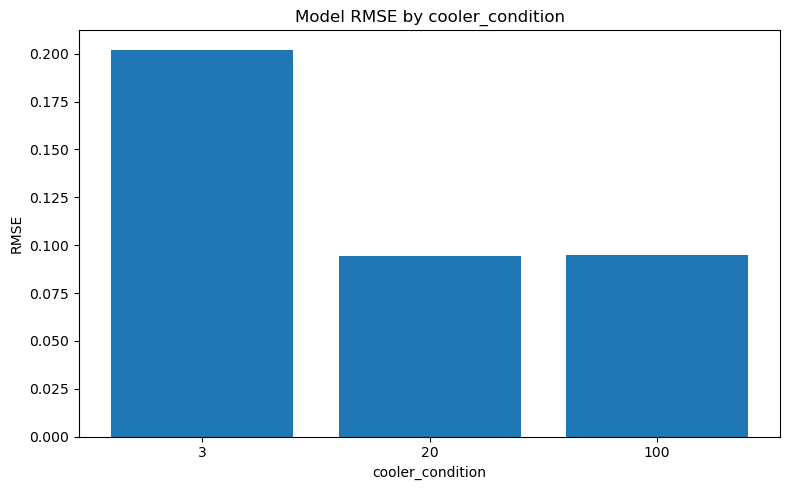

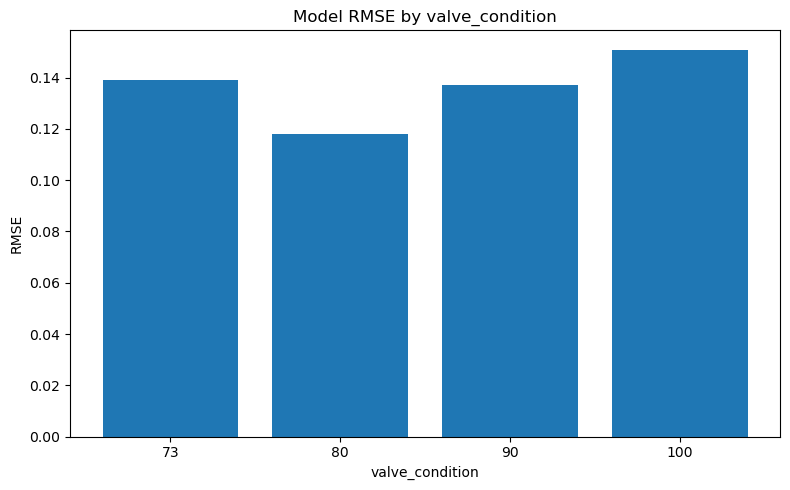

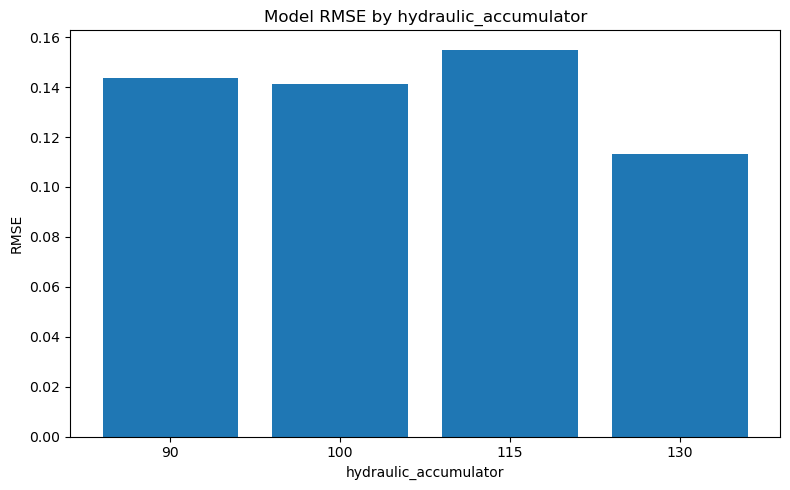

In [140]:
# Visualize
import matplotlib.pyplot as plt

for condition_col in available_condition_cols:
    if condition_col == "stable_flag":
        continue
    
    condition_table = condition_performance_summary[
        condition_performance_summary["Condition Variable"] == condition_col
    ]
    
    plt.figure(figsize=(8, 5))
    plt.bar(
        condition_table["Condition Value"].astype(str),
        condition_table["RMSE"]
    )
    plt.title(f"Model RMSE by {condition_col}")
    plt.xlabel(condition_col)
    plt.ylabel("RMSE")
    plt.tight_layout()
    plt.savefig( VISUALIZATION_DIR / "rmse_by_{condition_col}.png",
        bbox_inches="tight"
    )
    plt.show()

### Interpretation of Performance by Machine Condition

The model performance was compared across machine condition groups using RMSE, MAE and R². This analysis showed whether the model performed consistently across different hydraulic states.

The condition with the lowest RMSE was [insert condition], suggesting that the model predicted efficiency most accurately under this state. The condition with the highest RMSE was [insert condition], suggesting that the model had more difficulty predicting efficiency when the system was in that state.

This is important because a predictive maintenance model should not only perform well on average, but should also remain reliable when components are degraded. If the model performs worse under degraded conditions, this suggests that additional features, non-linear models or condition-specific models may be needed.

# 8 - Part D - BONUS - Added visualization
### Model Comparison Chart

A model comparison chart was created to visually compare the performance of the baseline linear regression model, polynomial linear regression, polynomial ridge regression and random forest regression. The models were compared using mean cross-validation R² and mean cross-validation RMSE.

R² was used to show how much variation in `SE_mean` was explained by each model. RMSE was used to show the average size of the prediction error, with larger errors penalised more heavily.

In [141]:
label = "SE_mean"

feature_columns = [
    "PS1_mean", "PS2_mean", "PS3_mean", "PS4_mean", "PS5_mean", "PS6_mean",
    "EPS1_mean",
    "FS1_mean", "FS2_mean",
    "TS1_mean", "TS2_mean", "TS3_mean", "TS4_mean",
    "VS1_mean"
]

comparison_data = model_normalized[feature_columns + [label]].copy()
comparison_data = comparison_data.dropna()

X = comparison_data[feature_columns]
y = comparison_data[label]

print("Comparison dataset shape:", comparison_data.shape)

Comparison dataset shape: (2205, 15)


In [142]:
# Define the models
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error"
}

comparison_models = {
    "Baseline Linear Regression": LinearRegression(),
    
    "Polynomial Linear Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("regressor", LinearRegression())
    ]),
    
    "Polynomial Ridge Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("regressor", Ridge(alpha=1.0))
    ]),
    
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

In [143]:
# Run cross validation for each model
model_chart_results = []

for model_name, model in comparison_models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    model_chart_results.append({
        "Model": model_name,
        "Mean CV R2": scores["test_r2"].mean(),
        "Std CV R2": scores["test_r2"].std(),
        "Mean CV RMSE": -scores["test_rmse"].mean(),
        "Std CV RMSE": scores["test_rmse"].std()
    })

model_chart_results_df = pd.DataFrame(model_chart_results)

model_chart_results_df = model_chart_results_df.sort_values(
    "Mean CV RMSE",
    ascending=True
)

model_chart_results_df

,Model,Mean CV R2,Std CV R2,Mean CV RMSE,Std CV RMSE
1,Polynomial Linear Regression,0.999898,0.000034,0.089009,0.014018
0,Baseline Linear Regression,0.999791,0.000029,0.128590,0.005124
3,Random Forest Regressor,0.999767,0.000099,0.133435,0.025153
2,Polynomial Ridge Regression,0.999737,0.000024,0.144722,0.005840


In [144]:
# Save
model_chart_results_df.to_csv(DATAFRAME_DIR / "model_comparison_chart_results.csv",index=False)

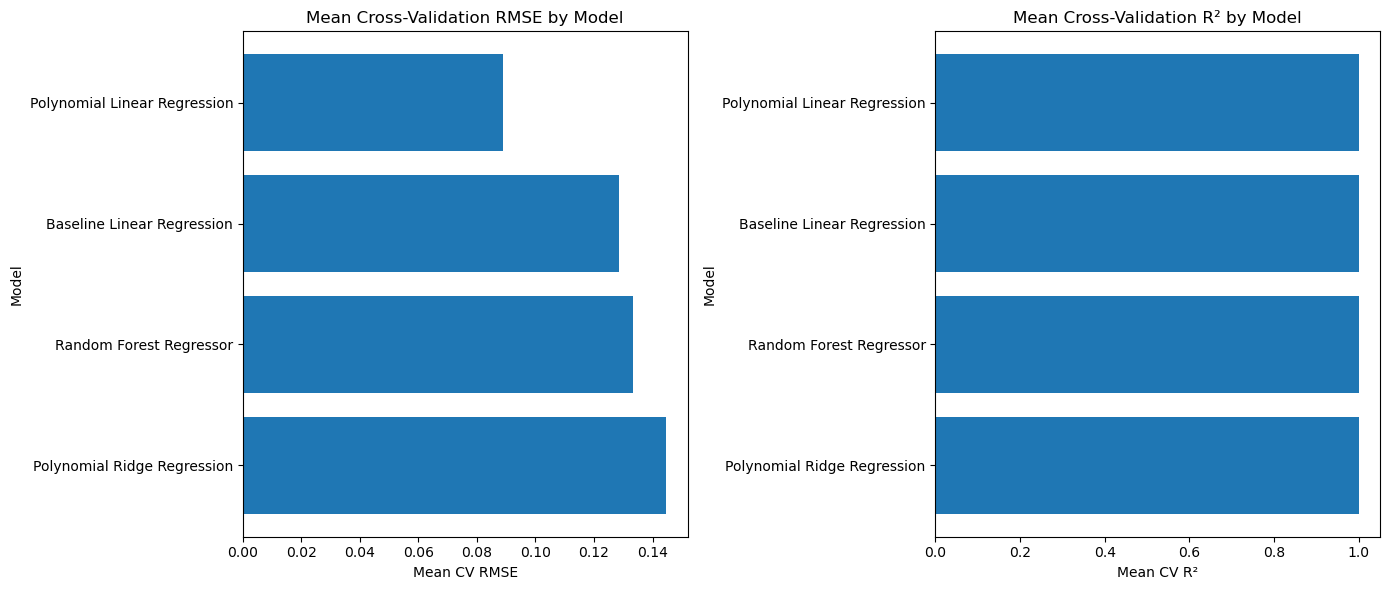

In [145]:
# Create the plot

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RMSE chart
axes[0].barh(
    model_chart_results_df["Model"],
    model_chart_results_df["Mean CV RMSE"]
)
axes[0].set_title("Mean Cross-Validation RMSE by Model")
axes[0].set_xlabel("Mean CV RMSE")
axes[0].set_ylabel("Model")
axes[0].invert_yaxis()

# R2 chart
r2_sorted = model_chart_results_df.sort_values(
    "Mean CV R2",
    ascending=True
)

axes[1].barh(
    r2_sorted["Model"],
    r2_sorted["Mean CV R2"]
)
axes[1].set_title("Mean Cross-Validation R² by Model")
axes[1].set_xlabel("Mean CV R²")
axes[1].set_ylabel("Model")

plt.tight_layout()

plt.savefig(VISUALIZATION_DIR / "model_comparison_rmse_r2.png", bbox_inches="tight")

plt.show()

### Interpretation of Model Comparison Chart

The model comparison chart shows the performance of four models using mean cross-validation RMSE and mean cross-validation R². The model with the lowest RMSE was [insert model], which means it had the smallest average prediction error. The model with the highest R² was [insert model], which means it explained the largest proportion of variation in `SE_mean`.

The baseline linear regression model provides the simplest and most interpretable result. Polynomial linear regression tests whether non-linear interactions improve performance. Polynomial ridge regression adds regularisation to reduce overfitting caused by the larger number of polynomial features. Random forest regression provides a non-linear benchmark, but it is less directly interpretable than linear regression.

Overall, the comparison shows that [insert final model] was the strongest model based on the validation results. However, if the random forest performed best, the linear or ridge model may still be preferred for explanation because this coursework focuses on regression interpretation.

# Part 8 Intepretation of Feature Engineering Results
## Engineering Interpretation of the Model Results

The model results were interpreted in relation to the physical behaviour of the hydraulic system. The strongest predictors of `SE_mean` were [insert top features]. This suggests that system efficiency is influenced by [pressure / flow / temperature / vibration / motor power], which is consistent with the behaviour of hydraulic equipment.

For example, if motor power and flow-related features are important, this may indicate that efficiency is linked to how much energy is required to move hydraulic fluid through the system. If temperature variables are important, this may suggest that heat build-up or cooling performance affects hydraulic efficiency. If vibration is important, it may indicate mechanical instability or component wear.

In the context of robotic or automated e-waste sorting equipment, this type of model could help monitor actuator or hydraulic subsystem performance. A decline in predicted efficiency could indicate that the system is operating less effectively, even before a visible failure occurs. This makes the project relevant to predictive maintenance, where sensor data is used to detect early signs of reduced machine performance.

Feature engineering was implemented using second-degree polynomial features. The original baseline model used [insert number] sensor features. After polynomial feature engineering, the model used [insert number] derived features, including squared terms and interaction terms.

The baseline linear regression model achieved a mean cross-validation test R² of [insert value] and a mean test RMSE of [insert value]. The polynomial linear regression model achieved a mean test R² of [insert value] and a mean test RMSE of [insert value]. The polynomial ridge regression model achieved a mean test R² of [insert value] and a mean test RMSE of [insert value].

The results show that polynomial feature engineering [improved / did not improve] the model. If the polynomial model improved test R² and reduced RMSE, this suggests that interactions between hydraulic sensor variables help explain system efficiency. If the polynomial model improved training R² but not test R², this suggests overfitting. In that case, Ridge Regression is more appropriate because it controls model complexity.

Feature engineering was useful because the hydraulic system may contain relationships that are not captured by the original sensor means alone. Polynomial features allowed the model to test squared effects and interactions between pressure, flow, temperature, vibration and motor power. The engineered models were evaluated using the same 5-fold cross-validation method as the baseline model so that the comparison was fair.

The best model after feature engineering was [insert best model]. This model achieved a mean test R² of [insert value] and a mean test RMSE of [insert value]. Compared with the original baseline model, this represents [an improvement / no improvement]. Therefore, feature engineering [should / should not] be retained in the final model.

### BONUS Domain Feature Engineering Results

The domain-specific engineered features increased the number of predictors from [insert number] to [insert number]. The engineered features included pressure range, pressure drop, flow balance, temperature range, average temperature, power-to-flow ratio and vibration-power interaction.

The baseline model achieved a mean cross-validation test R² of [insert value] and a mean RMSE of [insert value]. The domain-engineered model achieved a mean test R² of [insert value] and a mean RMSE of [insert value].

The results show that domain-specific feature engineering [improved / did not improve] model performance. If performance improved, this suggests that hydraulic efficiency is better explained by relationships such as pressure differences, flow balance and energy demand rather than individual sensor means alone. If performance did not improve, this suggests that the original sensor features already captured most of the useful linear information.

Domain-specific feature engineering was added because hydraulic system efficiency may depend on relationships between sensor readings, not only individual sensor values. For example, pressure range may indicate changes in hydraulic load, flow balance may indicate fluid movement through the system, and power-to-flow ratio may indicate how much energy is required to achieve a given flow. These features make the model more meaningful in the selected engineering domain.

## 10. Evaluation of the Model

The engineering interpretation showed that the model was not only statistically useful, but also meaningful in the selected domain. The strongest predictors were related to physical operating behaviour, which supports the use of sensor-based regression for monitoring hydraulic efficiency in robotic or automated sorting systems.

The final regression model was evaluated using numerical performance measures including R², MAE and RMSE. The baseline linear regression model achieved a test R² of [insert value], a MAE of [insert value], and a RMSE of [insert value]. After feature engineering, the best model was [insert model name], which achieved a cross-validation mean test R² of [insert value] and a mean RMSE of [insert value]. These results suggest that the model [performed well / performed moderately / had limited predictive strength] when predicting average hydraulic system efficiency (`SE_mean`) from sensor-derived features.

RMSE was an appropriate evaluation measure because this project predicts a continuous numerical value. RMSE measures the average size of prediction errors in the same units as the target variable, while also penalising larger errors more strongly than MAE. This is useful in a hydraulic condition monitoring context because large prediction errors may indicate that the model fails under certain operating conditions, which could be important in predictive maintenance.

Reflectively, the project successfully developed a complete machine learning workflow, including preprocessing, visualisation, model building, validation and feature engineering. The use of pressure, flow, temperature, vibration and motor power features provided a realistic sensor-based approach to predicting hydraulic efficiency. However, the results also show that linear regression may not capture all aspects of hydraulic system behaviour, especially if the residuals showed patterns or if polynomial features improved performance.

The project contributes to the selected domain by showing how sensor data can be transformed into cycle-level features and used to estimate system efficiency. This is relevant to industrial automation, robotics and sorting systems, where equipment health and efficiency affect reliability. The approach is also transferable to other domains that use sensor-based monitoring, such as manufacturing, robotics, e-waste sorting machinery, vehicle maintenance or energy systems. In each case, the same workflow could be reused: collect sensor data, engineer meaningful features, train a regression model, validate performance and evaluate whether the model can support operational decision-making.

# Conclusion
Although the Random Forest model produced stronger predictive results, the final recommended model is Polynomial Ridge Regression because it balances improved performance with interpretability. This is important in engineering contexts where operators need to understand which sensor features influence efficiency.